In [1]:
%load_ext autoreload
%autoreload 2 

    

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')


from spikeparam.patch.fit import Spike
from spikeparam.patch.fit import SpikeGroup



from neurodsp import spectral

from scipy import signal
import scipy

import h5py
from tqdm.notebook import tqdm

import numpy as np
import pandas as pd

from neurodsp import filt
from neurodsp.timefrequency import amp_by_time, phase_by_time
from neurodsp.plts import plot_time_series, plot_instantaneous_measure
from neurodsp.plts.time_series import plot_bursts
from neurodsp.burst import detect_bursts_dual_threshold, compute_burst_stats

from scipy.signal import sosfiltfilt, butter

from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
import statsmodels.api as sm
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,  r2_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso, ElasticNet



import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
import scipy.stats as stats
import scipy.spatial as sp_spatial

import os
import time



from fooof import FOOOF

from sklearn.linear_model import LinearRegression

sns.set(rc={'figure.figsize':(12,9)})
sns.set_style('whitegrid')
sns.set_style("whitegrid", {'axes.grid' : False})


import warnings
warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'
import matplotlib.animation as animation

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_10625/3379620088.py:61: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


### HELPER FUNCTIONS - to do: move to .py file 

In [2]:
def butter_bandpass(data, fs, filt_freq, order):
    # make sure that the user provides two frequencies for bandpass filter
    try:
        # renormalize frequencies in Hz to fractional scale required by butter
        nyq = 0.5 * fs # nyquist frequency
        f0 = (filt_freq[0]/nyq)
        f1 = (filt_freq[1]/nyq)

        # highpass first
        sos = butter(order, f0, btype = 'high', analog=False, output='sos')
        y = sosfiltfilt(sos, data)

        # then lowpass
        sos = butter(order, f1, btype = 'low', analog=False, output='sos')
        y = sosfiltfilt(sos, y)
        
        return y
    
    except:
        print("filt_freq must have two frequencies for a bandpass filter")

In [3]:
def get_patch_fs_metadata(metadata_file, cell_num):
    
    metafile = pd.read_excel(metadata_file, sheet_name='Sheet1')
    #get index for cell
    cells = metafile['Cell']
    index_cell = cells[cells == "c"+str(cell_num)].index[0]
    
    #get path fs for cell
    
    patch_fs = metafile['Patch Samp. Freq. (Hz)'][index_cell]
    
    return patch_fs
    

In [4]:
def upper(df):
    '''Returns the upper triangle of a correlation matrix.
    You can use scipy.spatial.distance.squareform to recreate matrix from upper triangle.
    Args:
      df: pandas or numpy correlation matrix
    Returns:
      list of values from upper triangle
    '''
    try:
        assert(type(df)==np.ndarray)
    except:
        if type(df)==pd.DataFrame:
            df = df.values
        else:
            raise TypeError('Must be np.ndarray or pd.DataFrame')
    mask = np.triu_indices(df.shape[0], k=1)
    return df[mask]

In [5]:
metadata_dir = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Data Summary.xlsx'
patch_fs_c16 = 50023.9027015608

In [6]:
npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate


npx_channels = 384
npx_patch_channel = 161

data_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/all_recordings/'

out_lfp_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/'

out_npx_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_npx_recordings/'

out_patch_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/'

cell_ids = ['c16', 'c16']

### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook 

#load_spe1_data(data_path, lfp_fs, npx_fs, patch_fs, cell_ids, npx_channels, npx_patch_channel, out_lfp_path, out_npx_path, out_patch_path)



## Cell 16  (Whole patch, IC)
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 16

#### Step 0: Get loaded data

In [7]:
lfp_c16= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c16_lfp_filt.npy'
patch_c16 = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c16patch_filt.npy'


In [8]:
#get cell number 
cell_num = lfp_c16.split('/')[len(lfp_c16.split('/'))-1].split('_')[0]


#get patch data 
patch_filt_c16 = np.load(patch_c16)
patch_c16_one_ms = float(patch_fs_c16  / 1000)
patch_times_c16 = np.arange(0, np.shape(patch_filt_c16 )[0]) / patch_c16_one_ms # in ms instead of sec

### Compute patch clamp spike features for cell 16

In [9]:
#flip sign of patch filt
patch_filt_c16 = -patch_filt_c16

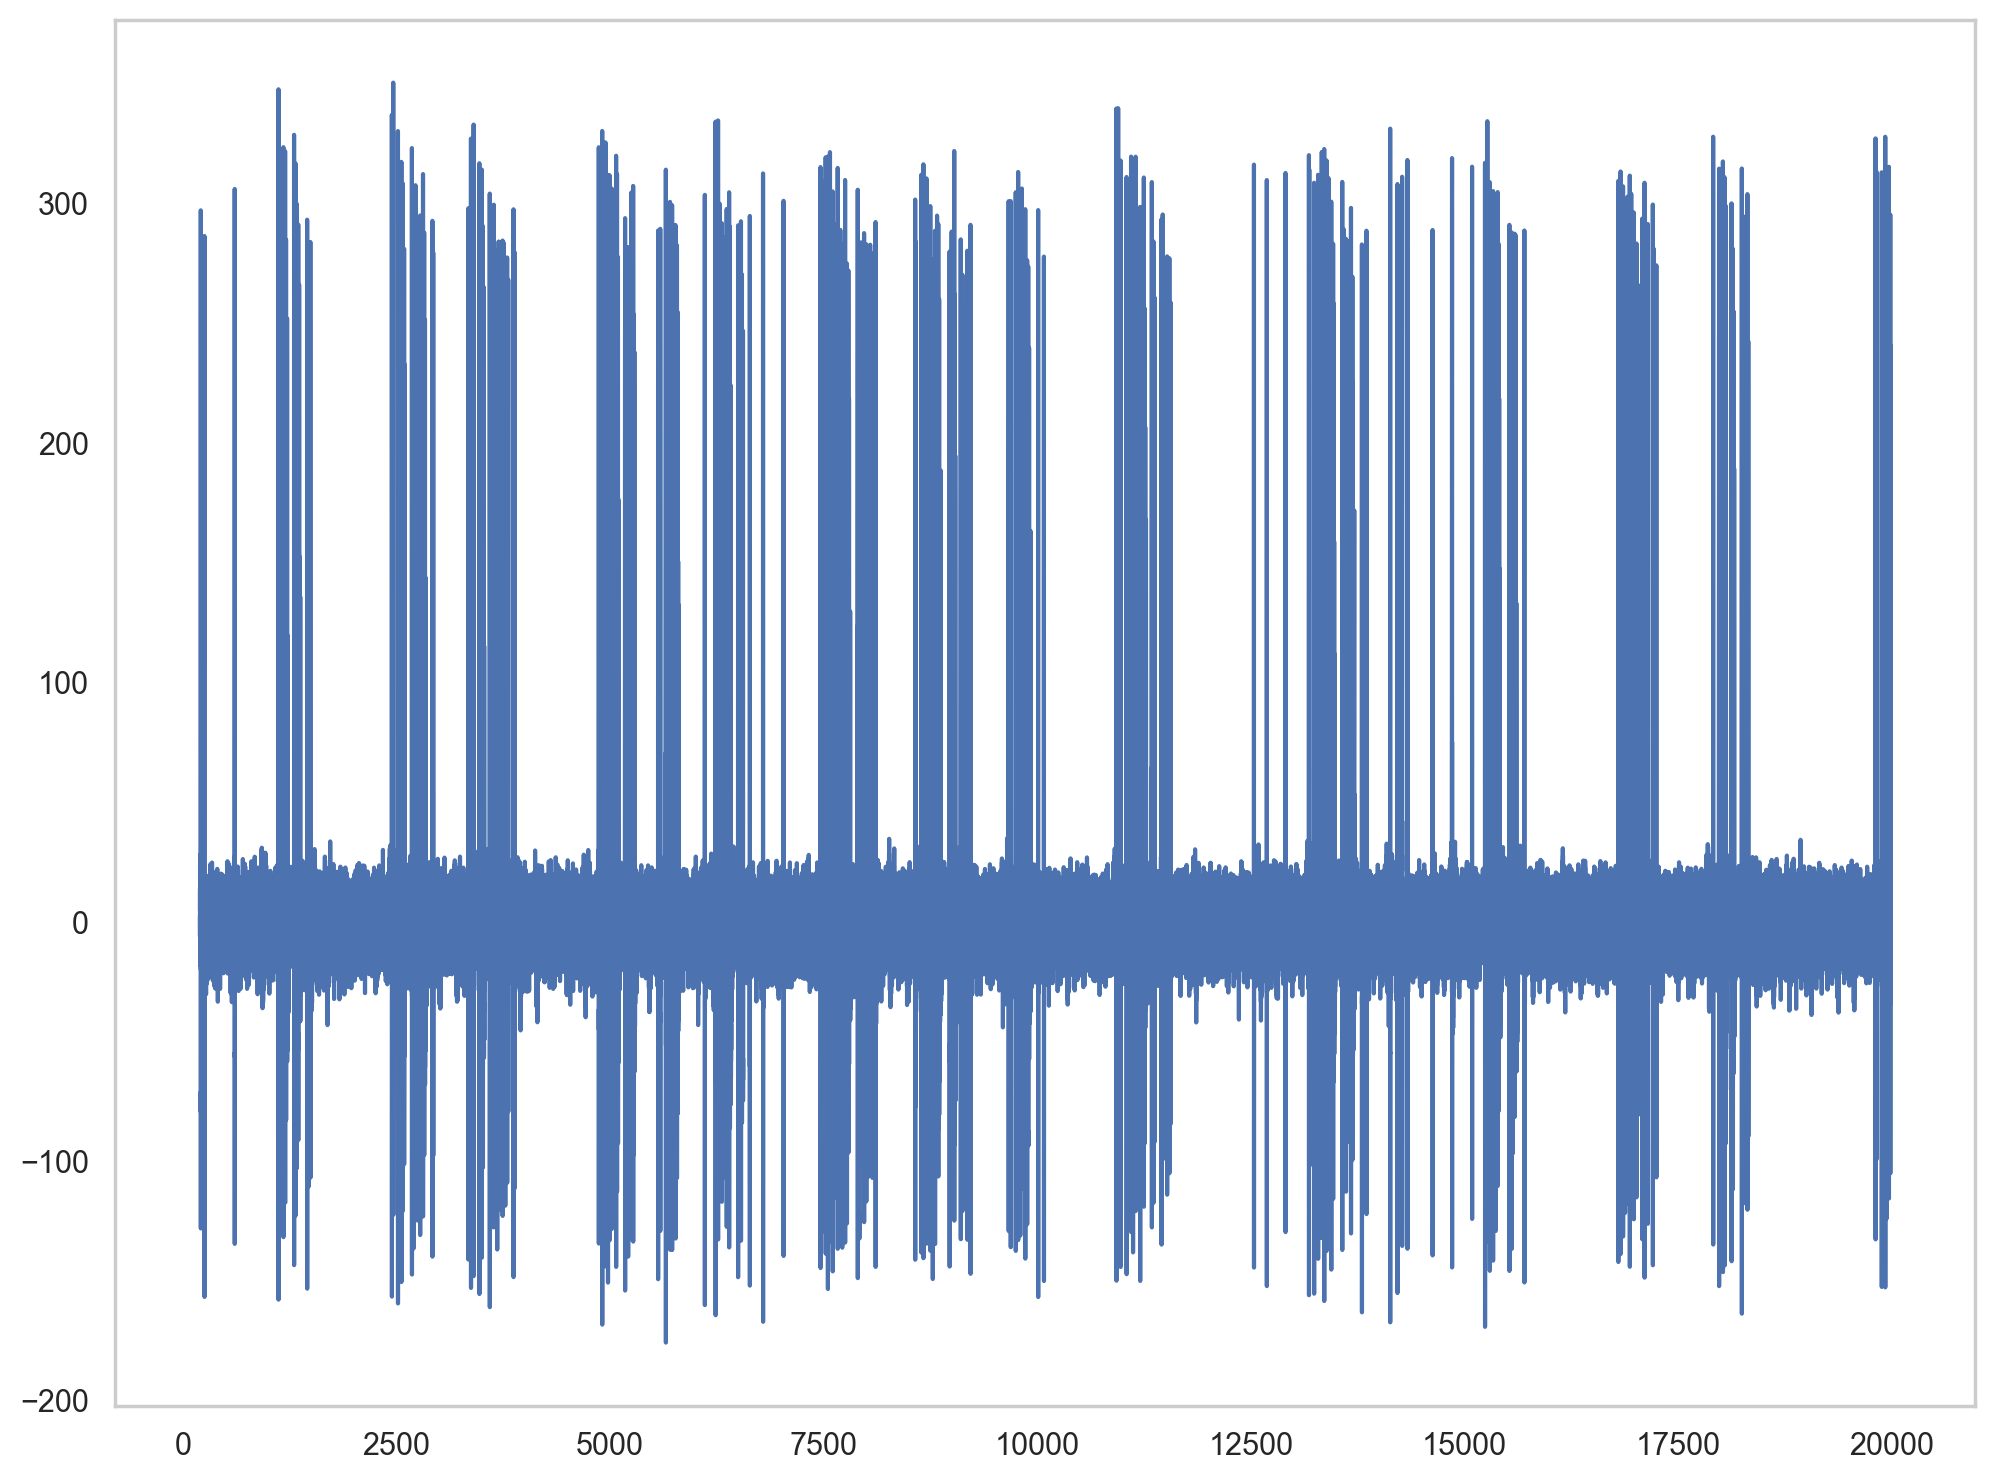

In [10]:
plt.plot(patch_times_c16[10000:1000000], patch_filt_c16[10000:1000000])

In [11]:
def compute_alt_features(stim, fs):
    return stim.mean(), stim.std()

#threshold in mVs
sp = Spike(thresh_amp=126, window_length=(5., 5.), smooth_frac=.01)

"""sp.alt(lfp_filt_c16, lfp_fs, compute_alt_features, queue=True,
       param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))"""

sp.fit(patch_filt_c16, patch_fs_c16, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/6465 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [12]:
def compute_isi(spike_inds, fs, in_ms=True):
    """Compute inter-spike intervals.

    Parameters
    ----------
    spike_inds : 1d array or list of 1d array
        Sample indices where spikes occur.
    fs : float
        Sampling rate, in Hz.
    in_ms : bool, optional, default: True
        Scale time to ms if True.

    Returns
    -------
    isi : 1d array
        Time until next spike.
    """

    scale = 1000 if in_ms else 1

    if isinstance(spike_inds, np.ndarray) and spike_inds.ndim == 1:
        isi = np.zeros(len(spike_inds))
        isi[:-1] = (np.diff(spike_inds) / fs * scale)
        isi[-1] = np.nan
    else:
        # spike_inds is 2d and non=continuous between 1d slices
        isi = []
        for inds in spike_inds:
            _isi = np.zeros(len(inds))
            _isi[:-1] = (np.diff(inds) / fs * scale)
            _isi[-1] = np.nan
            isi.extend(_isi)
        isi = np.array(isi)

    return isi


In [13]:
test = compute_isi(sp.spike_inds, patch_fs_c16)

In [14]:
test = test[:-1]

In [15]:
np.min(test)

19.930472157441095

In [16]:
sp.df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi,r_squared_ramp,r_squared_exp
0,-9.704149,0.24,4.962479,300.795831,0.24,125.385469,1.699272e-05,-13.279540,71.305912,0.191258,0.379724
1,3.065134,0.22,6.556382,269.013418,0.24,114.384749,4.650465e-07,-20.119008,33.483993,0.023864,0.452795
2,-2.886321,0.24,18.319152,290.671705,0.24,124.465344,2.192289e-05,-8.538079,29.086095,0.025828,0.452375
3,-6.401350,0.24,-6.360176,272.056295,0.28,111.713518,1.000000e+01,-42.314063,30.305512,0.054053,0.077665
4,-1.119367,0.28,6.876360,295.914330,0.24,113.767425,8.208069e-07,-16.709193,43.039425,0.002091,0.461073
...,...,...,...,...,...,...,...,...,...,...,...
6460,0.286169,0.30,2.688845,237.826450,0.26,82.750153,1.000000e+01,-8.438652,96.853699,0.000379,0.003703
6461,-2.016541,0.26,11.324343,304.273581,0.24,132.052074,2.193449e-06,-14.824860,21.229851,0.010694,0.353388
6462,9.453093,0.28,19.250188,239.003532,0.26,87.228750,3.895678e-05,-15.227997,377.539516,0.184909,0.544398
6463,-0.120561,0.22,12.481049,284.061769,0.24,112.956088,3.164212e-06,-19.953561,164.581321,0.000070,0.389599


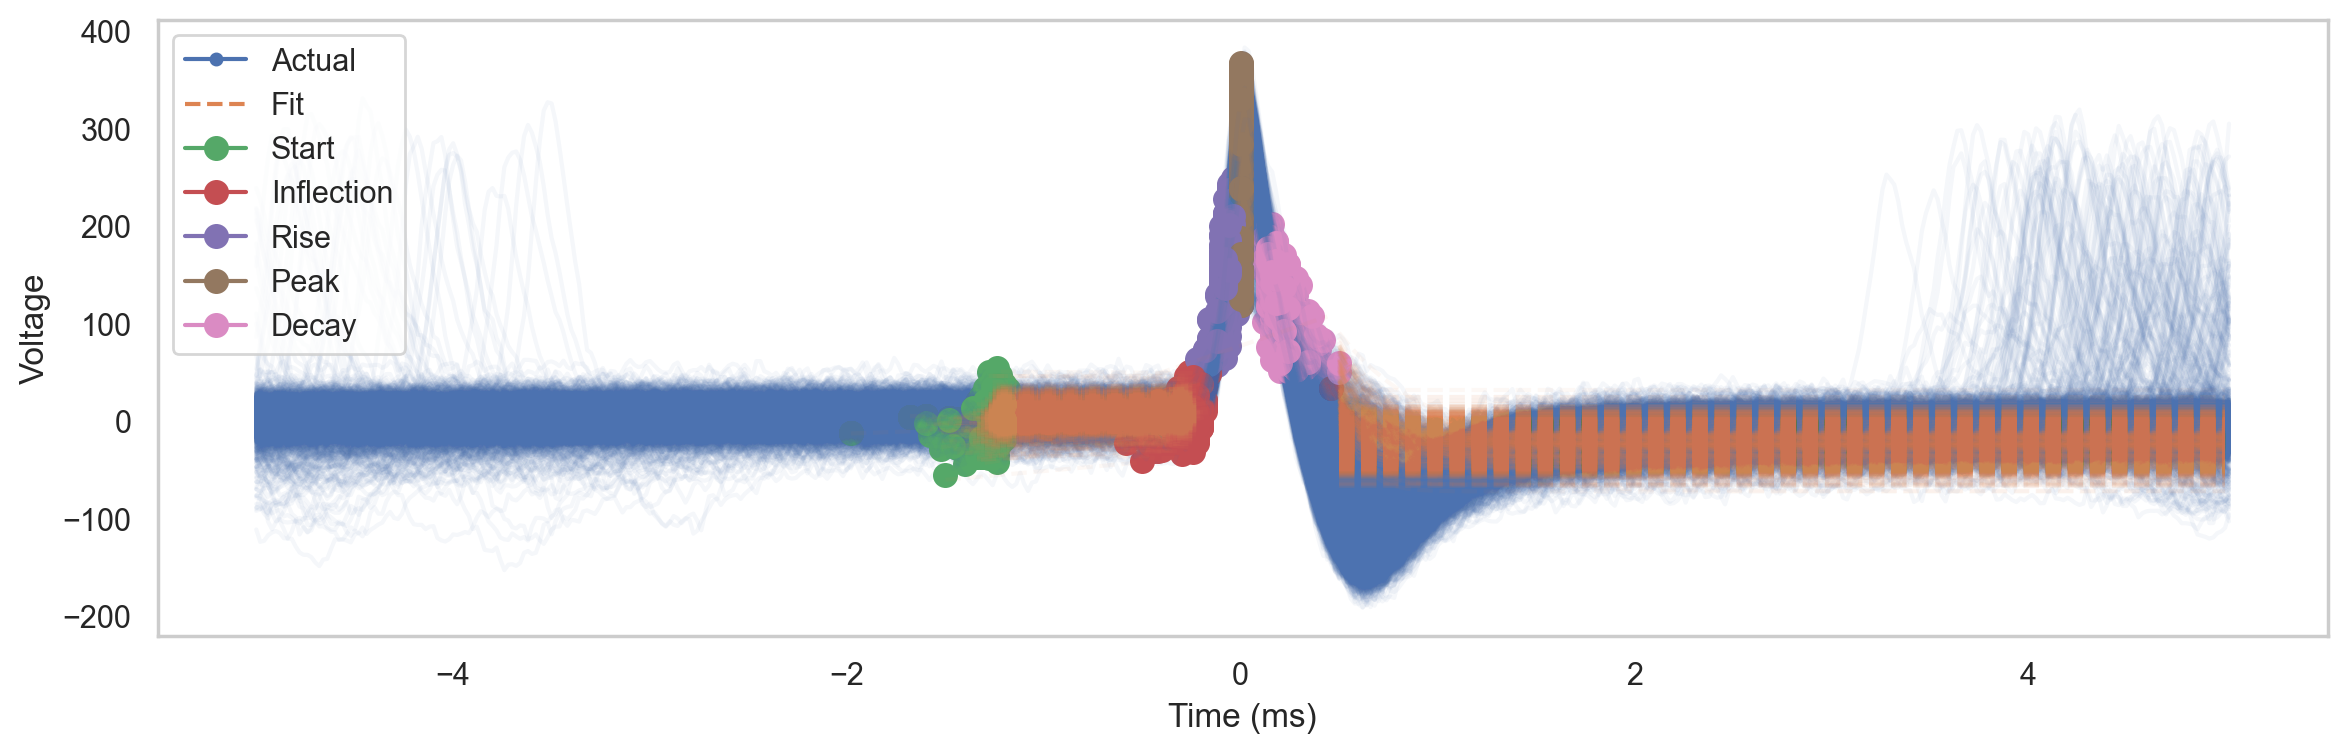

In [17]:
#plot fits
sp.plot( mode='full', show_points=True)

#### Plot correlations 

In [18]:
df_features = sp.df_features
# Add an index column to df_features to maintain original indices
df_features['original_index'] = df_features.index

In [19]:
np.min(df_features[['isi']])

19.930472157441095

In [20]:
np.max(df_features[['isi']])

3547.8639293463702

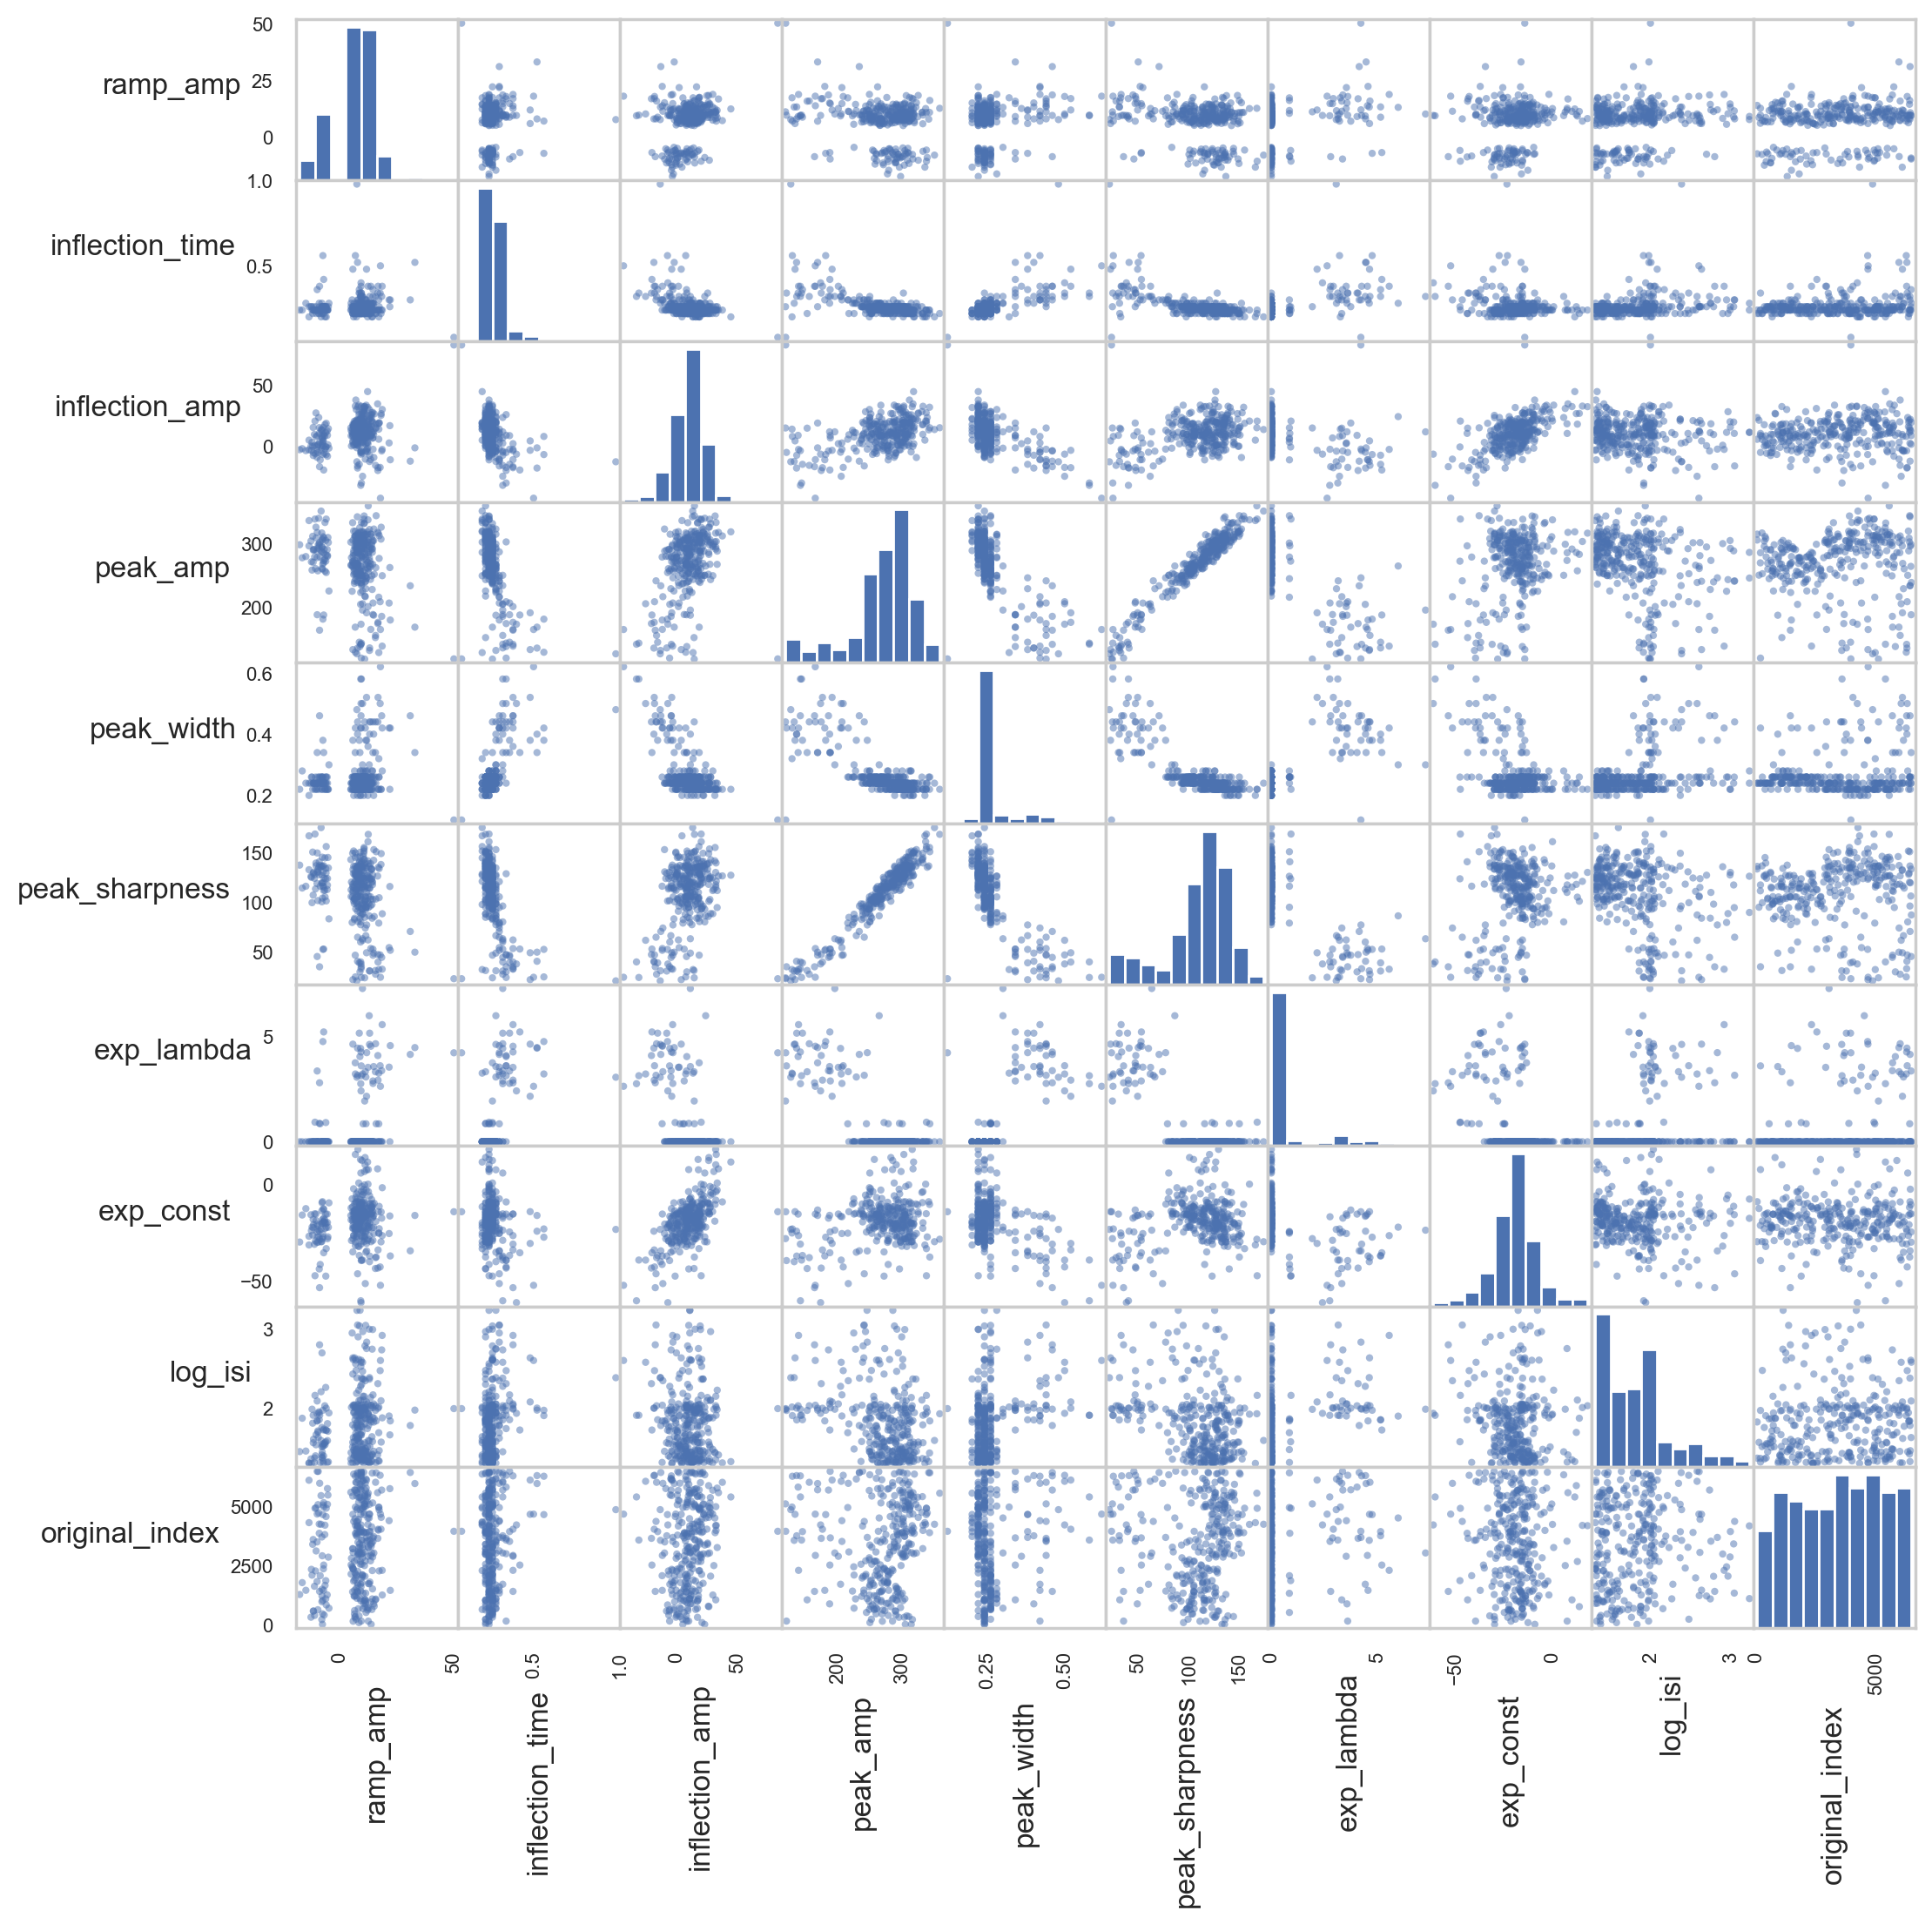

In [21]:
# Ensure inflection times are between 0 and 2 ms
df_features  = df_features .loc[df_features['inflection_time'] > 0.]
df_features = df_features .loc[df_features['inflection_time'] < 2.]
# Remove low r-squares (ramping fits are especially noisy)
df_features = df_features.loc[df_features['r_squared_exp']  >= .5]
df_features = df_features.loc[df_features['r_squared_ramp'] >= .1]
# log10 ISIs
df_features[['isi']] = np.log10(df_features[['isi']])
df_features.rename(columns={'isi':'log_isi'}, inplace=True)
# drop no-longer-used QC features
df_features = df_features.drop(['r_squared_exp', 'r_squared_ramp'], axis=1)
#replace infs with NaN
df_features = df_features.replace([np.inf, -np.inf], np.nan)

axes = pd.plotting.scatter_matrix(df_features, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
plt.show()

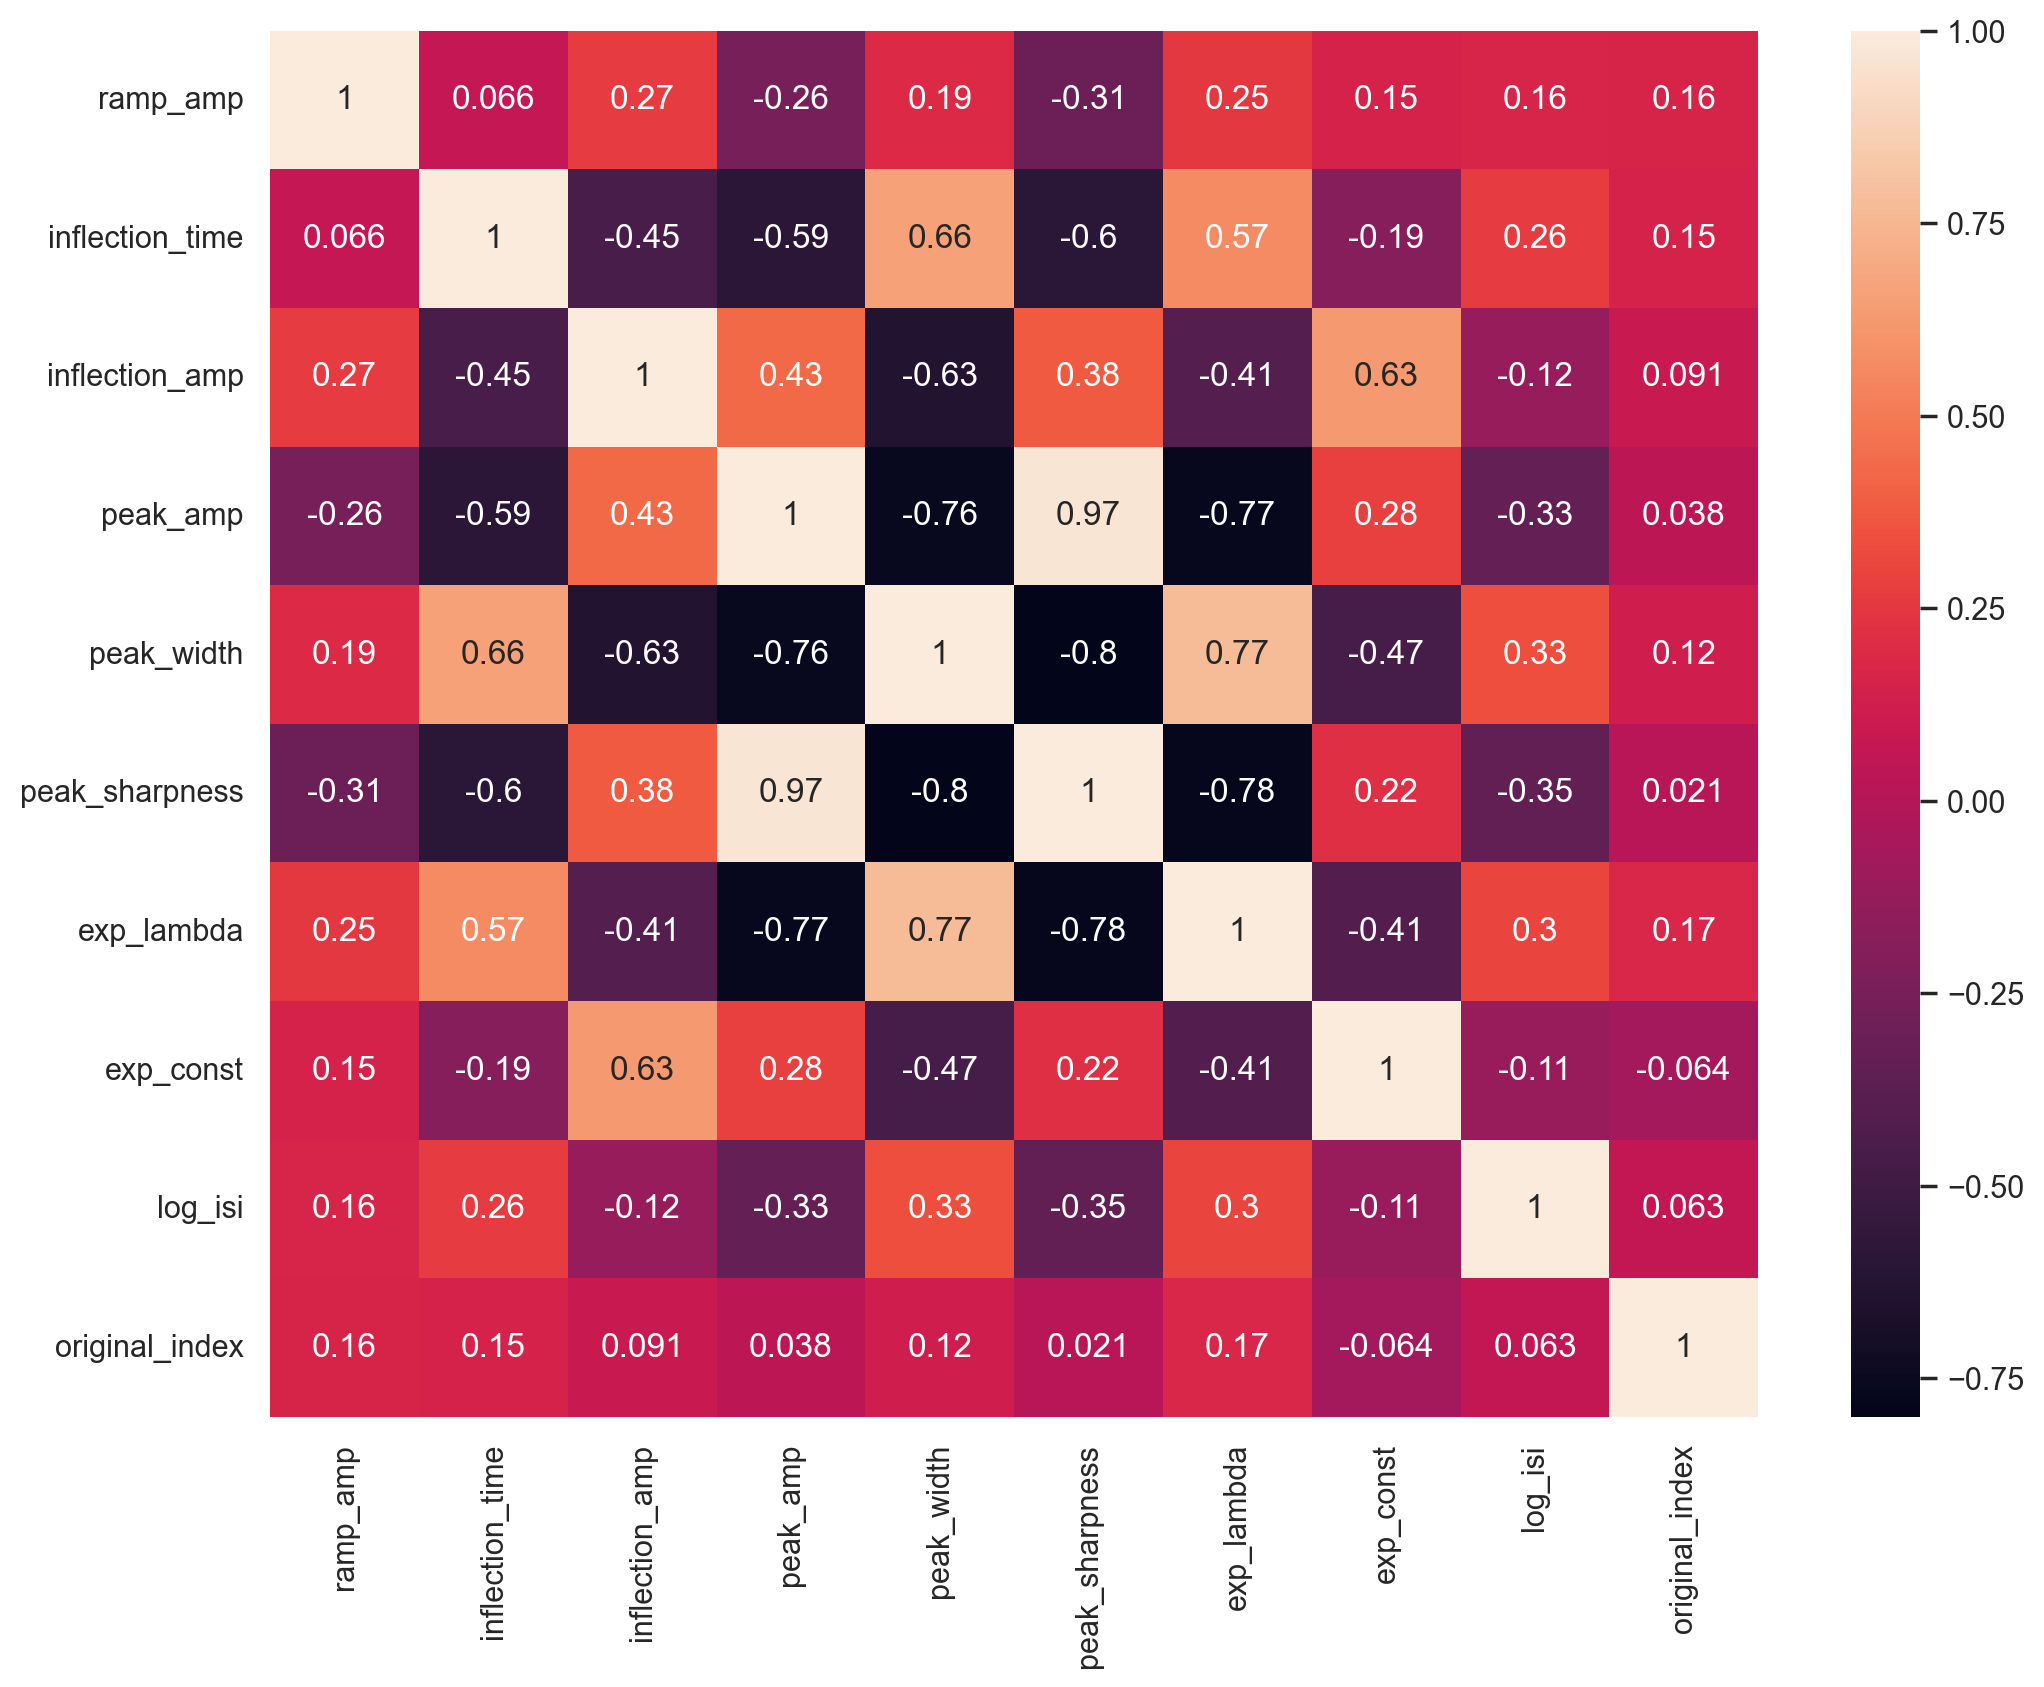

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,original_index
ramp_amp,1.0***,0.07,0.27***,-0.26***,0.19***,-0.31***,0.25***,0.15**,0.16**,0.16**
inflection_time,0.07,1.0***,-0.45***,-0.59***,0.66***,-0.6***,0.57***,-0.19***,0.26***,0.15**
inflection_amp,0.27***,-0.45***,1.0***,0.43***,-0.63***,0.38***,-0.41***,0.63***,-0.12*,0.09
peak_amp,-0.26***,-0.59***,0.43***,1.0***,-0.76***,0.97***,-0.77***,0.28***,-0.33***,0.04
peak_width,0.19***,0.66***,-0.63***,-0.76***,1.0***,-0.8***,0.77***,-0.47***,0.33***,0.12*
peak_sharpness,-0.31***,-0.6***,0.38***,0.97***,-0.8***,1.0***,-0.78***,0.22***,-0.35***,0.02
exp_lambda,0.25***,0.57***,-0.41***,-0.77***,0.77***,-0.78***,1.0***,-0.41***,0.3***,0.17**
exp_const,0.15**,-0.19***,0.63***,0.28***,-0.47***,0.22***,-0.41***,1.0***,-0.11*,-0.06
log_isi,0.16**,0.26***,-0.12*,-0.33***,0.33***,-0.35***,0.3***,-0.11*,1.0***,0.06
original_index,0.16**,0.15**,0.09,0.04,0.12*,0.02,0.17**,-0.06,0.06,1.0***


In [22]:
#df_features_correlation = df_features.corr()
# Plot the heatmap and annotation on it
sns.heatmap(df_features.corr(), xticklabels=df_features.corr().columns,
            yticklabels=df_features.corr().columns, annot=True)
plt.show()
rho = df_features.corr()
pval = df_features.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.map(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

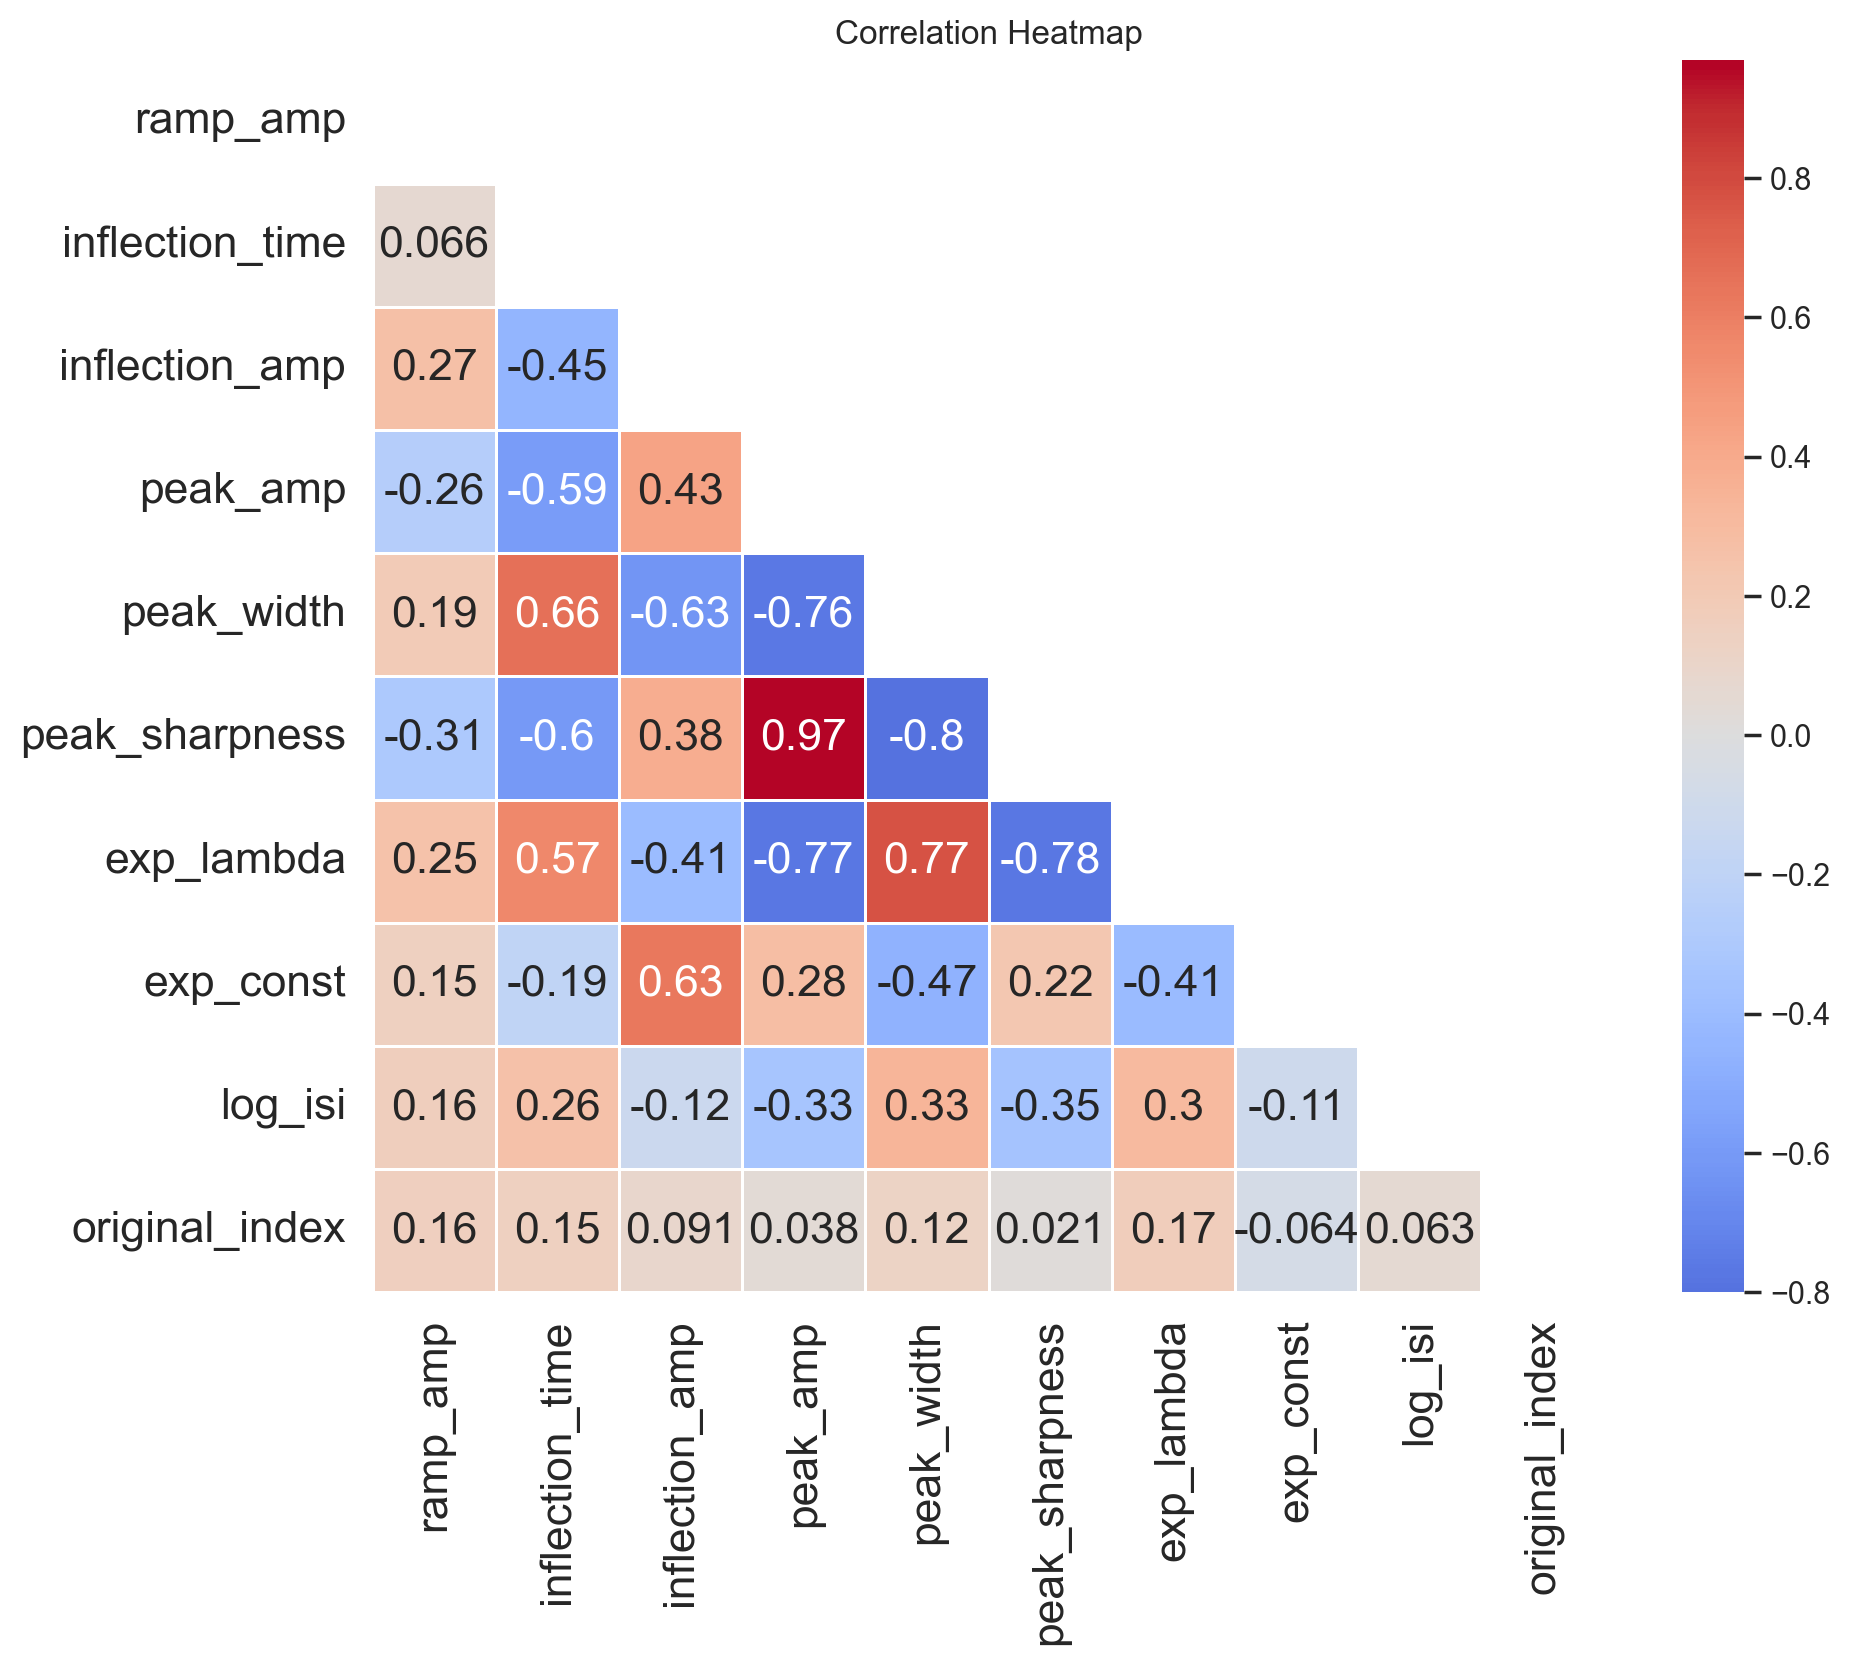

In [23]:
# Calculate correlation matrix and p-values
rho = df_features.corr()
pval = df_features.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval < 0.05  # Create a mask for significant p-values

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(rho, dtype=bool))

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(rho, mask=mask, cmap='coolwarm', annot=True, fmt='.2', linewidths=0.5, center=0, square=True,  annot_kws={"size": 16})
# Increase fontsize of tick labels on both axes
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.title('Correlation Heatmap')
plt.show()


In [24]:
df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,original_index
29,13.912475,0.22,23.142451,314.846866,0.24,133.177578,0.000010,-29.694439,1.826256,29
31,-7.471012,0.24,5.223729,305.571694,0.24,135.756033,0.000009,-8.935177,1.371968,31
105,8.561623,0.22,20.942989,250.441411,0.24,94.953579,0.000005,-12.469016,1.570569,105
162,6.001304,0.24,8.515903,269.766188,0.24,111.334324,0.000017,-21.246879,1.369379,162
167,12.656879,0.24,10.049266,285.631046,0.24,117.244925,0.000012,7.728500,1.322838,167
...,...,...,...,...,...,...,...,...,...,...
6418,10.666767,0.24,21.696262,295.907384,0.22,119.324230,0.000015,-2.470185,1.465770,6418
6440,9.498574,0.26,12.080987,264.229601,0.24,106.164176,0.000002,-10.477877,2.601374,6440
6452,-9.337193,0.24,1.034443,298.282010,0.24,133.022123,0.000021,-29.947745,1.631033,6452
6454,-9.788086,0.36,8.251652,188.375643,0.34,45.689667,3.364480,-24.642173,2.089909,6454


## Linear regression model to predict time of next spike (isi) based on inflection features 

#### Plot ISI distribution

(array([91., 45., 47., 70., 15., 11., 14.,  7.,  7.,  4.]),
 array([1.3047136 , 1.49713845, 1.6895633 , 1.88198816, 2.07441301,
        2.26683787, 2.45926272, 2.65168757, 2.84411243, 3.03653728,
        3.22896214]),
 <BarContainer object of 10 artists>)

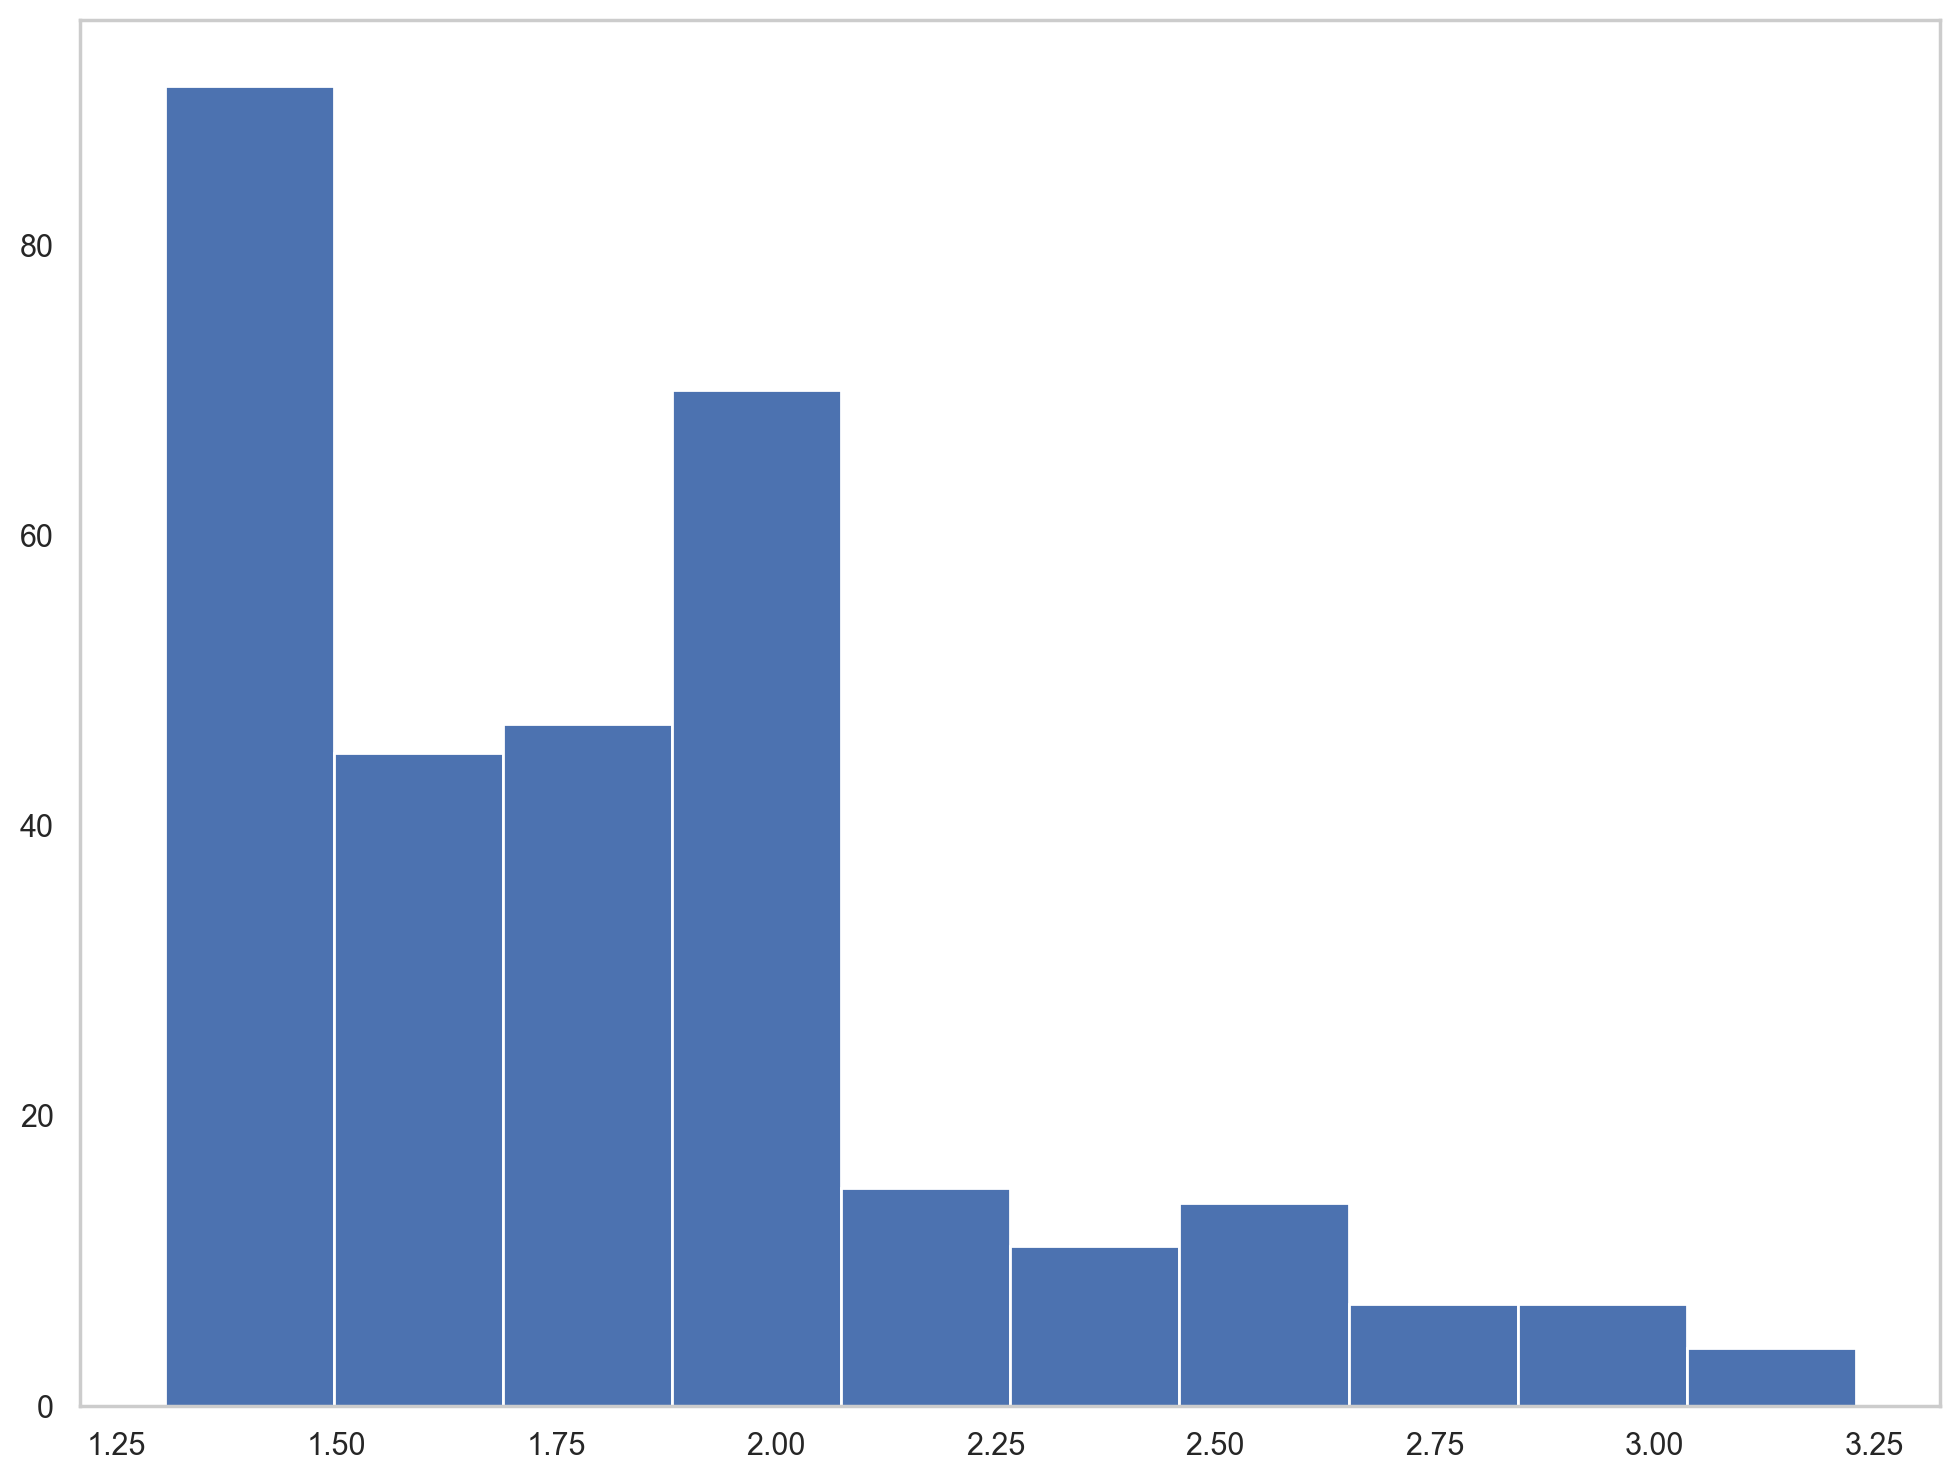

In [25]:
plt.hist(df_features['log_isi'])



#### It looks like the distribution of ISIs are split into 2 clusters 

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


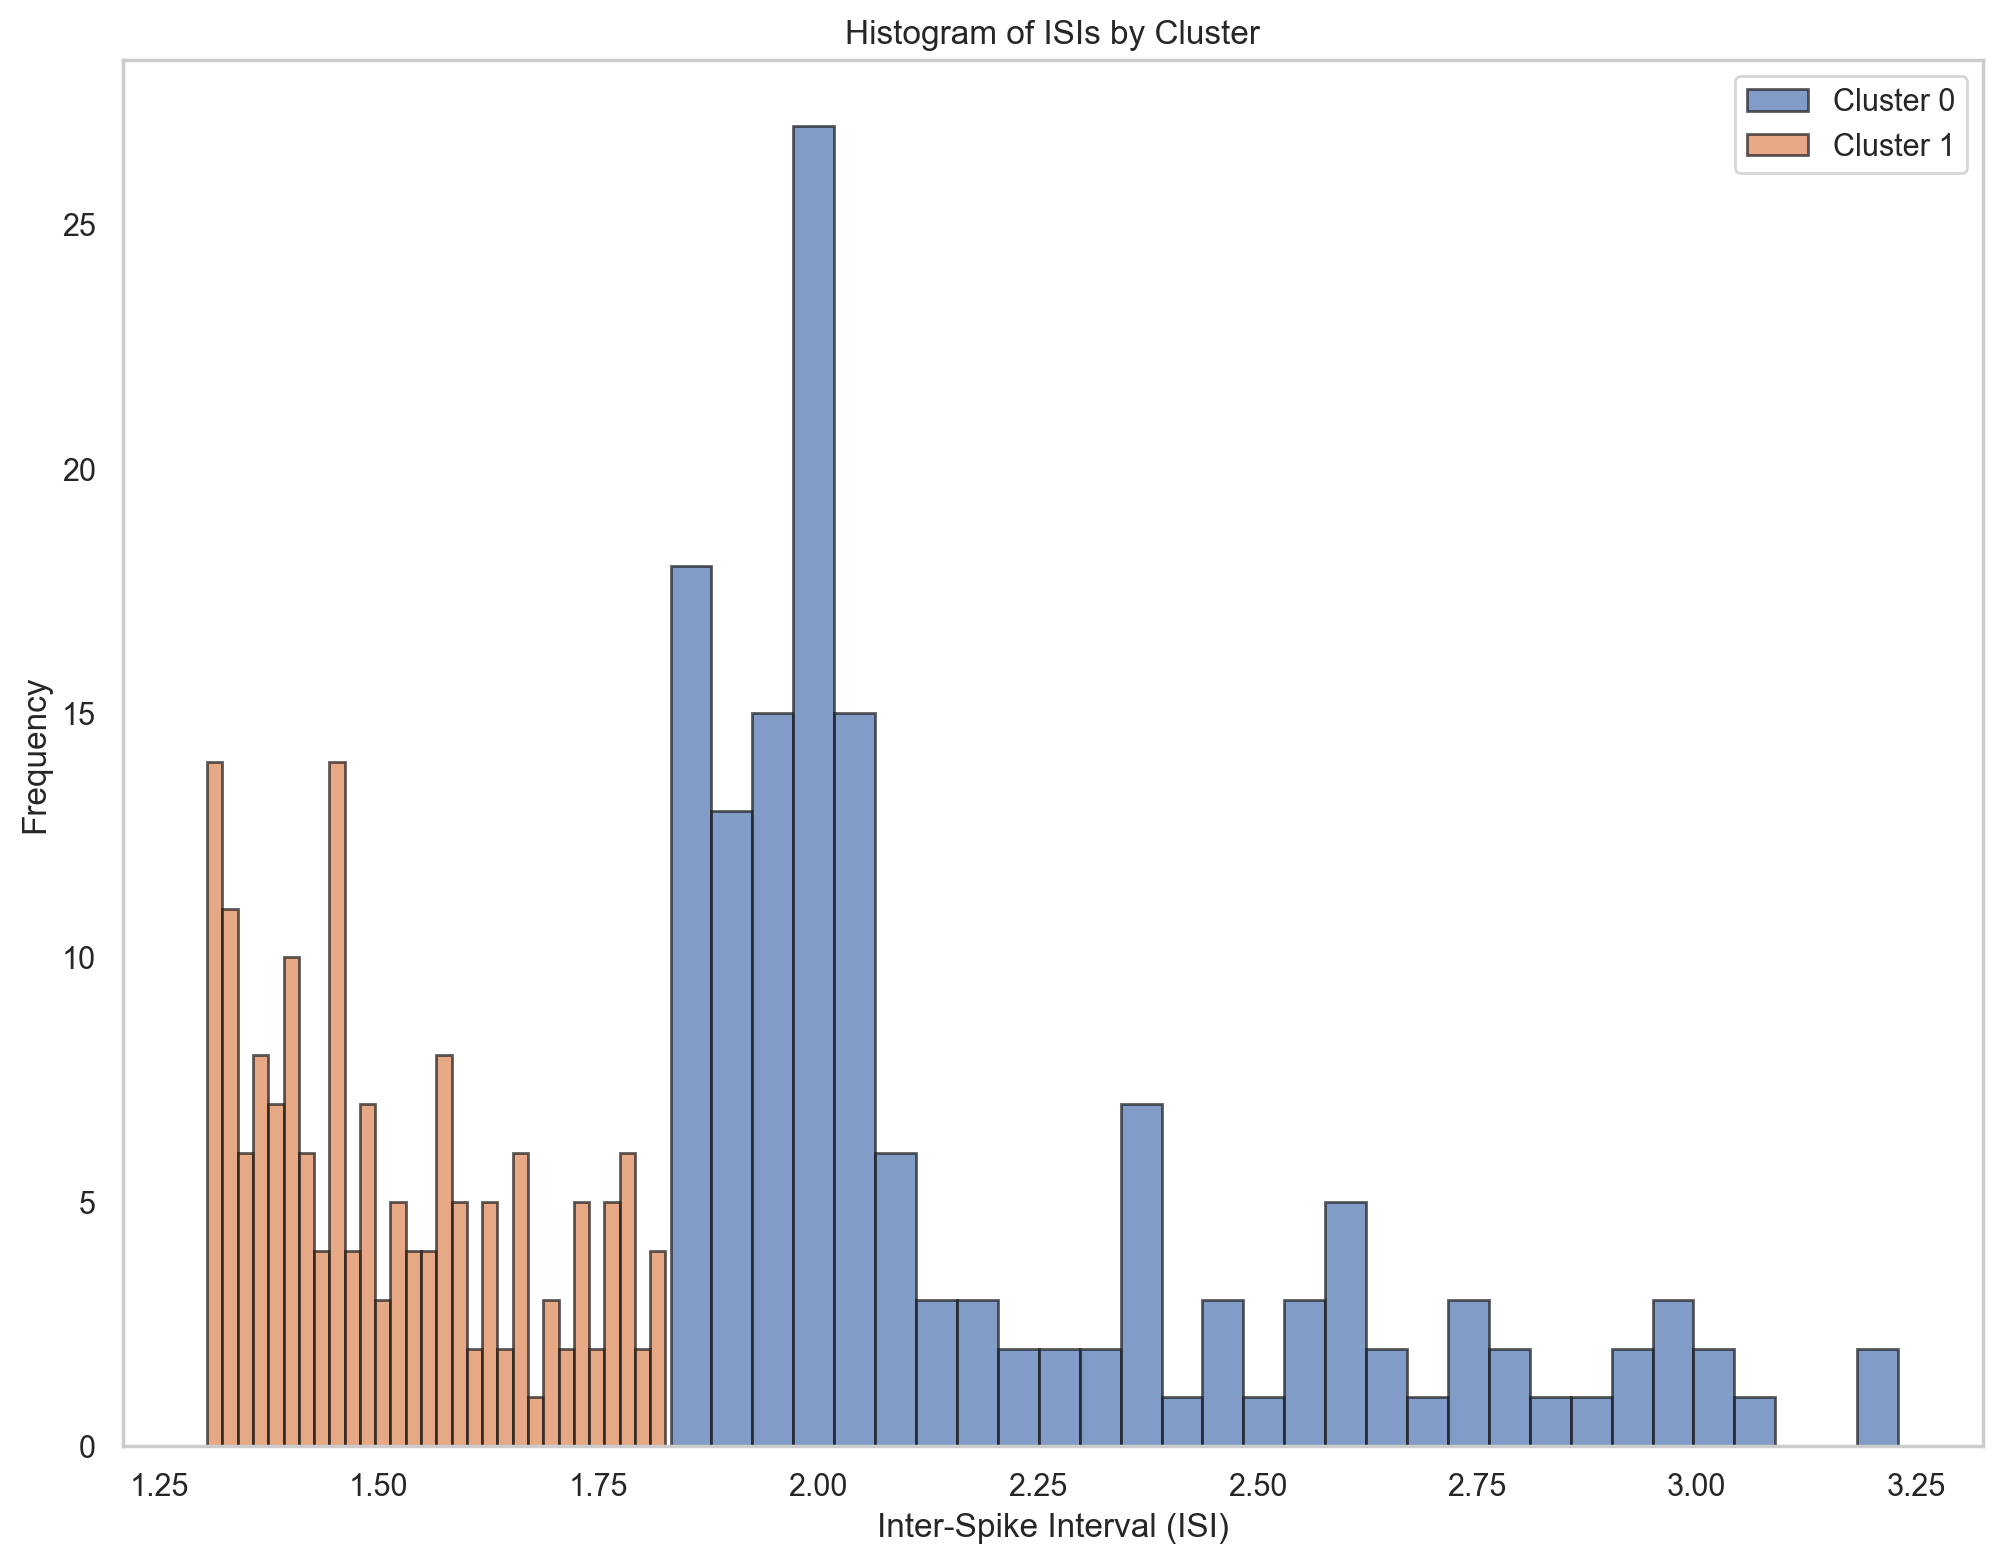

In [26]:
#split two clusters and then generate two different models?
isis = df_features['log_isi'].values
isis_reshaped = isis.reshape(-1, 1) 

# Perform MiniBatchKMeans clustering
mini_kmeans = MiniBatchKMeans(n_clusters=2, random_state=0, batch_size=100).fit(isis_reshaped)
clusters = mini_kmeans.labels_

# Visualize the clusters
plt.hist(isis[clusters == 0], bins=30, edgecolor='k', alpha=0.7, label='Cluster 0')
plt.hist(isis[clusters == 1], bins=30, edgecolor='k', alpha=0.7, label='Cluster 1')
plt.xlabel('Inter-Spike Interval (ISI)')
plt.ylabel('Frequency')
plt.title('Histogram of ISIs by Cluster')
plt.legend()
plt.show()

In [27]:
#separate features and target

features = df_features.drop(columns=['log_isi']).values
target = df_features['log_isi'].values

# Split features and target based on clusters
features_cluster_0 = features[clusters == 0]
target_cluster_0 = target[clusters == 0]
features_cluster_1 = features[clusters == 1]
target_cluster_1 = target[clusters == 1]

original_indices = df_features['original_index'].values
original_indices_cluster_0 = original_indices[clusters == 0]
original_indices_cluster_1 = original_indices[clusters == 1]

In [28]:
df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,original_index
29,13.912475,0.22,23.142451,314.846866,0.24,133.177578,0.000010,-29.694439,1.826256,29
31,-7.471012,0.24,5.223729,305.571694,0.24,135.756033,0.000009,-8.935177,1.371968,31
105,8.561623,0.22,20.942989,250.441411,0.24,94.953579,0.000005,-12.469016,1.570569,105
162,6.001304,0.24,8.515903,269.766188,0.24,111.334324,0.000017,-21.246879,1.369379,162
167,12.656879,0.24,10.049266,285.631046,0.24,117.244925,0.000012,7.728500,1.322838,167
...,...,...,...,...,...,...,...,...,...,...
6418,10.666767,0.24,21.696262,295.907384,0.22,119.324230,0.000015,-2.470185,1.465770,6418
6440,9.498574,0.26,12.080987,264.229601,0.24,106.164176,0.000002,-10.477877,2.601374,6440
6452,-9.337193,0.24,1.034443,298.282010,0.24,133.022123,0.000021,-29.947745,1.631033,6452
6454,-9.788086,0.36,8.251652,188.375643,0.34,45.689667,3.364480,-24.642173,2.089909,6454


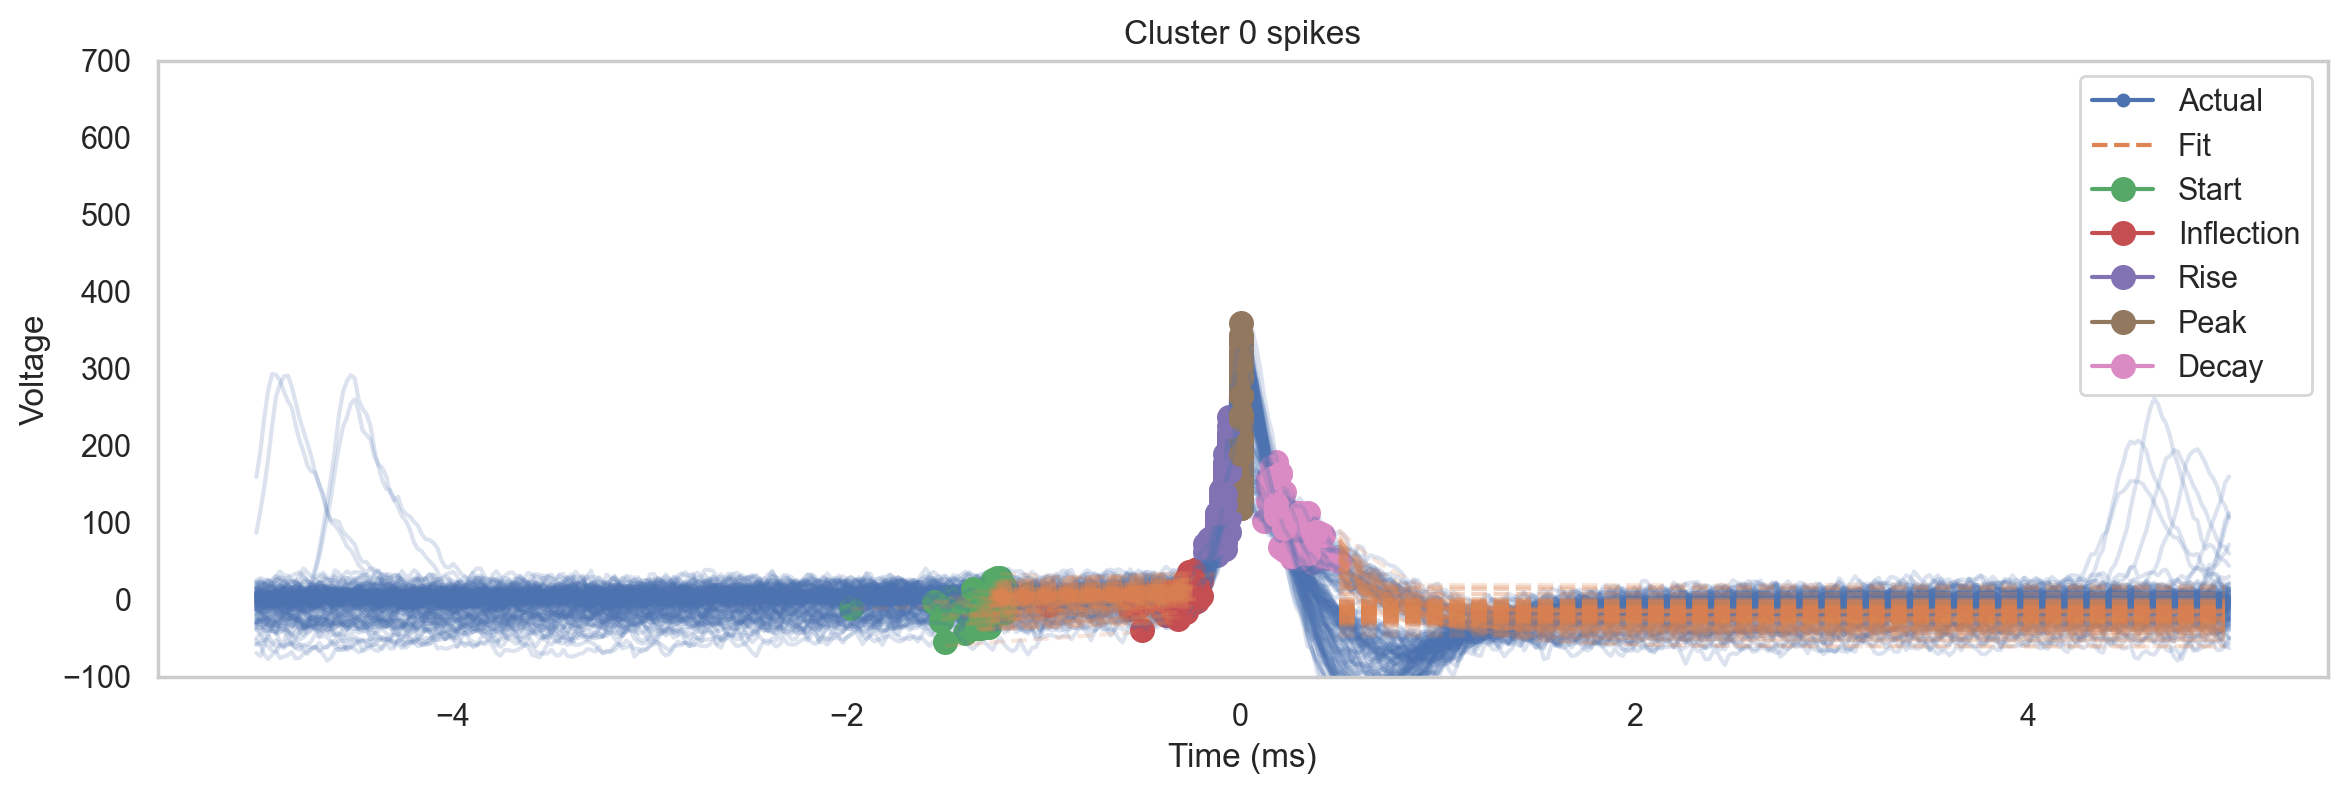

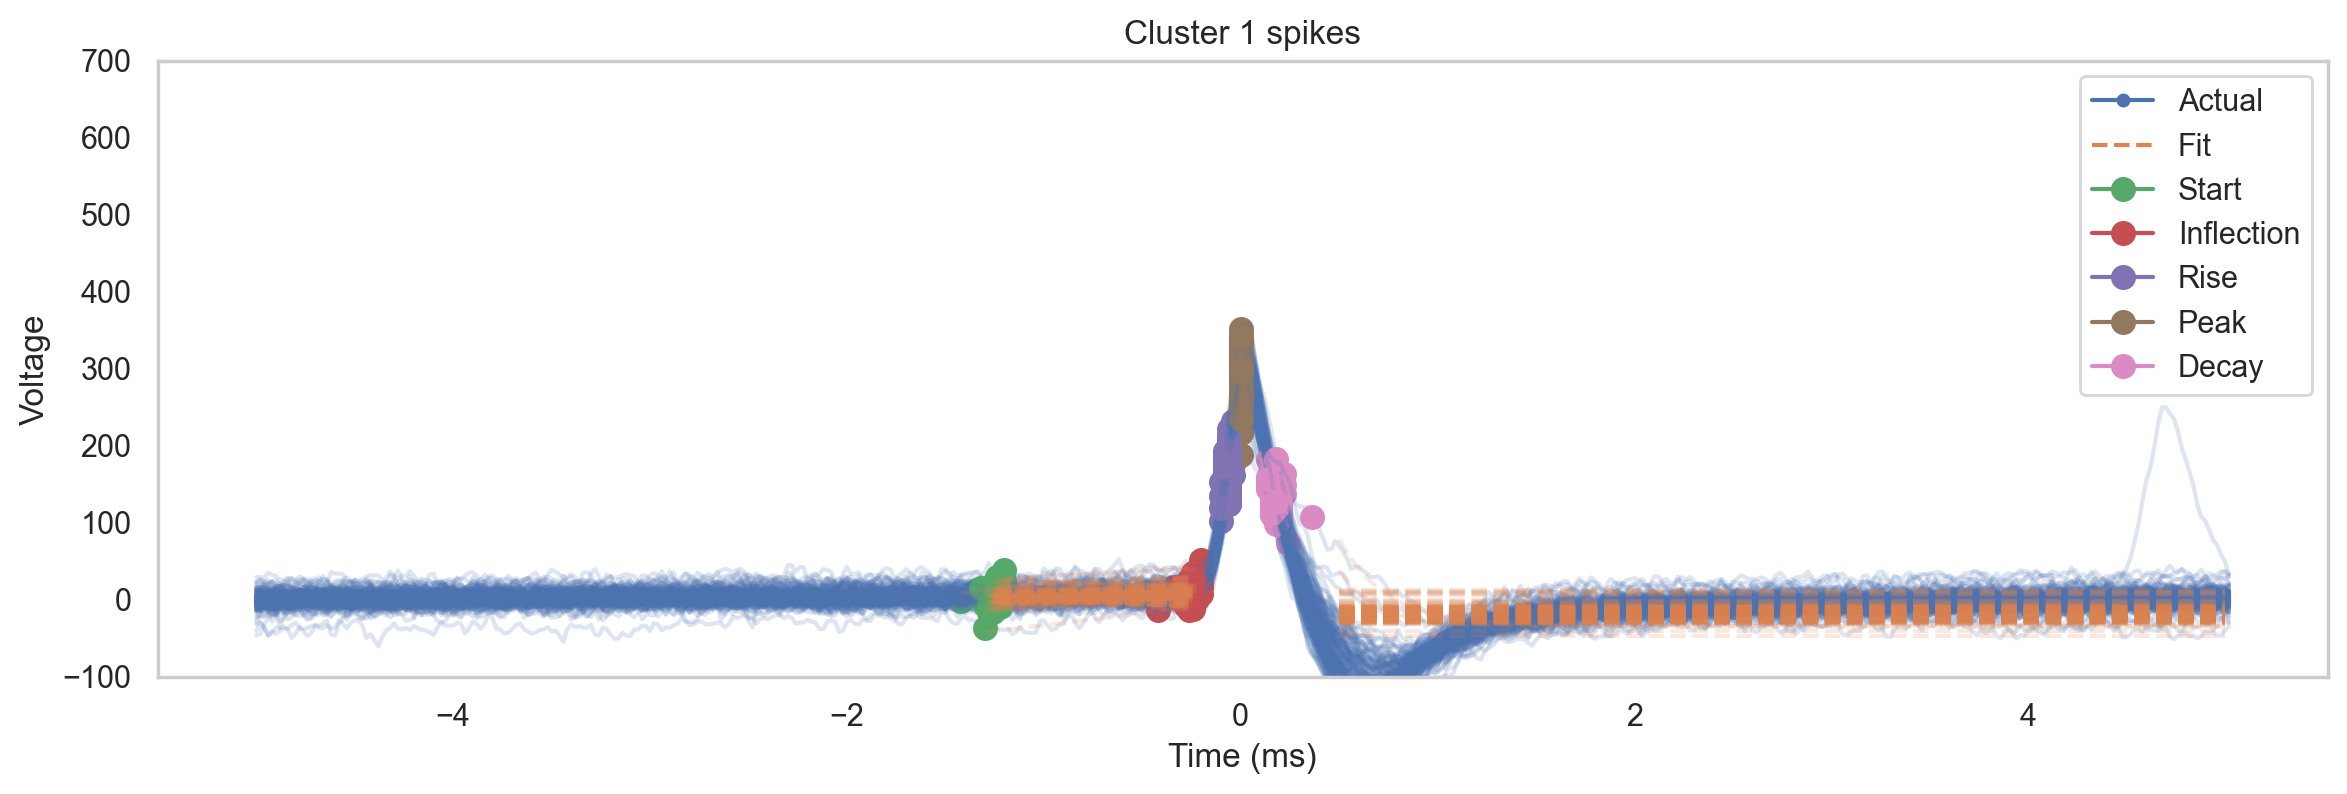

In [29]:
# Plot spikes for Cluster 0
sp.plot(inds=original_indices_cluster_0, mode='full', show_points=True)
plt.title("Cluster 0 spikes")
plt.ylim(-100,700)
plt.show()


# Plot spikes for Cluster 1
sp.plot(inds=original_indices_cluster_1, mode='full', show_points=True)
plt.title("Cluster 1 spikes")
plt.ylim(-100,700)
plt.show()

#### Troubleshooting cluster linear regressoin

In [30]:
# Standardize features
scaler_0 = StandardScaler()
features_cluster_0_scaled = scaler_0.fit_transform(features_cluster_0)

scaler_1 = StandardScaler()
features_cluster_1_scaled = scaler_1.fit_transform(features_cluster_1)

# Split data into training and test sets
X_train_0, X_test_0, y_train_0, y_test_0 = train_test_split(features_cluster_0_scaled, target_cluster_0, test_size=0.2, random_state=42)
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(features_cluster_1_scaled, target_cluster_1, test_size=0.2, random_state=42)

# Function to train the model with progress tracking
def train_model_with_progress(X_train, y_train, max_iter=1000):
    model = Ridge(solver='saga', max_iter=1, random_state=42)
    progress_bar = tqdm(range(max_iter), desc="Training Ridge Regression")
    for _ in progress_bar:
        model.max_iter += 1
        model.fit(X_train, y_train)
    return model

# Train models with progress tracking
start_time = time.time()
model_0 = train_model_with_progress(X_train_0, y_train_0)
print("Training time for model_0:", time.time() - start_time)

start_time = time.time()
model_1 = train_model_with_progress(X_train_1, y_train_1)
print("Training time for model_1:", time.time() - start_time)

# Predict and calculate mean squared error
predictions_0 = model_0.predict(X_test_0)
mse_0 = mean_squared_error(y_test_0, predictions_0)
print(f'Mean Squared Error for Cluster 0: {mse_0}')

predictions_1 = model_1.predict(X_test_1)
mse_1 = mean_squared_error(y_test_1, predictions_1)
print(f'Mean Squared Error for Cluster 1: {mse_1}')


Training Ridge Regression:   0%|          | 0/1000 [00:00<?, ?it/s]

Training time for model_0: 2.532344102859497


Training Ridge Regression:   0%|          | 0/1000 [00:00<?, ?it/s]

Training time for model_1: 1.5261127948760986
Mean Squared Error for Cluster 0: 0.13450148232753467
Mean Squared Error for Cluster 1: 0.02379502570174349


In [31]:
#rsq values
r2_0 = r2_score(y_test_0, predictions_0)
r2_1 = r2_score(y_test_1, predictions_1)

print(f'R-squared for Cluster 0: {r2_0}')

print(f'R-squared for Cluster 1: {r2_1}')

R-squared for Cluster 0: 0.038533101655078617
R-squared for Cluster 1: -0.06097805015090829


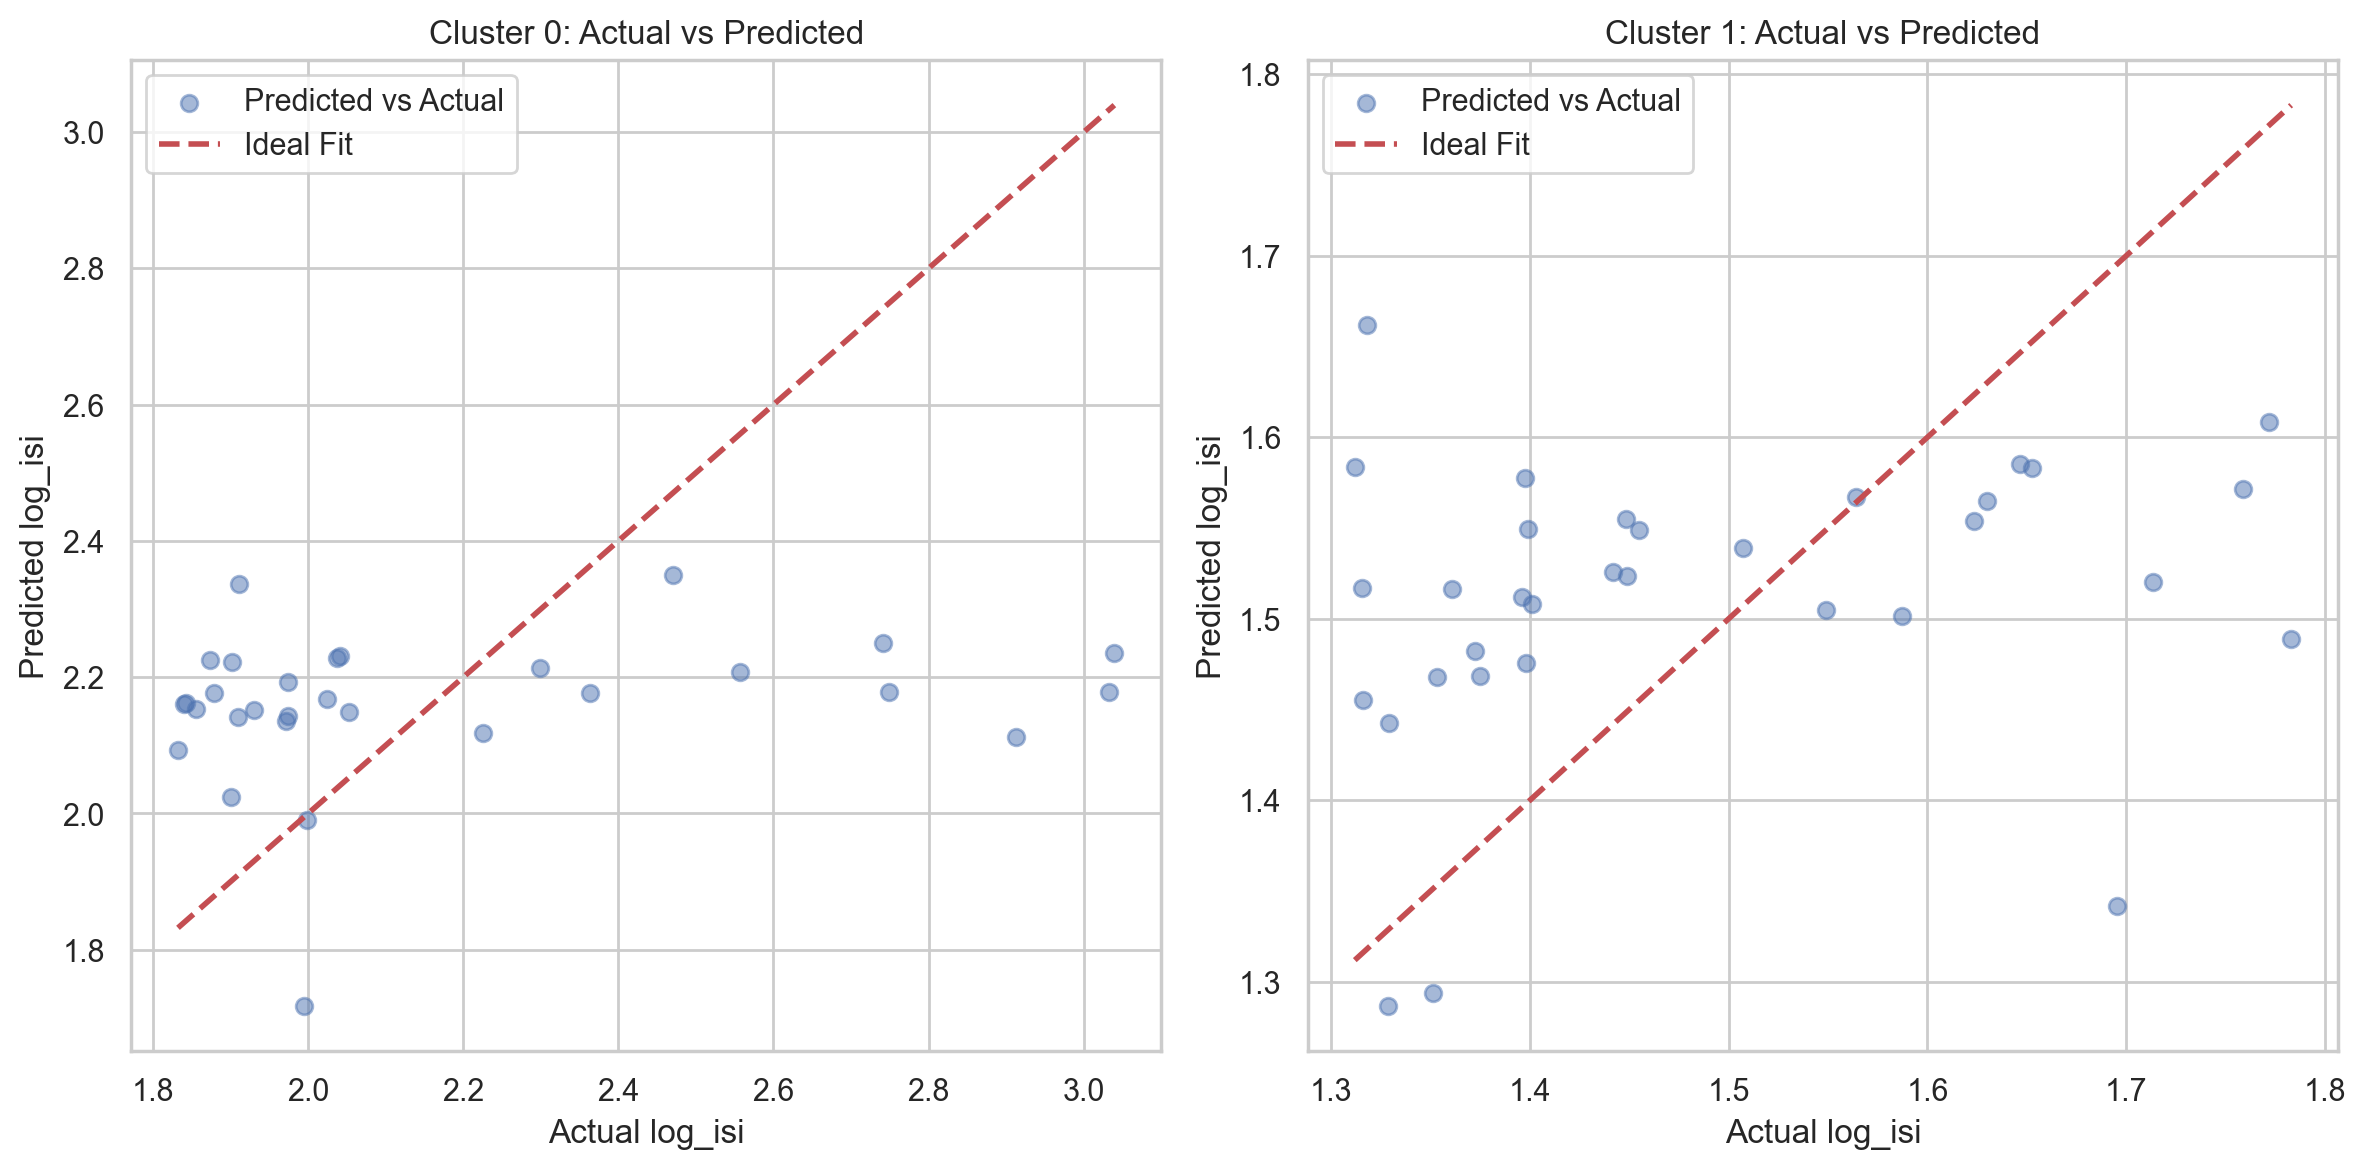

In [32]:
# Visualize the results

# Plotting actual vs predicted values for Cluster 0
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_test_0, predictions_0, alpha=0.5, label='Predicted vs Actual')
plt.plot([y_test_0.min(), y_test_0.max()], [y_test_0.min(), y_test_0.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel('Actual log_isi')
plt.ylabel('Predicted log_isi')
plt.title('Cluster 0: Actual vs Predicted')
plt.legend()
plt.grid(True)

# Plotting actual vs predicted values for Cluster 1
plt.subplot(1, 2, 2)
plt.scatter(y_test_1, predictions_1, alpha=0.5, label='Predicted vs Actual')
plt.plot([y_test_1.min(), y_test_1.max()], [y_test_1.min(), y_test_1.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel('Actual log_isi')
plt.ylabel('Predicted log_isi')
plt.title('Cluster 1: Actual vs Predicted')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

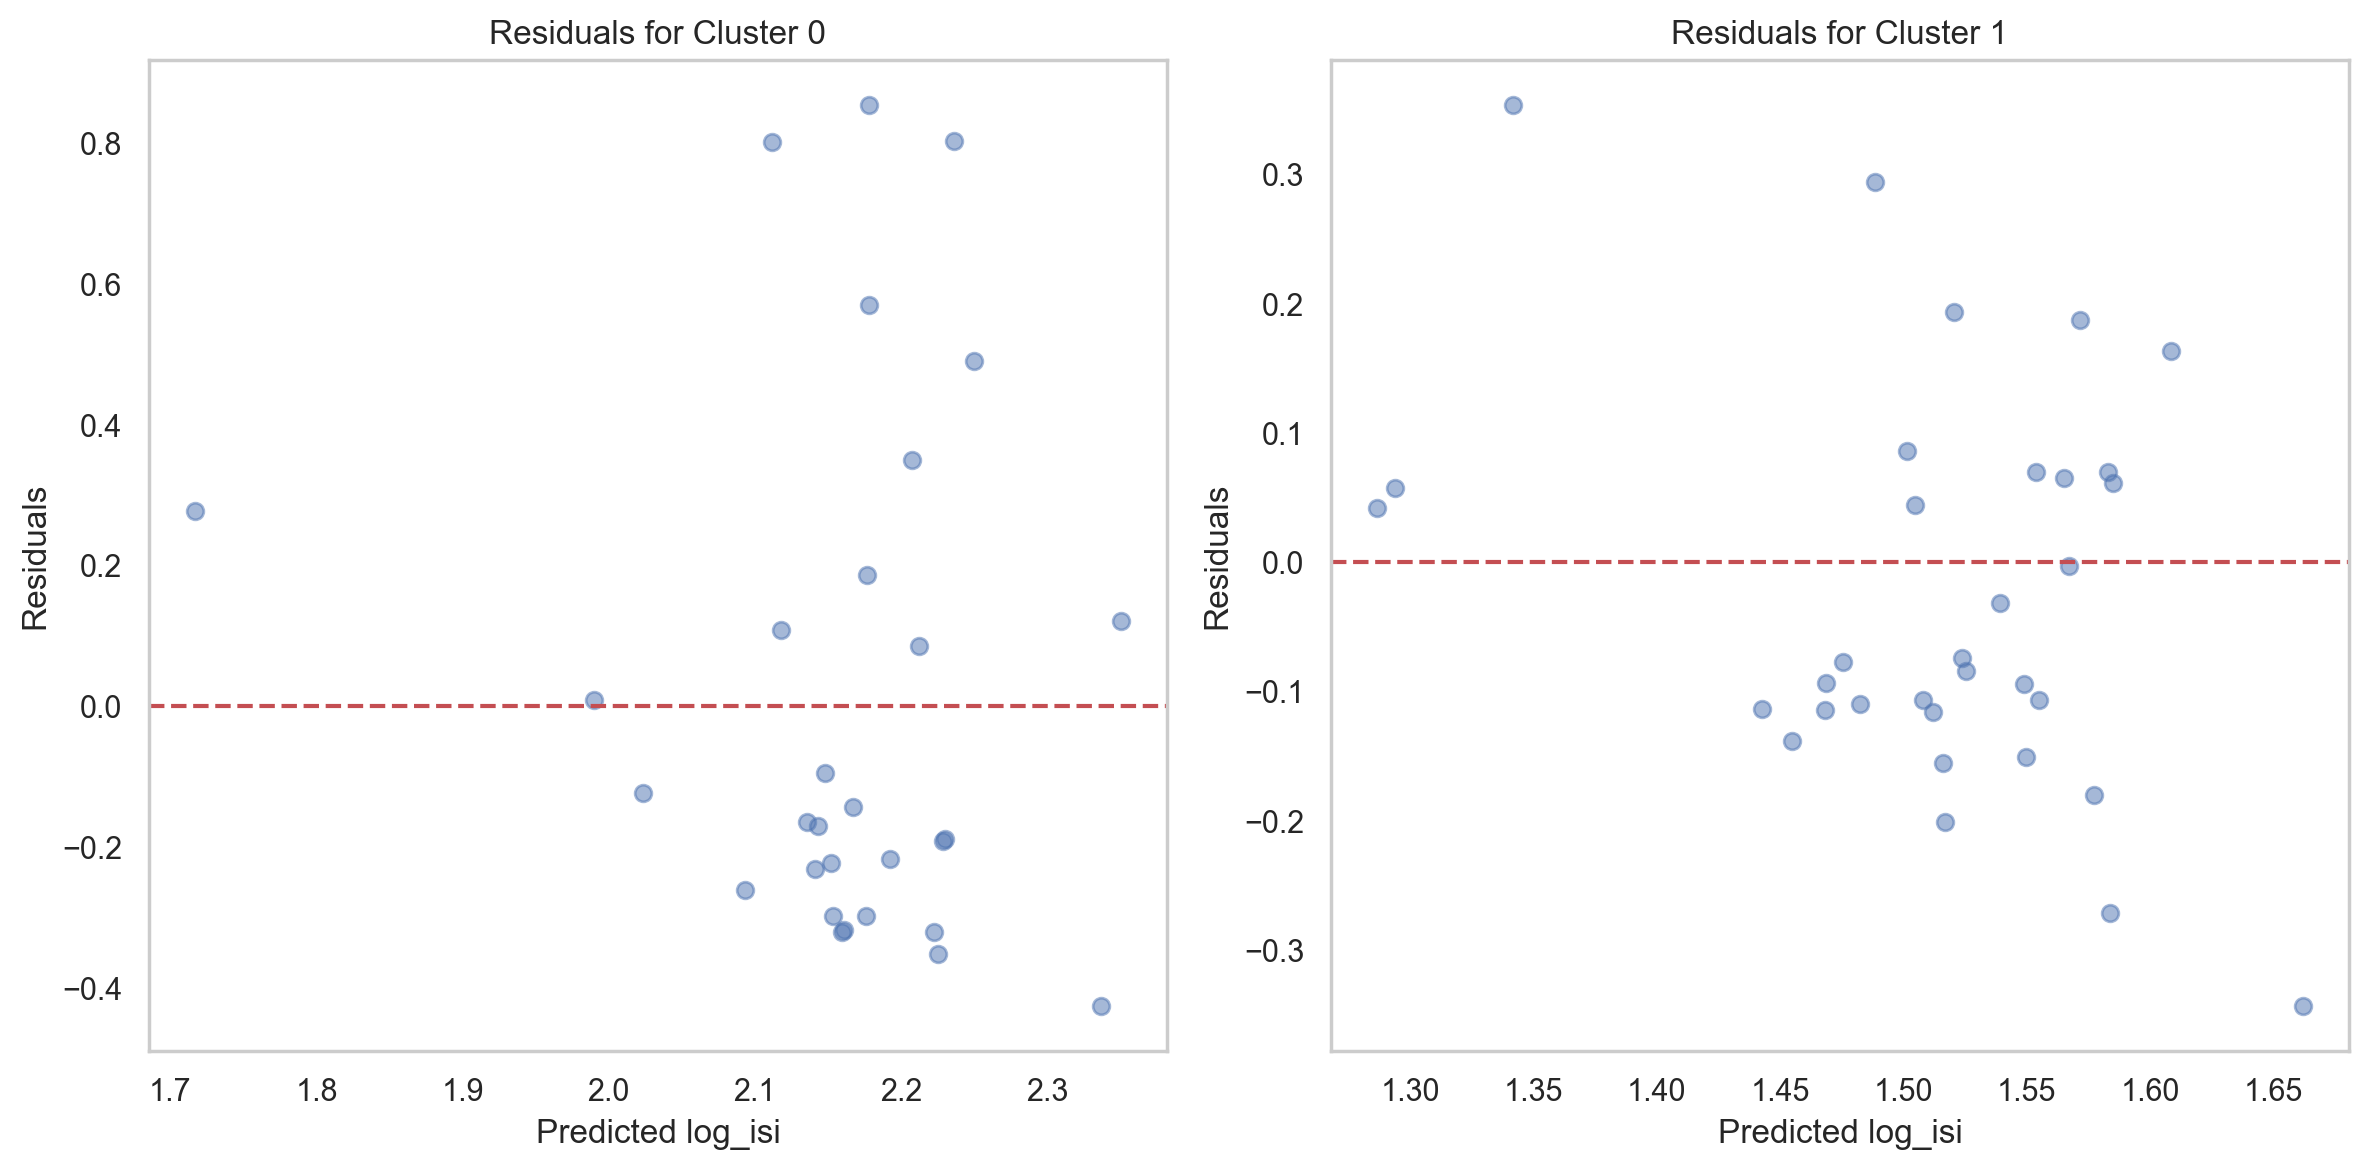

In [33]:
# Calculate residuals
residuals_0 = y_test_0 - predictions_0
residuals_1 = y_test_1 - predictions_1

# Plot residuals for Cluster 0
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(predictions_0, residuals_0, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted log_isi')
plt.ylabel('Residuals')
plt.title('Residuals for Cluster 0')

# Plot residuals for Cluster 1
plt.subplot(1, 2, 2)
plt.scatter(predictions_1, residuals_1, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted log_isi')
plt.ylabel('Residuals')
plt.title('Residuals for Cluster 1')

plt.tight_layout()
plt.show()

In [34]:
### Feature importance

num_features_0 = features_cluster_0.shape[1]
num_features_1 = features_cluster_1.shape[1]

features_0 = [f'Feature_{i}' for i in range(num_features_0)]
features_1 = [f'Feature_{i}' for i in range(num_features_1)]

# Extract coefficients from the trained models
coefficients_0 = model_0.coef_
coefficients_1 = model_1.coef_

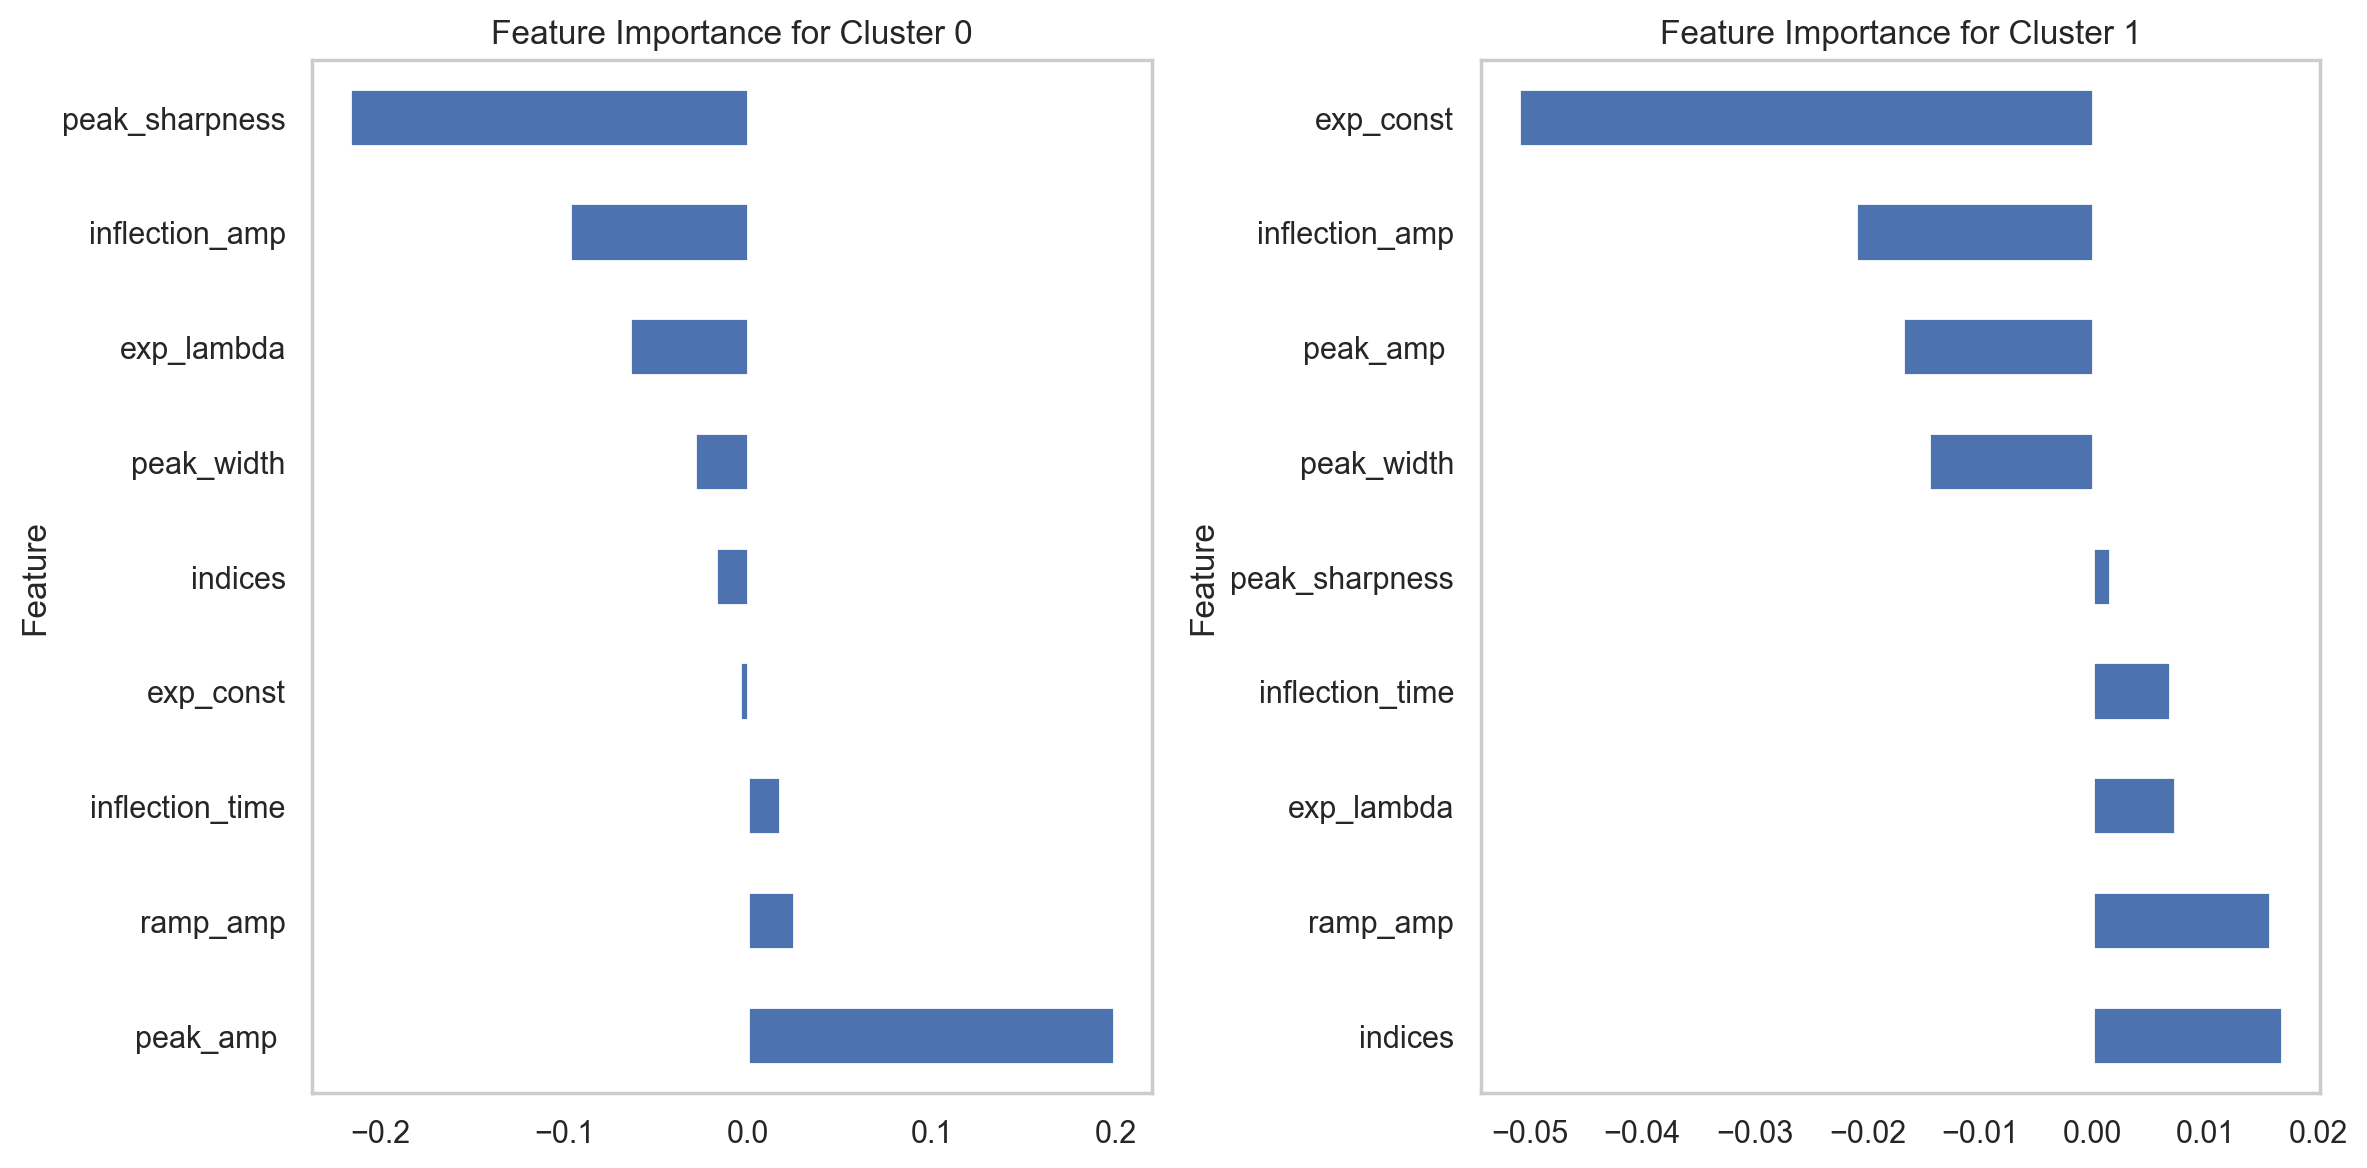

In [35]:
# Assuming you have the actual feature names
actual_feature_names = ['ramp_amp', 'inflection_time', 	'inflection_amp', 	'peak_amp ',	'peak_width', 	'peak_sharpness', 	'exp_lambda', 	'exp_const', 'indices']  # replace with your actual feature names


# Create DataFrames for feature importance
feature_importance_0 = pd.DataFrame({
    'Feature': actual_feature_names,
    'Importance': coefficients_0
})

feature_importance_1 = pd.DataFrame({
    'Feature': actual_feature_names,
    'Importance': coefficients_1
})

# Plot feature importance for Cluster 0
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
feature_importance_0.sort_values(by='Importance', ascending=False).plot.barh(x='Feature', y='Importance', ax=plt.gca(), legend=False)
plt.title('Feature Importance for Cluster 0')

# Plot feature importance for Cluster 1
plt.subplot(1, 2, 2)
feature_importance_1.sort_values(by='Importance', ascending=False).plot.barh(x='Feature', y='Importance', ax=plt.gca(), legend=False)
plt.title('Feature Importance for Cluster 1')

plt.tight_layout()
plt.show()


### Run regression without splitting into clusters 

In [36]:
# Standardize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(features_scaled, target, test_size=0.2, random_state=42)


In [37]:
# Train model with progress tracking
start_time = time.time()
model = train_model_with_progress(X_train, y_train)
print("Training time for the model:", time.time() - start_time)

# Predict and calculate mean squared error and R-squared
predictions_all = model.predict(X_test)
mse_all= mean_squared_error(y_test, predictions_all)
r2_all = r2_score(y_test, predictions_all)
print(f'Mean Squared Error: {mse_all}')
print(f'R-squared: {r2_all}')

Training Ridge Regression:   0%|          | 0/1000 [00:00<?, ?it/s]

Training time for the model: 2.094120979309082
Mean Squared Error: 0.1688725881342698
R-squared: 0.13595093271567582


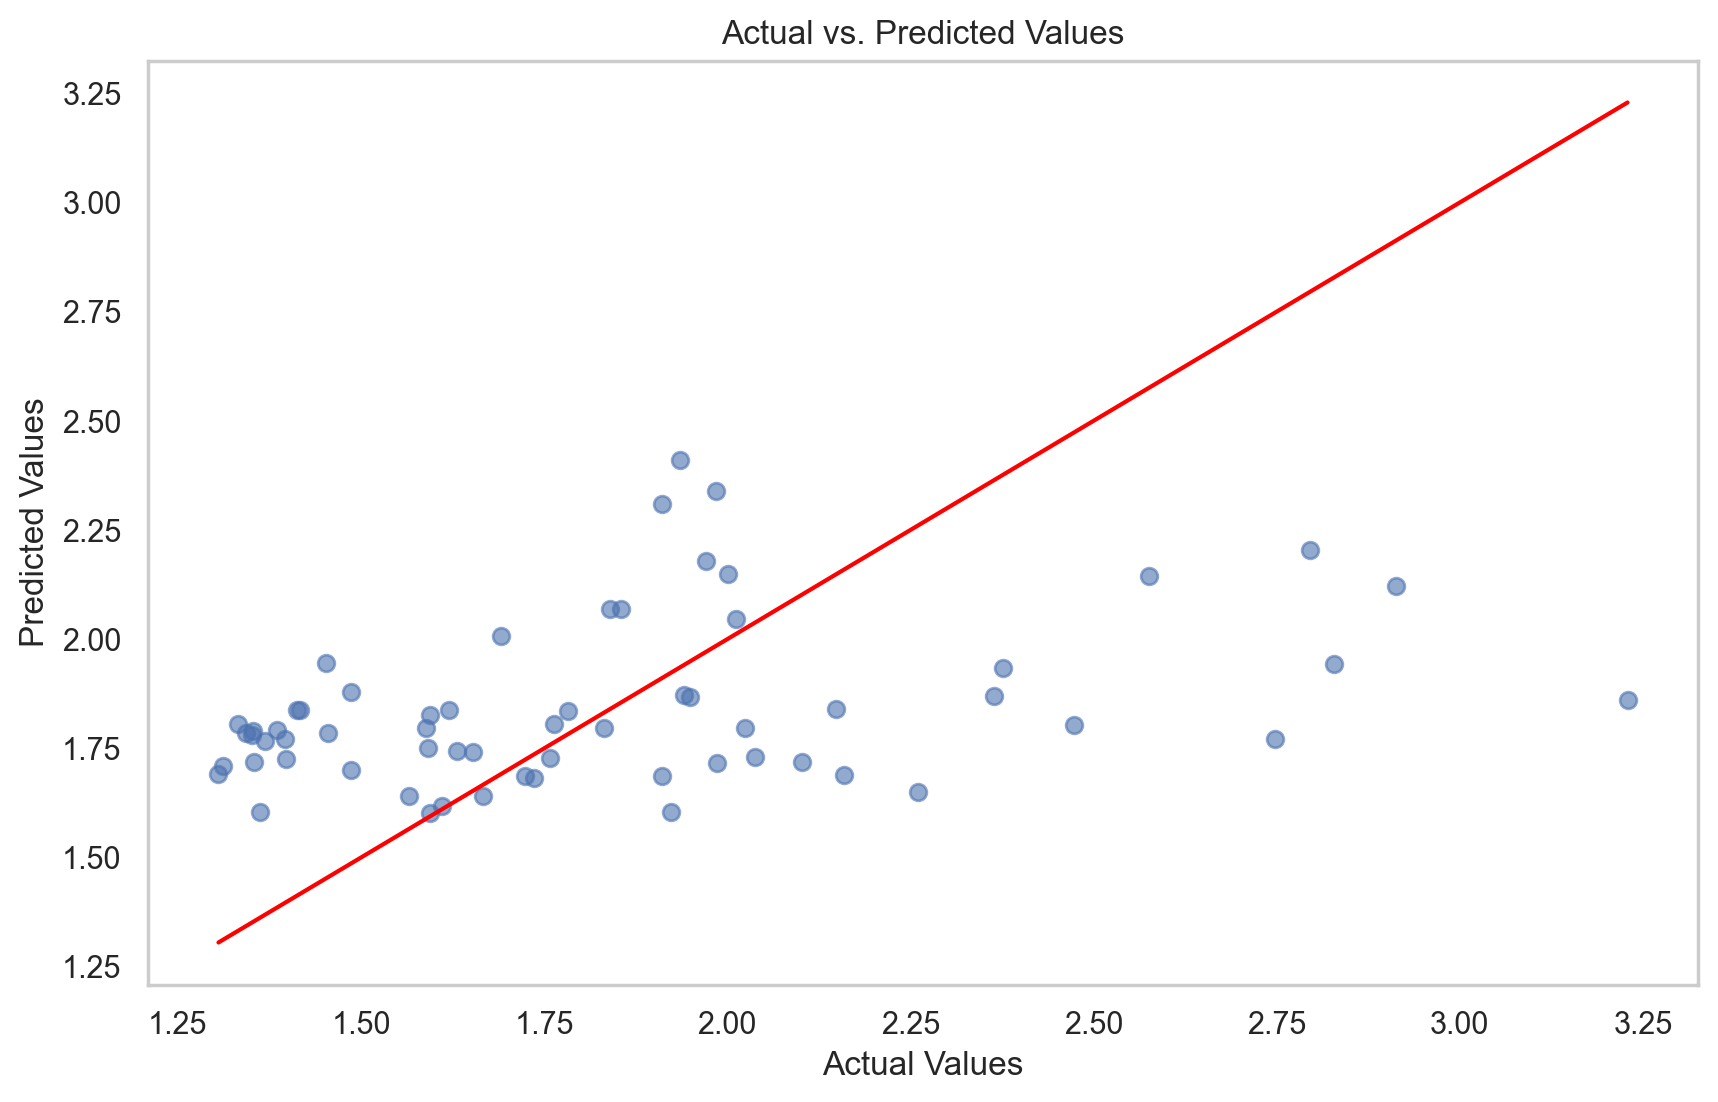

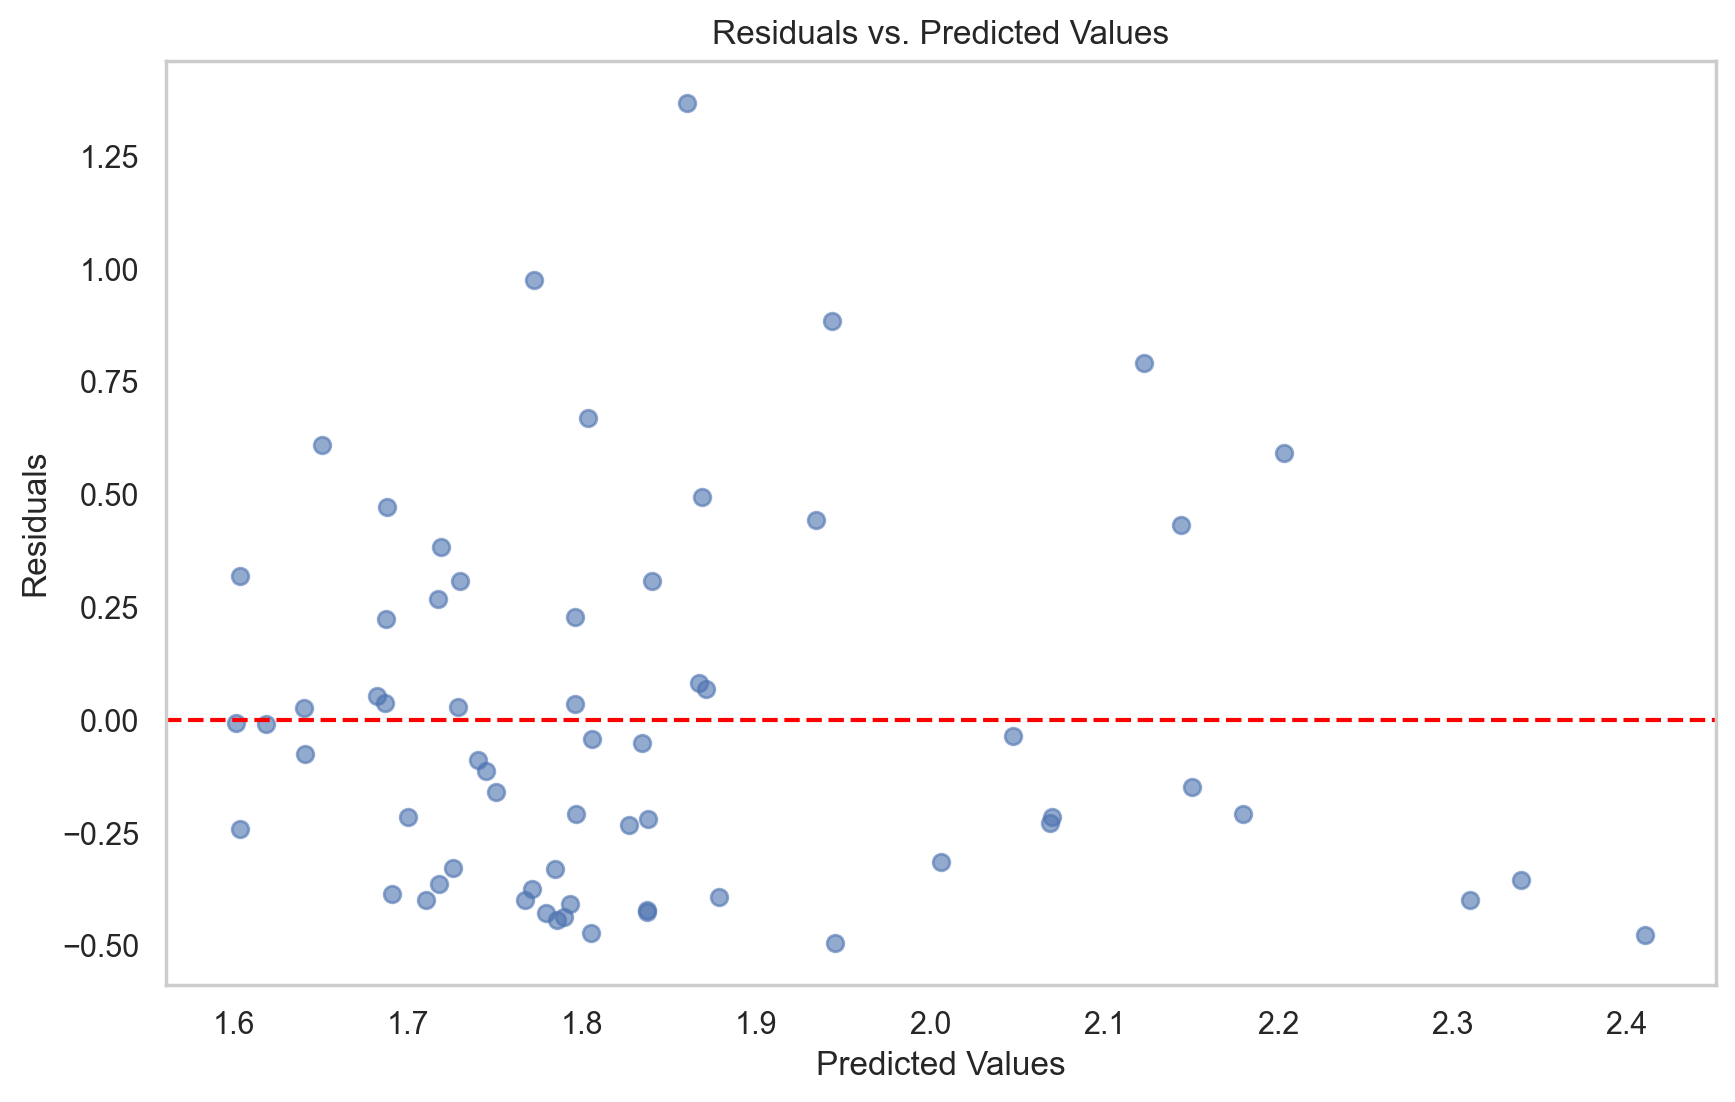

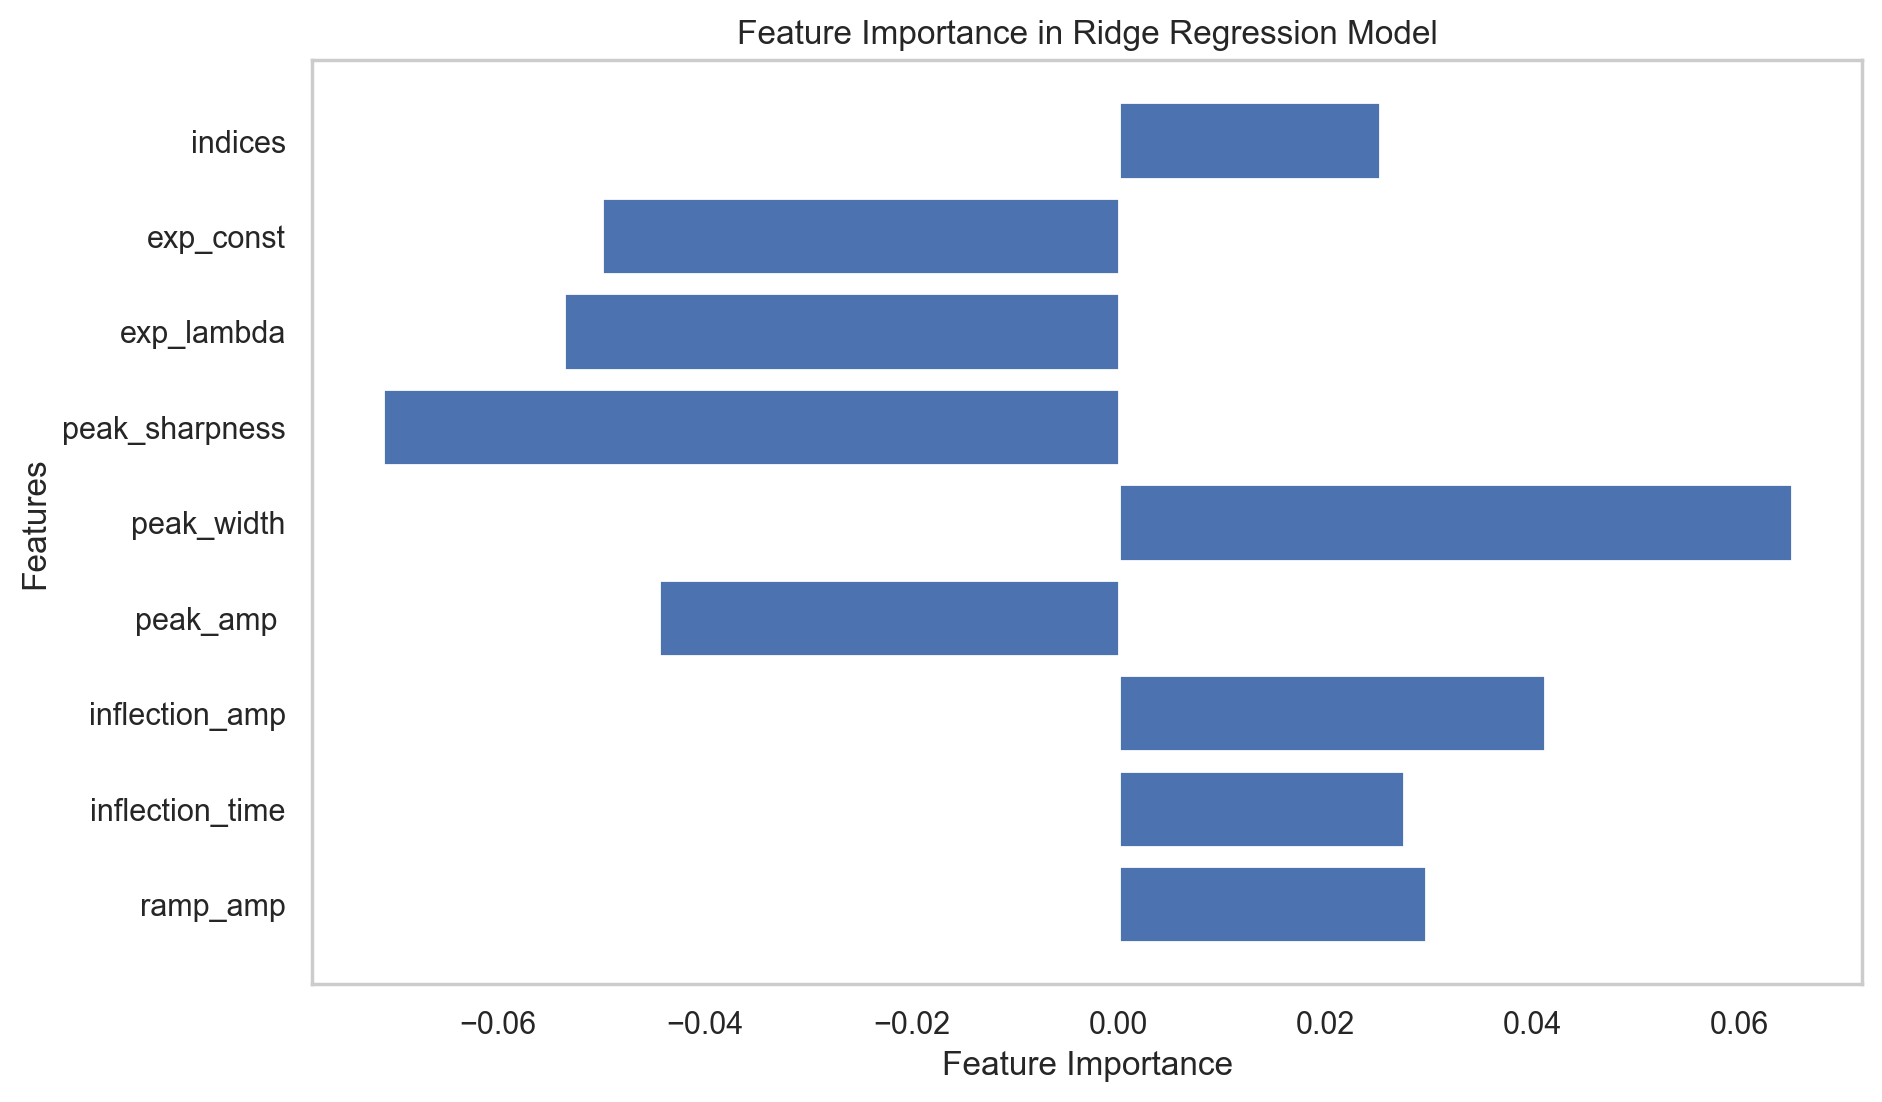

In [38]:
# Visualization of predictions
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions_all, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # 45-degree line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.show()

# Visualization of residuals
residuals = y_test - predictions_all
plt.figure(figsize=(10, 6))
plt.scatter(predictions_all, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Values')
plt.show()

# Feature importance
feature_importance = model.coef_

actual_feature_names = ['ramp_amp', 'inflection_time', 	'inflection_amp', 	'peak_amp ',	'peak_width', 	'peak_sharpness', 	'exp_lambda', 	'exp_const', 'indices']  # replace with your actual feature names

plt.figure(figsize=(10, 6))
plt.barh(np.arange(len(feature_importance)), feature_importance)
plt.yticks(np.arange(len(feature_importance)), actual_feature_names )  # Replace with actual feature names
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance in Ridge Regression Model')
plt.show()


### Compare models - not significantly diff based on MSE values, but differences (no stats) in rsq for the models 

In [39]:
# Predictions and metrics for Cluster 0
predictions_0 = model_0.predict(X_test_0)
mse_0 = mean_squared_error(y_test_0, predictions_0)
r2_0 = r2_score(y_test_0, predictions_0)

# Predictions and metrics for Cluster 1
predictions_1 = model_1.predict(X_test_1)
mse_1 = mean_squared_error(y_test_1, predictions_1)
r2_1 = r2_score(y_test_1, predictions_1)

# Predictions and metrics for the entire dataset
predictions_all = model.predict(X_test)
mse_all = mean_squared_error(y_test, predictions_all)
r2_all = r2_score(y_test, predictions_all)

print(f'MSE for Cluster 0: {mse_0}')
print(f'R² for Cluster 0: {r2_0}')
print(f'MSE for Cluster 1: {mse_1}')
print(f'R² for Cluster 1: {r2_1}')
print(f'MSE for Entire dataset: {mse_all}')
print(f'R² for Entire dataset: {r2_all}')

MSE for Cluster 0: 0.13450148232753467
R² for Cluster 0: 0.038533101655078617
MSE for Cluster 1: 0.02379502570174349
R² for Cluster 1: -0.06097805015090829
MSE for Entire dataset: 0.1688725881342698
R² for Entire dataset: 0.13595093271567582


In [40]:
# Calculate individual prediction errors
errors_0 = y_test_0 - predictions_0
errors_1 = y_test_1 - predictions_1
errors_all = y_test - predictions_all

In [41]:
from scipy.stats import f_oneway

# Perform ANOVA using the prediction errors
F_mse, p_value_mse = f_oneway(errors_0, errors_1, errors_all)

print(f'ANOVA results for MSE: F-statistic = {F_mse}, p-value = {p_value_mse}')



ANOVA results for MSE: F-statistic = 0.086676998960199, p-value = 0.9170291894373007


In [42]:
from scipy.stats import ttest_ind

# T-tests for MSEs
t_mse_0_1, p_mse_0_1 = ttest_ind(errors_0, errors_1)
t_mse_0_all, p_mse_0_all = ttest_ind(errors_0, errors_all)
t_mse_1_all, p_mse_1_all = ttest_ind(errors_1, errors_all)

print(f'T-test results for MSE between Cluster 0 and Cluster 1: t-statistic = {t_mse_0_1}, p-value = {p_mse_0_1}')
print(f'T-test results for MSE between Cluster 0 and entire dataset: t-statistic = {t_mse_0_all}, p-value = {p_mse_0_all}')
print(f'T-test results for MSE between Cluster 1 and entire dataset: t-statistic = {t_mse_1_all}, p-value = {p_mse_1_all}')


T-test results for MSE between Cluster 0 and Cluster 1: t-statistic = 0.5242832795135972, p-value = 0.6019815218909964
T-test results for MSE between Cluster 0 and entire dataset: t-statistic = 0.19388938003614725, p-value = 0.8466946502195277
T-test results for MSE between Cluster 1 and entire dataset: t-statistic = -0.2647147188852055, p-value = 0.7918088150776458


### Are the spikes in the cluster with shorter ISIs burst spikes?

Mean ISI for Cluster 0: 2.181005968879981
Mean ISI for Cluster 1: 1.5087139576304172
Cluster with shorter ISIs: 1
Indices of spikes with shorter ISIs: [  29   31  105  162  167  232  326  330  359  405  422  466  473  587
  590  611  645  655  686  701  737  847  906  918  971  983 1022 1023
 1040 1059 1067 1093 1124 1206 1268 1283 1334 1387 1396 1425 1460 1465
 1504 1519 1557 1608 1629 1669 1733 1741 1755 1785 1808 1866 1896 2074
 2079 2101 2116 2128 2142 2258 2274 2275 2289 2340 2345 2362 2367 2520
 2530 2554 2555 2745 2853 2910 2933 2958 2991 2995 3026 3027 3070 3072
 3113 3116 3212 3271 3283 3391 3442 3541 3572 3698 3721 3776 3829 3847
 3867 3879 3882 3929 3937 3985 4070 4159 4194 4233 4301 4335 4350 4496
 4521 4557 4638 4649 4666 4831 4893 4901 4916 4924 4935 4951 4959 4986
 4997 5042 5057 5069 5142 5199 5210 5239 5369 5379 5393 5415 5416 5440
 5459 5470 5539 5558 5561 5577 5653 5658 5662 5675 5708 5728 5733 5855
 5981 5994 6081 6101 6161 6310 6383 6404 6407 6418 6452]
Indices of 

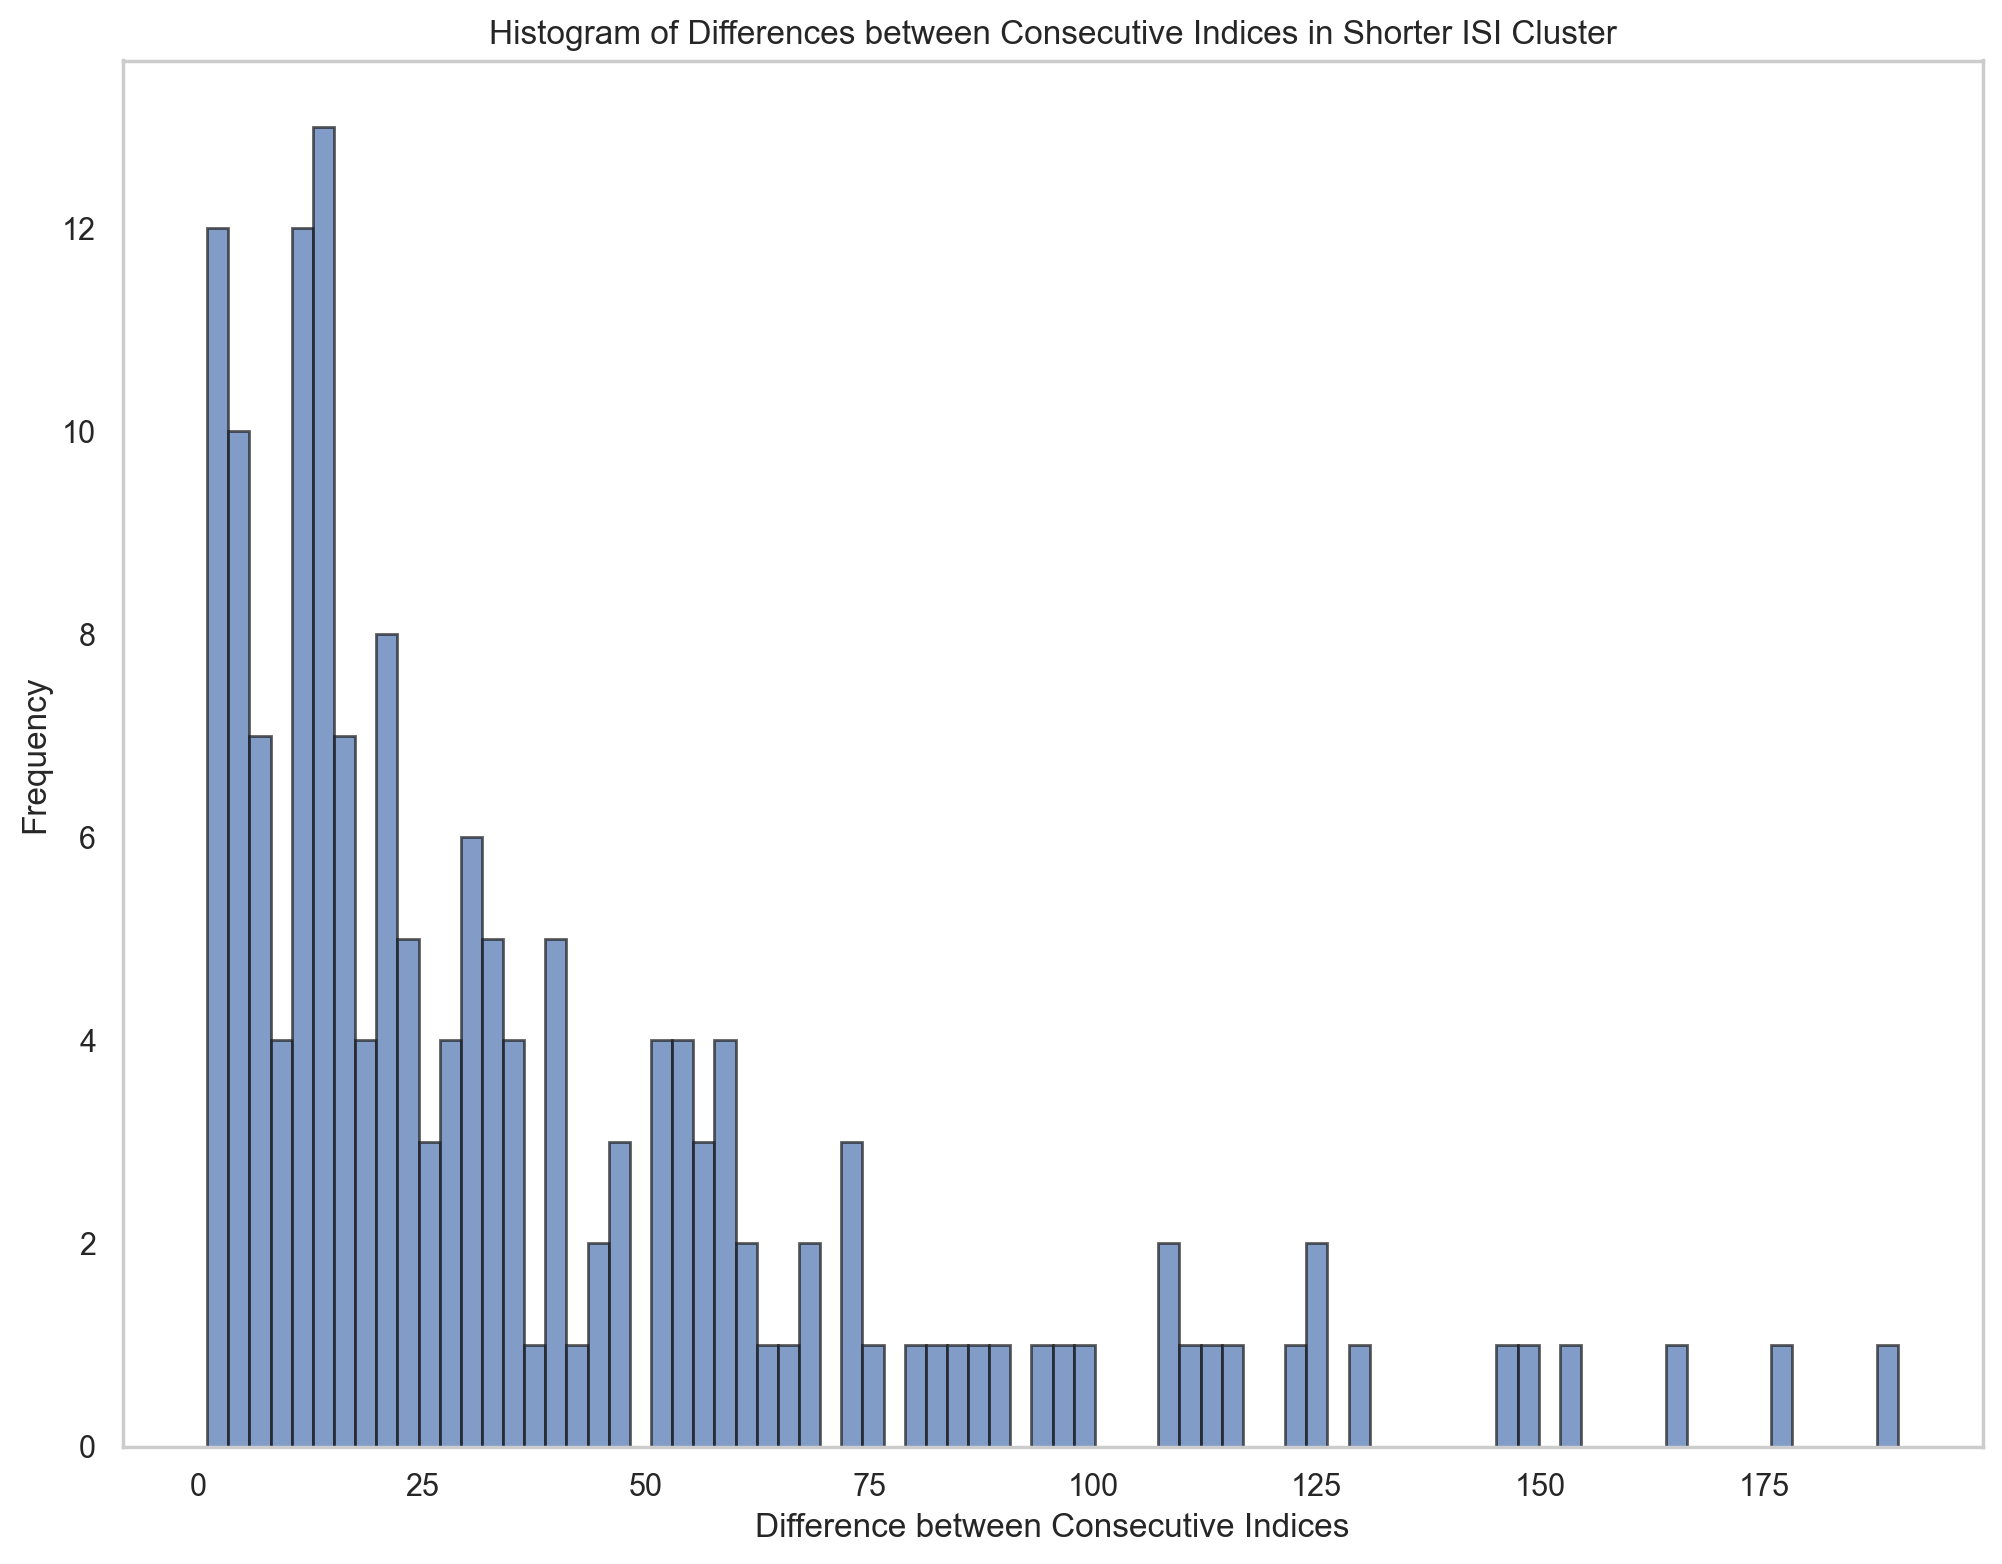

Differences between consecutive indices (longer ISI cluster): [ 78 142 141 102  58  20  66  18  97 113  57  39   3  10 109  13   2  27
  79  49  23  13  30   9 218  30  69  46  17 130   6  65   7  41  96 107
  96  53  52 170   2  15  11 107  22  35  27  36  60  44  11  11 151  50
   5   9  46  49  32  16  69  13  22   9  36  12  24  49  20  19  56  13
  49  55  21  14  32   4   2  11  36  50   3  22  74  42   9  11  20  22
  15 110  31  59  27  29 141   5   6   8   4  48  20 116   2  54   5  48
  17  99  13   5  39  20 105 100  27  56  71  30 132  10  72  42 117  33
   8   3  41  41  44   9  43 117  16  11  12  50  13  14  27  10  38  14
   8]


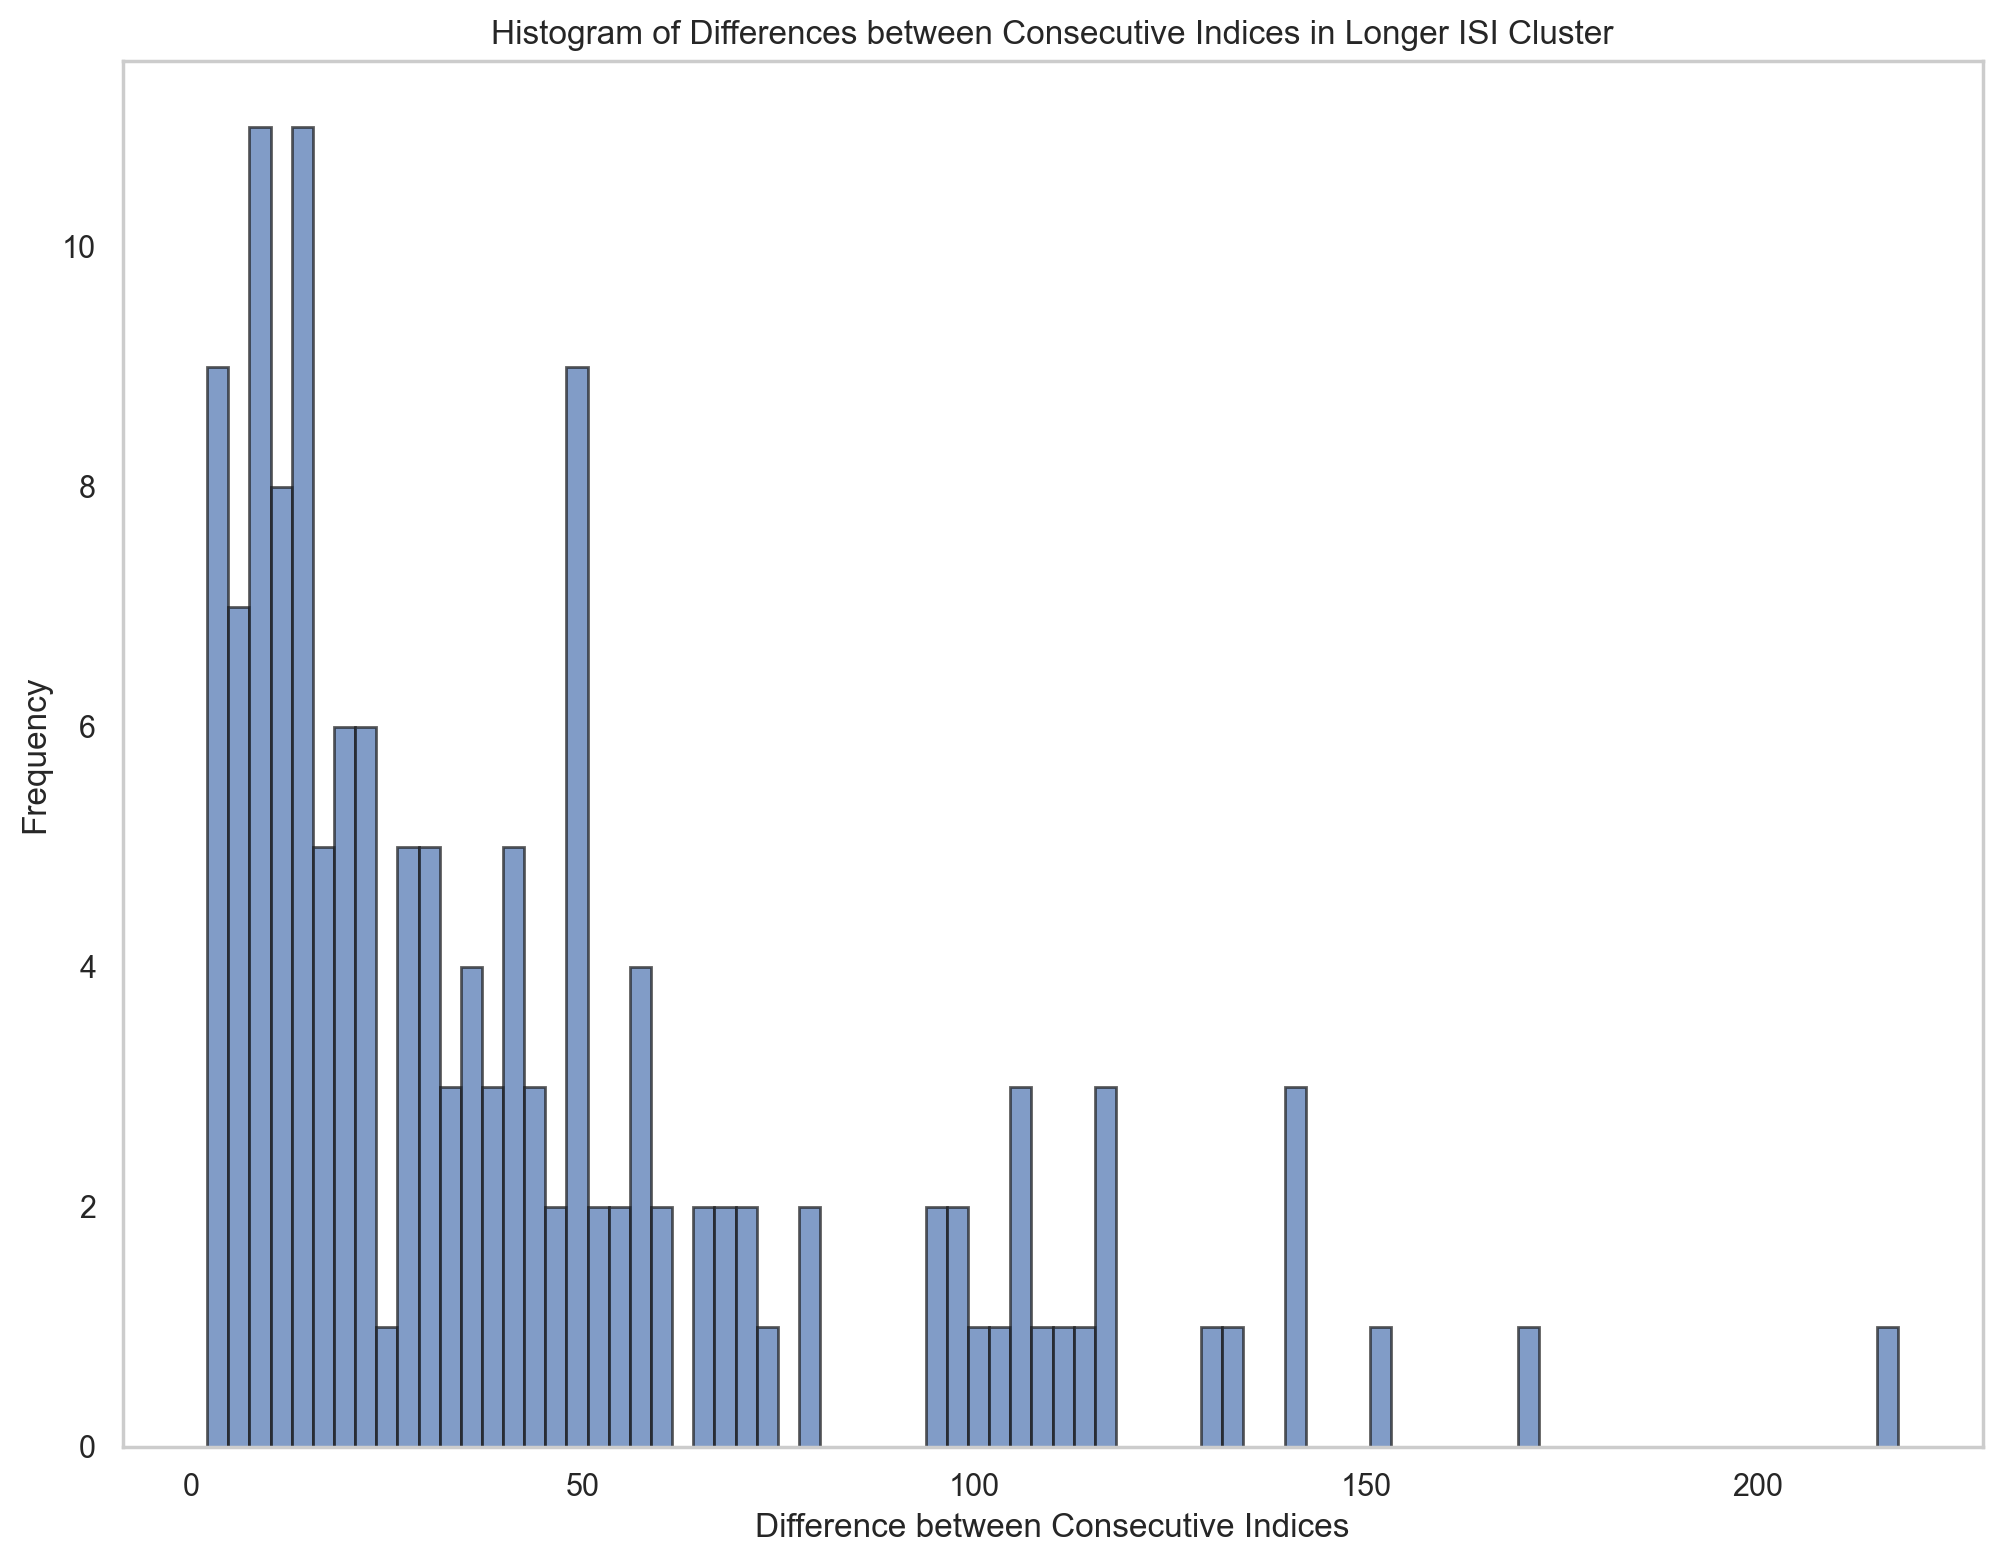

In [43]:
# Add cluster labels to the DataFrame
df_features['cluster'] = clusters

# Split data into clusters
df_cluster_0 = df_features[df_features['cluster'] == 0]
df_cluster_1 = df_features[df_features['cluster'] == 1]

# Determine which cluster has shorter ISIs
mean_isi_cluster_0 = np.mean(df_cluster_0['log_isi'])
mean_isi_cluster_1 = np.mean(df_cluster_1['log_isi'])

print(f"Mean ISI for Cluster 0: {mean_isi_cluster_0}")
print(f"Mean ISI for Cluster 1: {mean_isi_cluster_1}")

# Identify the cluster with shorter ISIs
shorter_isi_cluster = 0 if mean_isi_cluster_0 < mean_isi_cluster_1 else 1
longer_isi_cluster = 1 if shorter_isi_cluster == 0 else 0

print(f"Cluster with shorter ISIs: {shorter_isi_cluster}")

# Extract original indices for both clusters
if shorter_isi_cluster == 0:
    shorter_isi_indices = df_cluster_0['original_index']
    longer_isi_indices = df_cluster_1['original_index']
else:
    shorter_isi_indices = df_cluster_1['original_index']
    longer_isi_indices = df_cluster_0['original_index']

print(f"Indices of spikes with shorter ISIs: {shorter_isi_indices.values}")
print(f"Indices of spikes with longer ISIs: {longer_isi_indices.values}")

# Analyze indices for bursts
# Check if indices are sequential or almost sequential for shorter ISI cluster
sorted_indices_shorter = np.sort(shorter_isi_indices.values)
differences_shorter = np.diff(sorted_indices_shorter)
print(f"Differences between consecutive indices (shorter ISI cluster): {differences_shorter}")

# Plot histogram of differences to visualize the burst pattern for shorter ISI cluster
plt.hist(differences_shorter, bins=80, edgecolor='k', alpha=0.7)
plt.xlabel('Difference between Consecutive Indices')
plt.ylabel('Frequency')
plt.title('Histogram of Differences between Consecutive Indices in Shorter ISI Cluster')

plt.show()

# Check if indices are sequential or almost sequential for longer ISI cluster
sorted_indices_longer = np.sort(longer_isi_indices.values)
differences_longer = np.diff(sorted_indices_longer)
print(f"Differences between consecutive indices (longer ISI cluster): {differences_longer}")

# Plot histogram of differences to visualize the burst pattern for longer ISI cluster
plt.hist(differences_longer, bins=80, edgecolor='k', alpha=0.7)
plt.xlabel('Difference between Consecutive Indices')
plt.ylabel('Frequency')
plt.title('Histogram of Differences between Consecutive Indices in Longer ISI Cluster')

plt.show()

In [44]:
# Extract spike times (original indices) for both clusters
if shorter_isi_cluster == 0:
    shorter_isi_indices = df_cluster_0['original_index']
    longer_isi_indices = df_cluster_1['original_index']
else:
    shorter_isi_indices = df_cluster_1['original_index']
    longer_isi_indices = df_cluster_0['original_index']

print(f"Indices of spikes with shorter ISIs: {shorter_isi_indices.values}")
print(f"Indices of spikes with longer ISIs: {longer_isi_indices.values}")


Indices of spikes with shorter ISIs: [  29   31  105  162  167  232  326  330  359  405  422  466  473  587
  590  611  645  655  686  701  737  847  906  918  971  983 1022 1023
 1040 1059 1067 1093 1124 1206 1268 1283 1334 1387 1396 1425 1460 1465
 1504 1519 1557 1608 1629 1669 1733 1741 1755 1785 1808 1866 1896 2074
 2079 2101 2116 2128 2142 2258 2274 2275 2289 2340 2345 2362 2367 2520
 2530 2554 2555 2745 2853 2910 2933 2958 2991 2995 3026 3027 3070 3072
 3113 3116 3212 3271 3283 3391 3442 3541 3572 3698 3721 3776 3829 3847
 3867 3879 3882 3929 3937 3985 4070 4159 4194 4233 4301 4335 4350 4496
 4521 4557 4638 4649 4666 4831 4893 4901 4916 4924 4935 4951 4959 4986
 4997 5042 5057 5069 5142 5199 5210 5239 5369 5379 5393 5415 5416 5440
 5459 5470 5539 5558 5561 5577 5653 5658 5662 5675 5708 5728 5733 5855
 5981 5994 6081 6101 6161 6310 6383 6404 6407 6418 6452]
Indices of spikes with longer ISIs: [ 168  246  388  529  631  689  709  775  793  890 1003 1060 1099 1102
 1112 1221 1234 12

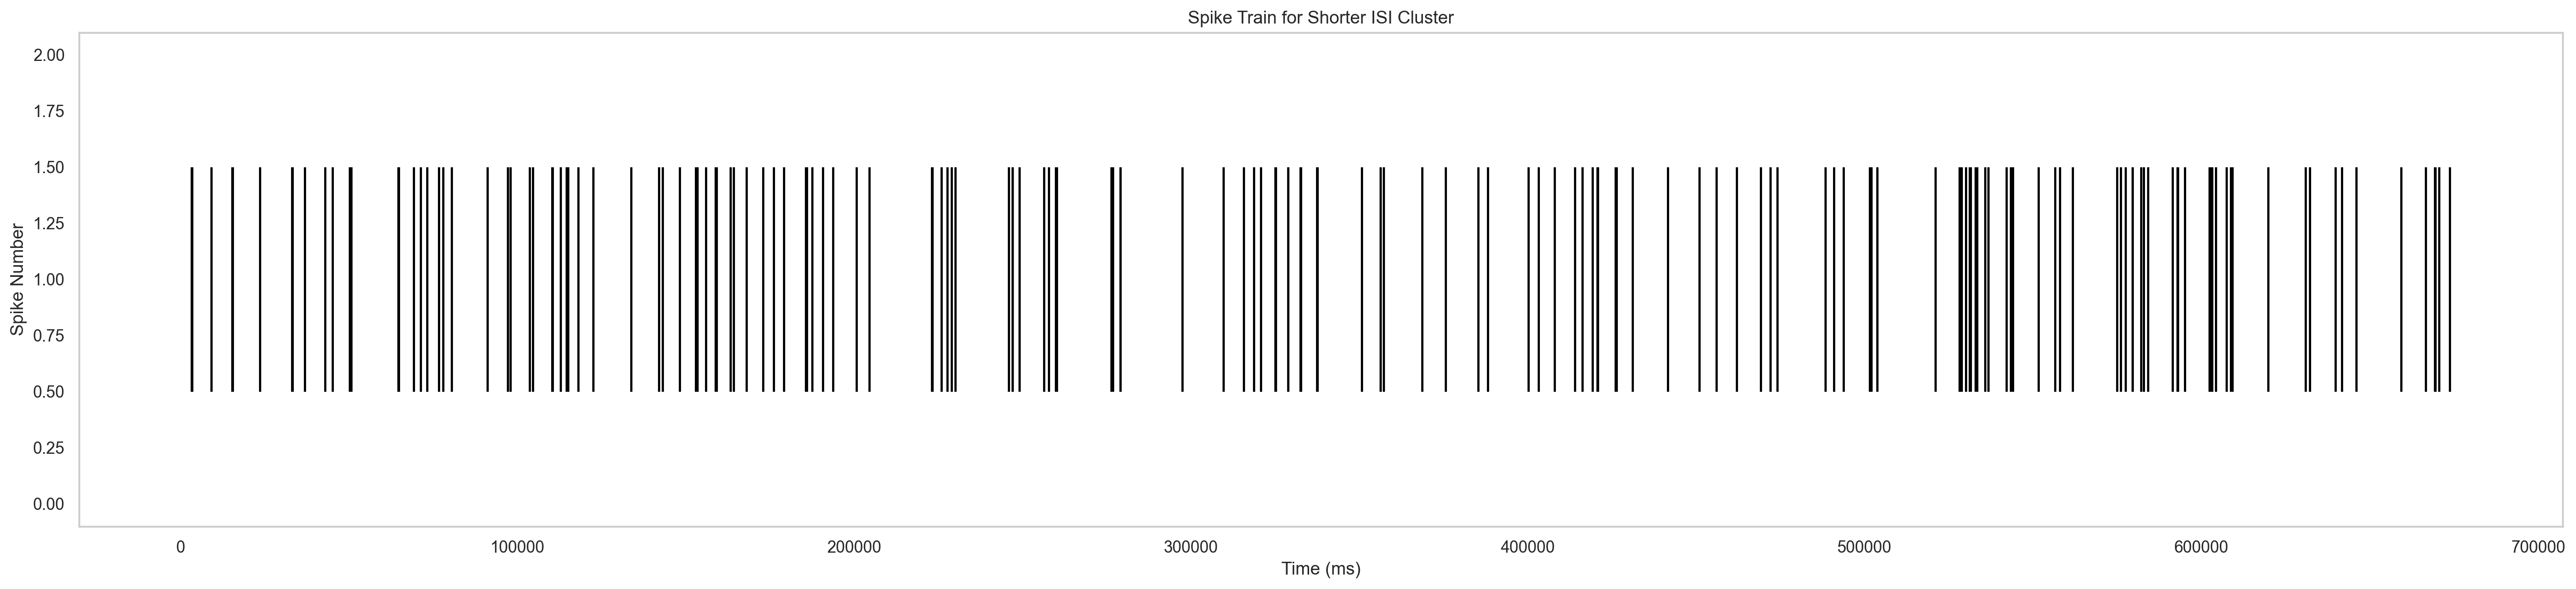

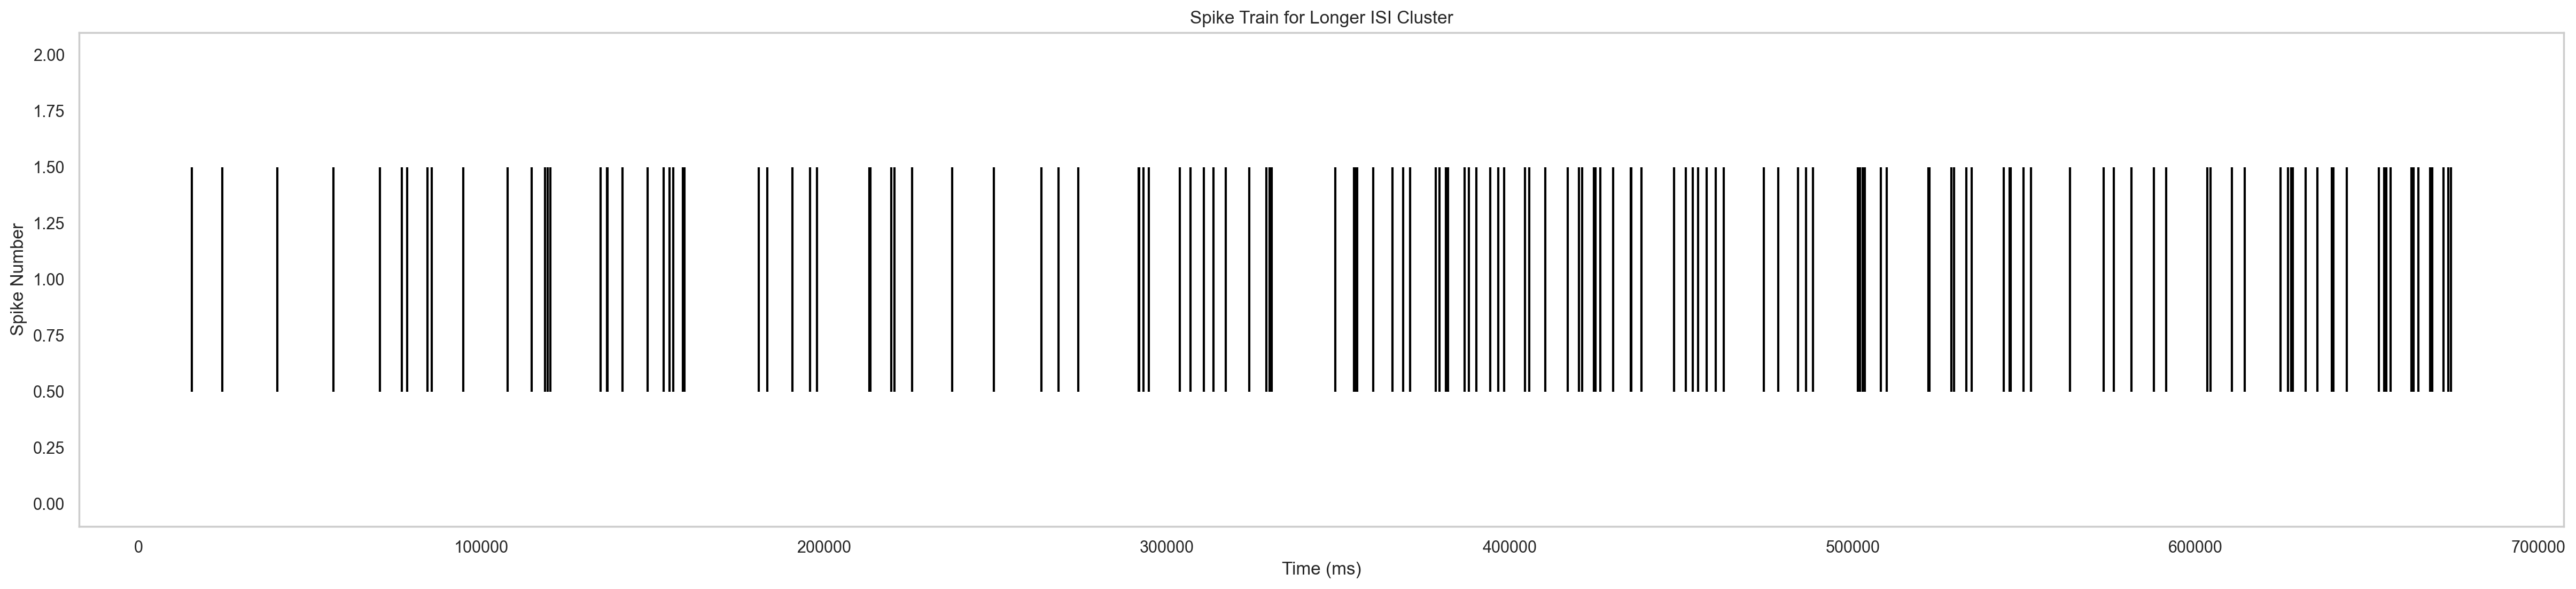

In [45]:

# Function to plot raster plot
def plot_raster(spike_indices, title):
    plt.figure(figsize=(30, 6))
    plt.eventplot(patch_times_c16[sp.spike_inds[spike_indices]], orientation='horizontal', colors='black')
    plt.xlabel('Time (ms)')
    plt.ylabel('Spike Number')
    plt.title(title)
    plt.show()

# Plot raster plots for both clusters
plot_raster(sorted_indices_shorter, 'Spike Train for Shorter ISI Cluster')
plot_raster(sorted_indices_longer, 'Spike Train for Longer ISI Cluster')


## Since the differences in the 3 models are mot stat sig - move forward just with the model without clustering based on ISI?

### Visualize model results 

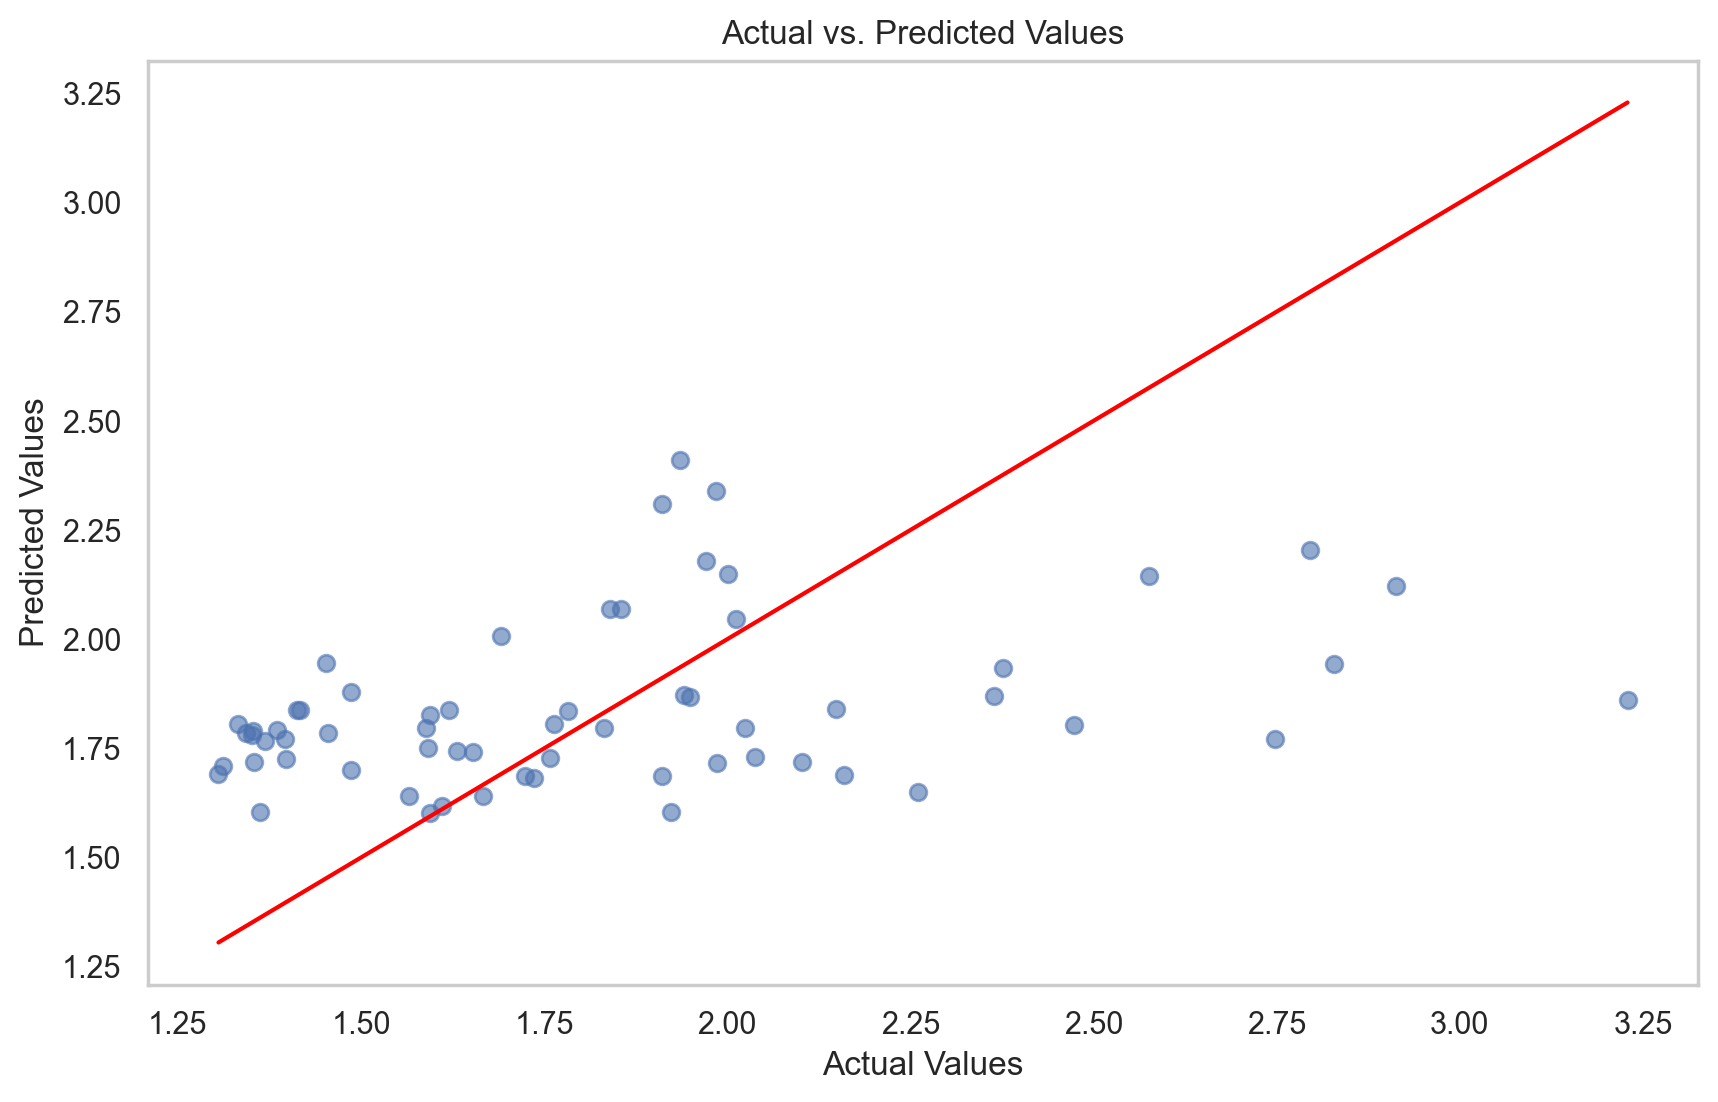

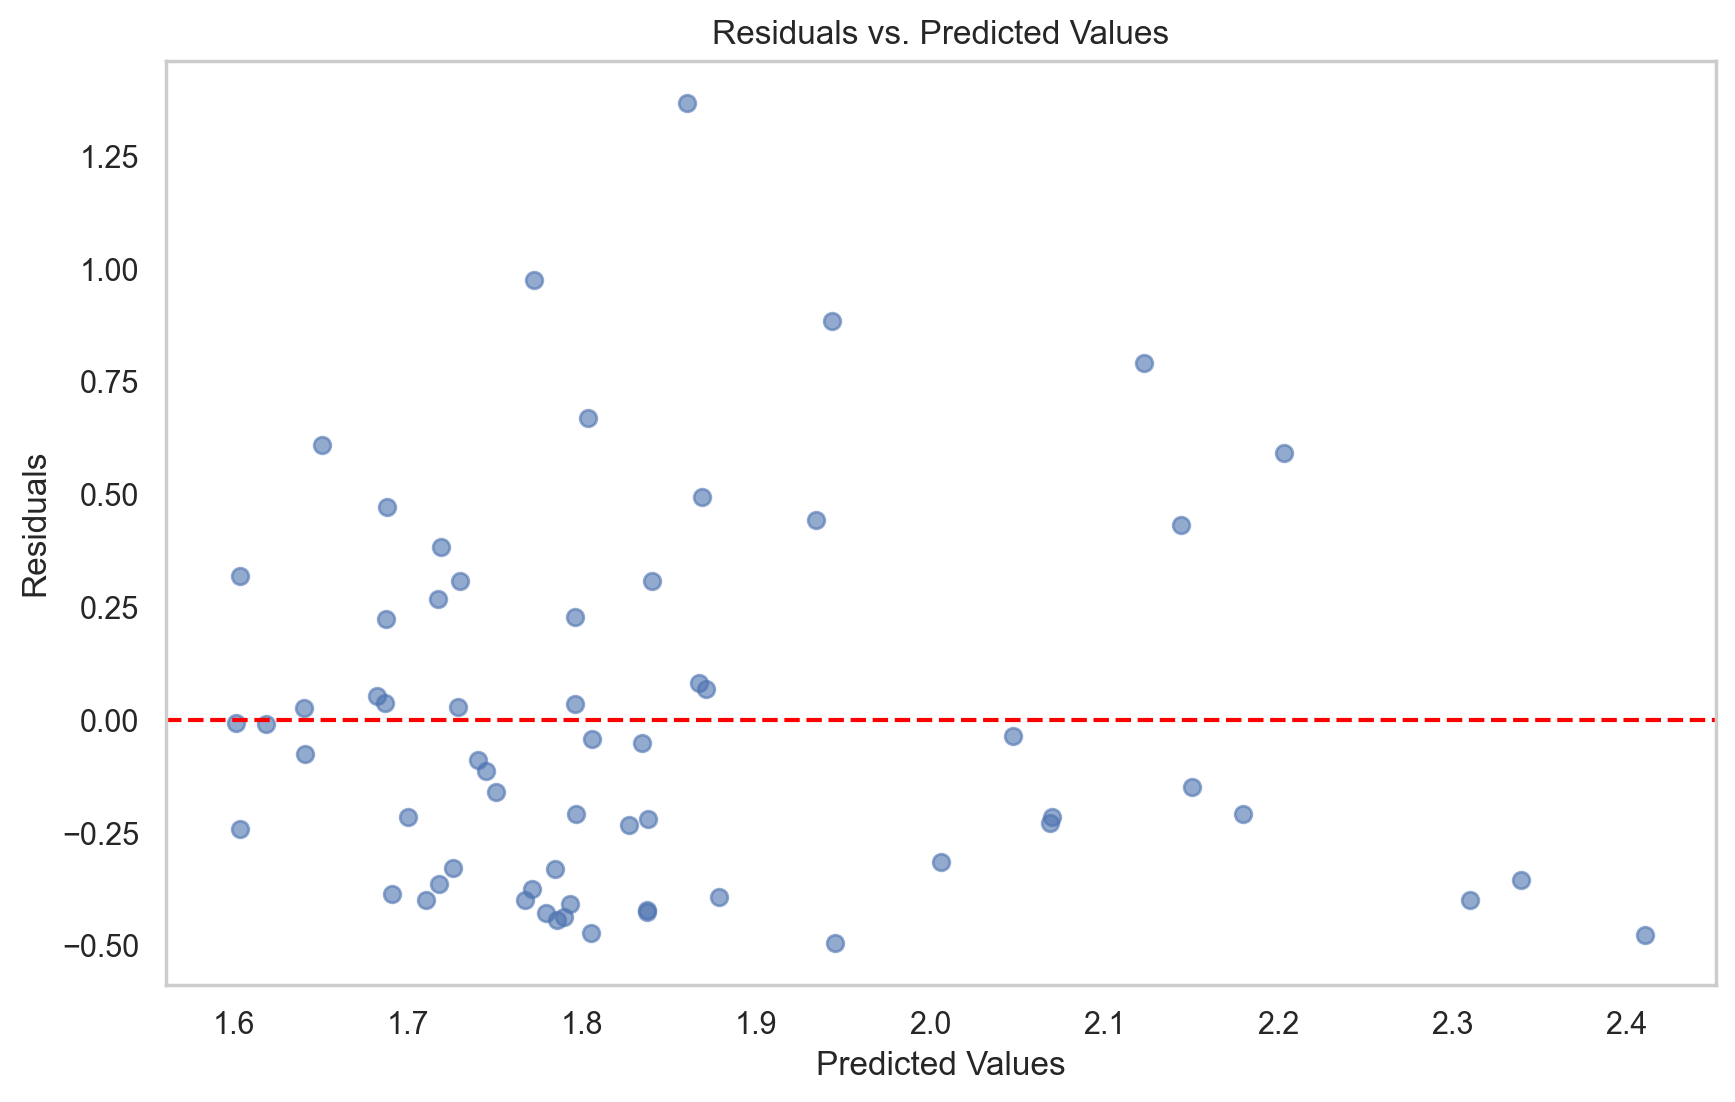

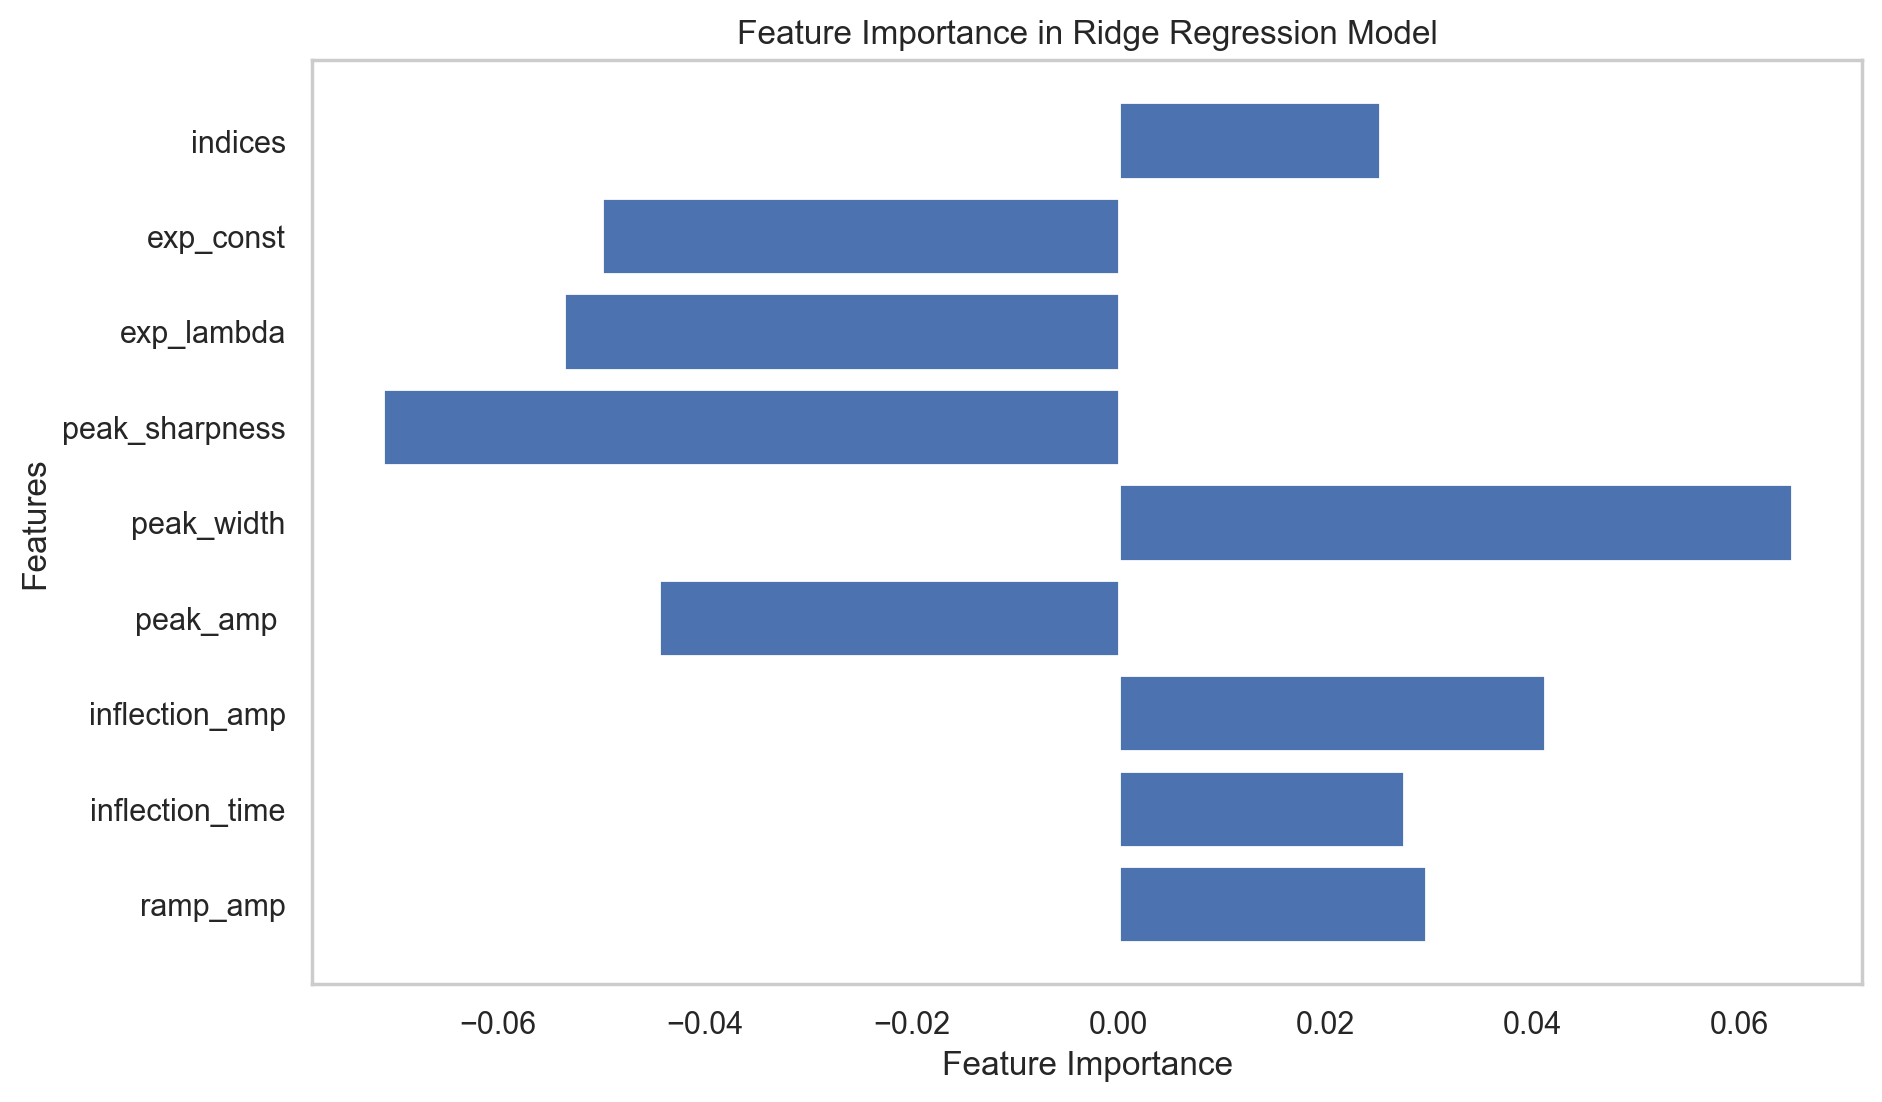

In [46]:
# Visualization of predictions
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions_all, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # 45-degree line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.show()

# Visualization of residuals
residuals = y_test - predictions_all
plt.figure(figsize=(10, 6))
plt.scatter(predictions_all, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Values')
plt.show()

# Feature importance
feature_importance = model.coef_

actual_feature_names = ['ramp_amp', 'inflection_time', 	'inflection_amp', 	'peak_amp ',	'peak_width', 	'peak_sharpness', 	'exp_lambda', 	'exp_const', 'indices']  # replace with your actual feature names

plt.figure(figsize=(10, 6))
plt.barh(np.arange(len(feature_importance)), feature_importance)
plt.yticks(np.arange(len(feature_importance)), actual_feature_names )  # Replace with actual feature names
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance in Ridge Regression Model')
plt.show()


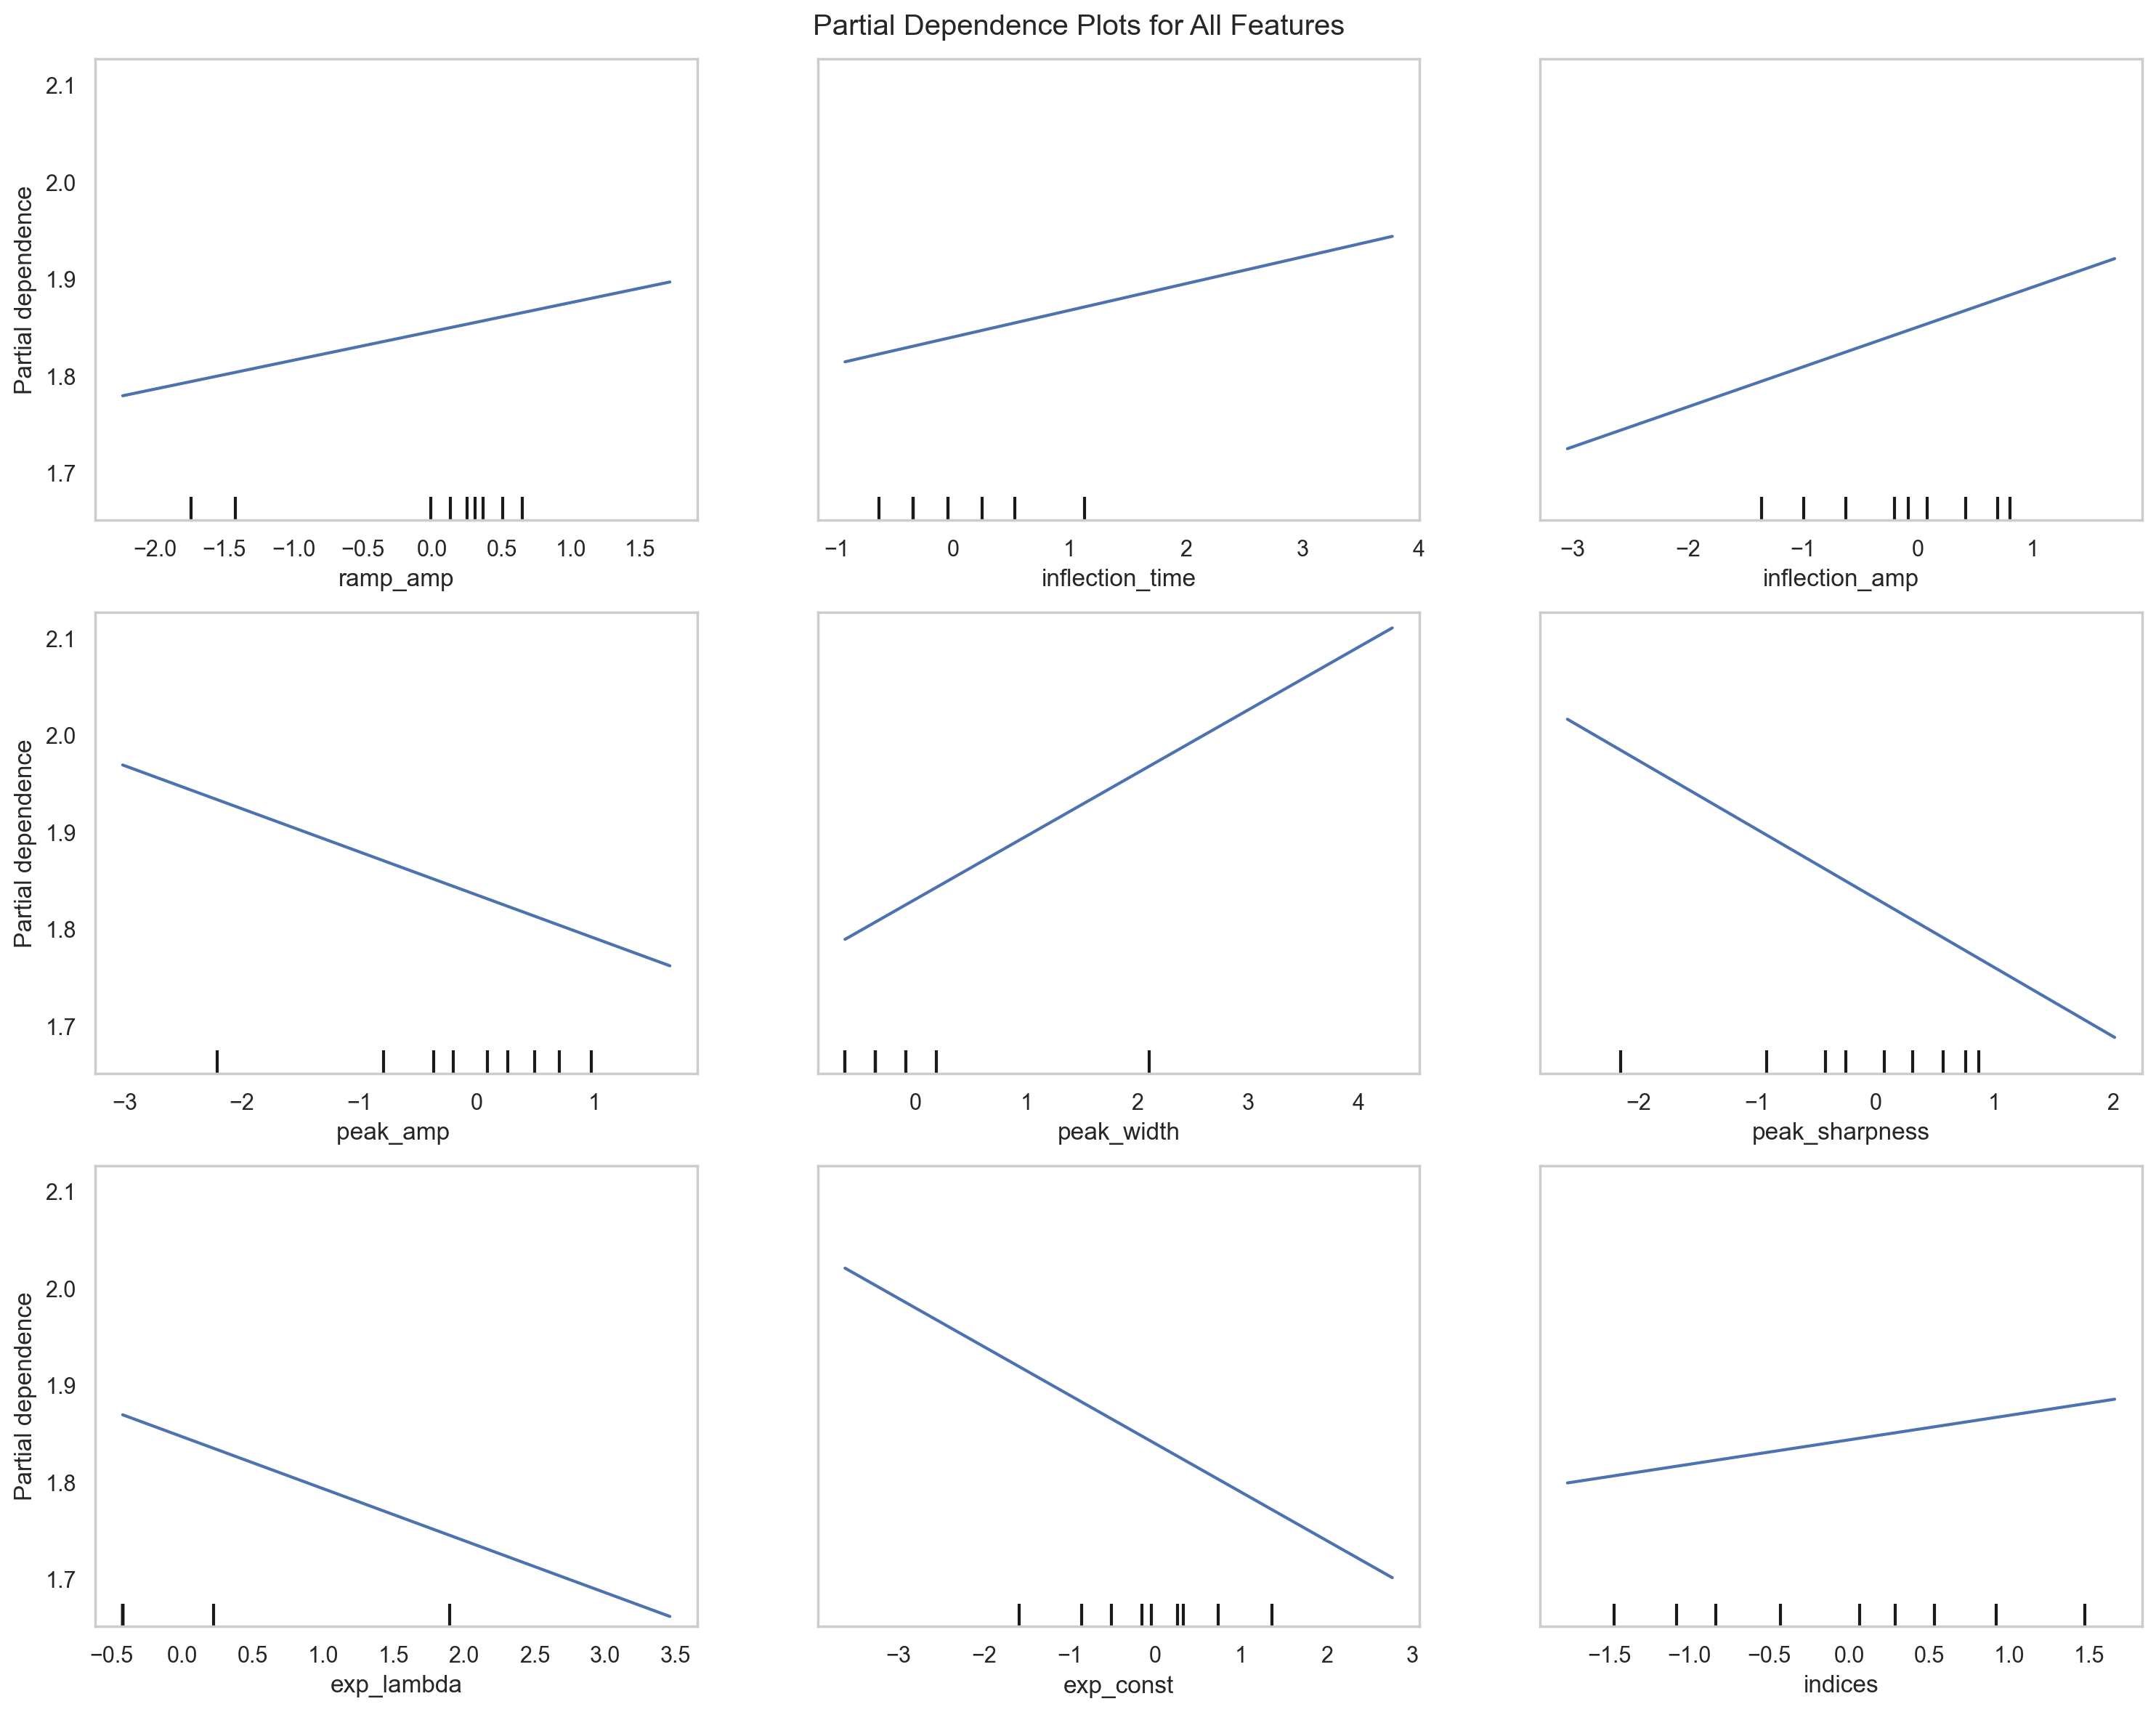

In [47]:
#FEATURE PARTIAL DEPENDANCE

from sklearn.inspection import PartialDependenceDisplay

# Create PDP for all features
fig, ax = plt.subplots(figsize=(15, 12))
PartialDependenceDisplay.from_estimator(model, X_test, range(len(actual_feature_names)), feature_names=actual_feature_names, ax=ax)
plt.suptitle('Partial Dependence Plots for All Features')
plt.tight_layout()
plt.show()


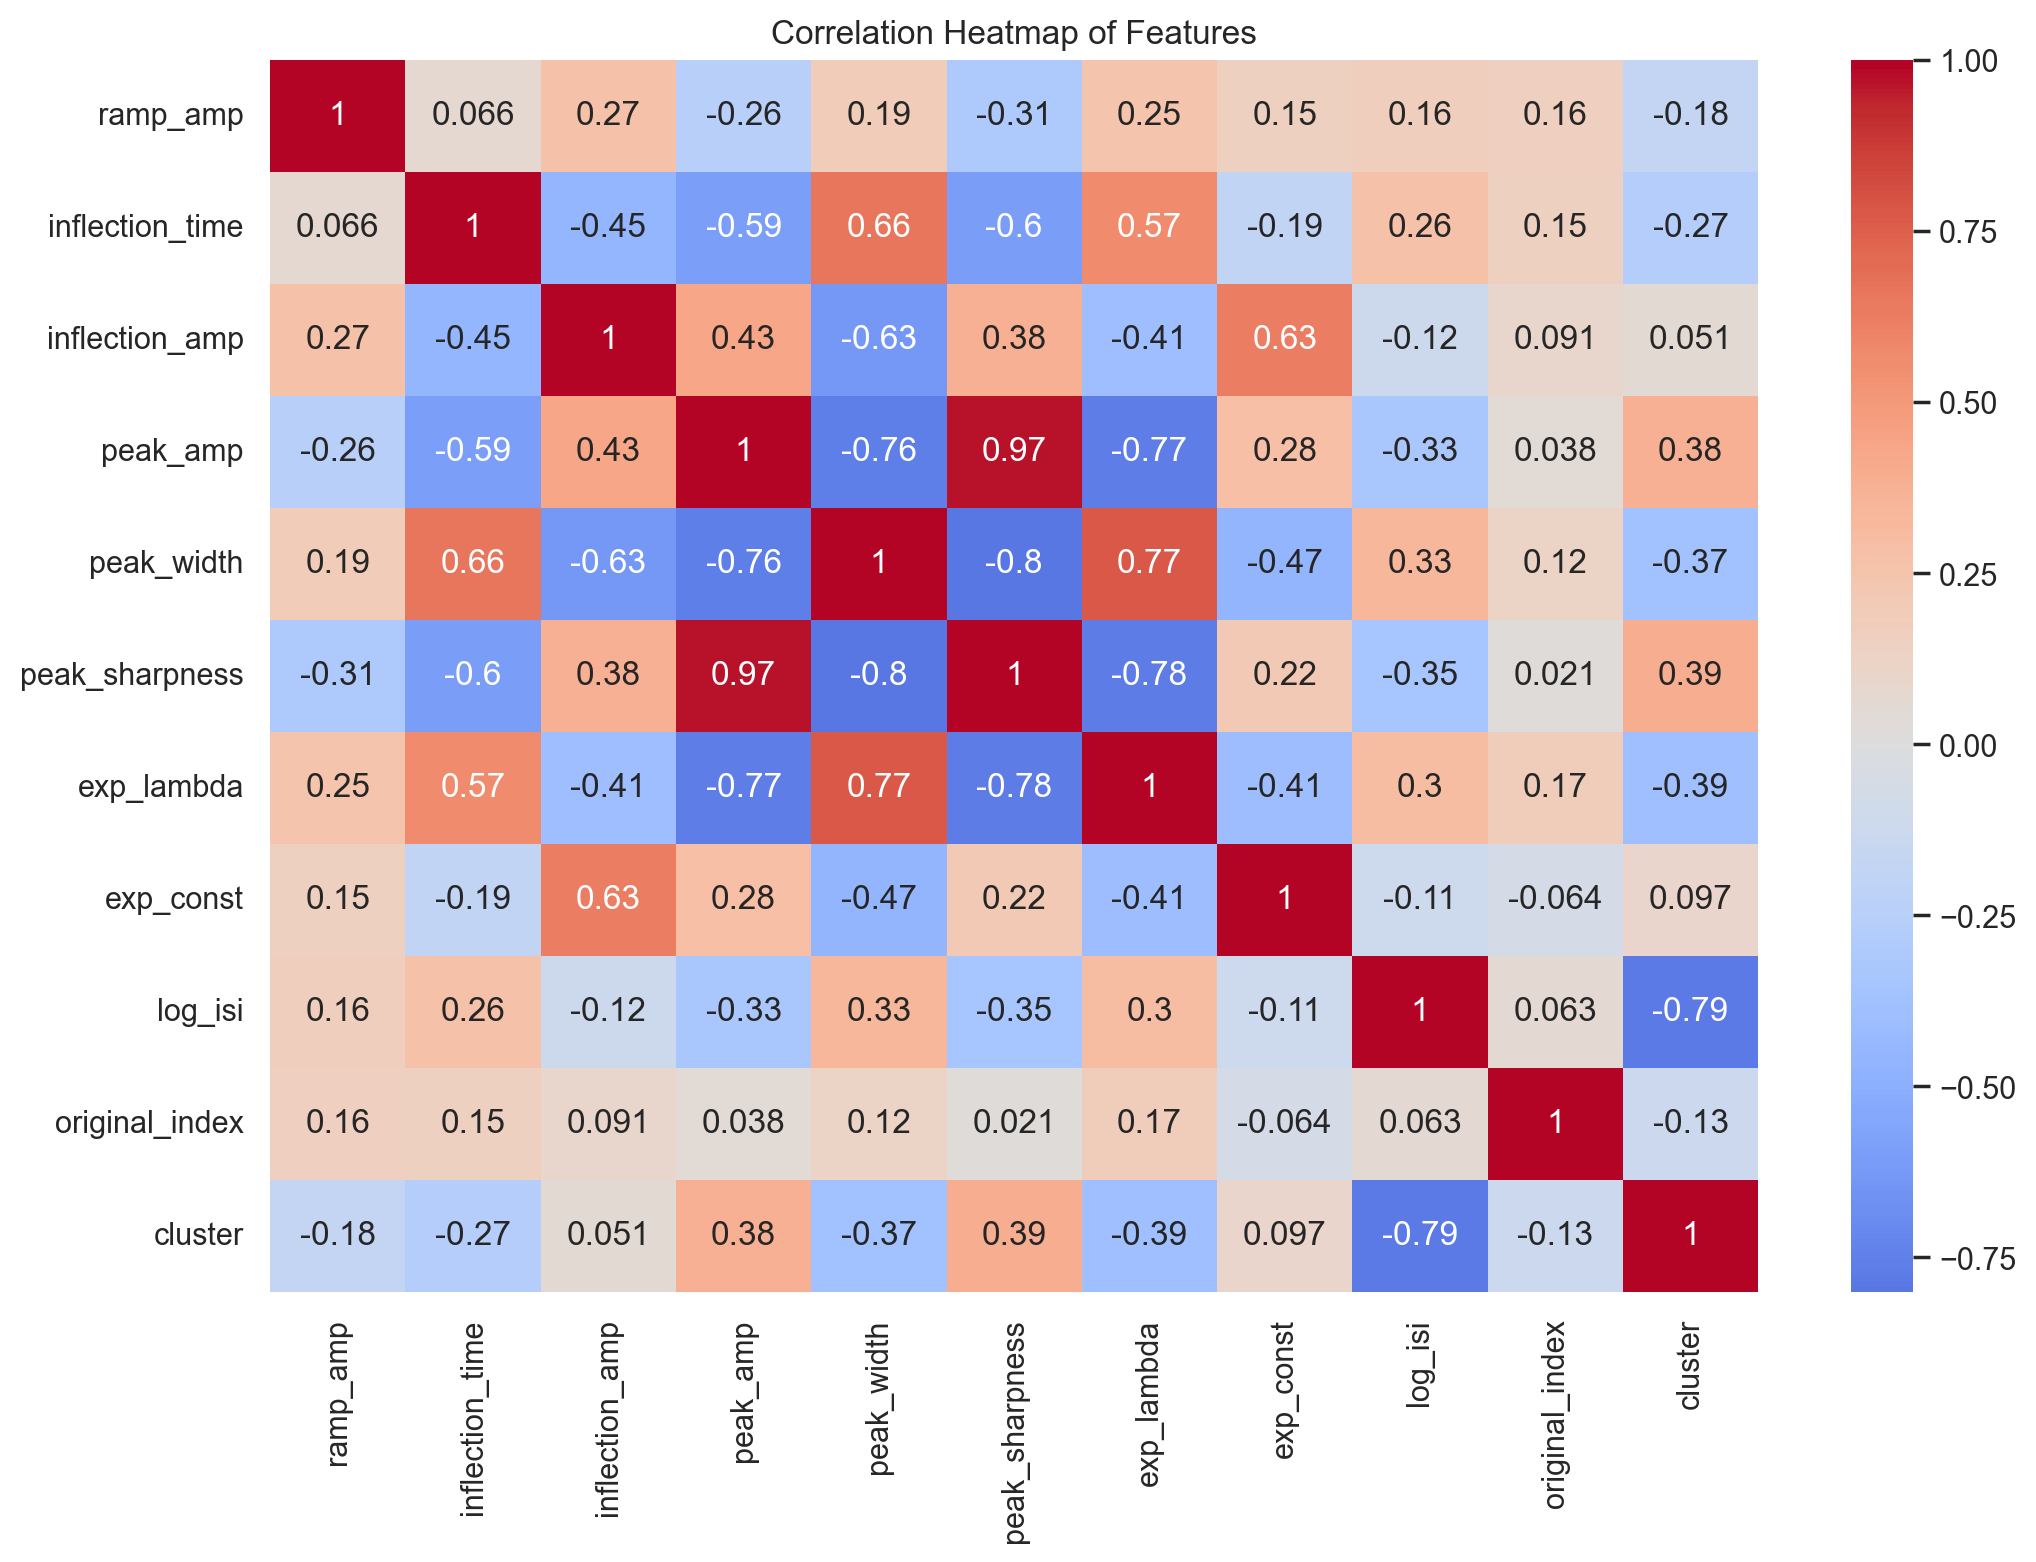

In [48]:
#see correlation matrix with orginal_index "feature"

correlation_matrix = df_features.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Features')
plt.show()

In [ ]:
c